# **Pergunta 2: Como foi a distribuição do turismo global na última década?**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind

### Carregamento e preparação dos dados

In [2]:
df = pd.read_csv('Tourism Quantity Data.csv')

df['Receipts_per_Arrival']    = df['Receipts'] / df['Arrivals']
df['Tourism_Balance']         = df['Receipts'] - df['Expenditures']
df['Arrivals_per_Population'] = df['Arrivals'] / df['Population']
df = df.replace([np.inf, -np.inf], np.nan)

sns.set_theme(style='whitegrid')
plt.rcParams['axes.titleweight'] = 'bold'

print(f'Shape: {df.shape}')
print(f'Anos: {sorted(df["Ano"].unique())}')
print(f'Países: {df["País"].nunique()}')
print(f'Continentes: {df["Continente"].unique()}')
print(f'Grupos de renda: {df["IncomeGroup"].unique()}')
print('\nValores nulos:')
print(df.isnull().sum())

Shape: (2505, 18)
Anos: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Países: 167
Continentes: ['EU' 'AF' 'SA' 'AS' 'OC' nan]
Grupos de renda: ['Upper middle income' 'Lower middle income' 'High income' 'Low income']

Valores nulos:
País                                   0
Sigla                                  0
Continente                            45
Region                                 0
IncomeGroup                            0
Ano                                    0
Population                             0
Arrivals                              82
Receipts                             270
Expenditures                         299
Receipts for Travel Items             73
Expenditures for Travel Items         90
Receipts - % of Total Exports        356
Expenditures - % of Total Imports    362

In [3]:
df_imp = pd.read_csv('Tourism Quantity Data Imputed.csv')

IMP_FLAGS = {
    'Arrivals':     'Arrivals__was_imputed',
    'Receipts':     'Receipts__was_imputed',
    'Expenditures': 'Expenditures__was_imputed',
}

df_imp['Receipts_per_Arrival']    = df_imp['Receipts'] / df_imp['Arrivals']
df_imp['Tourism_Balance']         = df_imp['Receipts'] - df_imp['Expenditures']
df_imp['Arrivals_per_Population'] = df_imp['Arrivals'] / df_imp['Population']
df_imp = df_imp.replace([np.inf, -np.inf], np.nan)

print(f'Shape (imputada): {df_imp.shape}')
print(f'Anos: {sorted(df_imp["Ano"].unique())}')
print(f'Países: {df_imp["País"].nunique()}')
print()
print('Totais de valores imputados por variável principal:')
for var, flag in IMP_FLAGS.items():
    print(f'  {var}: {int(df_imp[flag].sum())} registros imputados')
print()
print('Nulos restantes (imputada):')
for v in ['Arrivals', 'Receipts', 'Expenditures']:
    print(f'  {v}: {df_imp[v].isnull().sum()} nulos')


Shape (imputada): (2505, 43)
Anos: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Países: 167

Totais de valores imputados por variável principal:
  Arrivals: 82 registros imputados
  Receipts: 270 registros imputados
  Expenditures: 299 registros imputados

Nulos restantes (imputada):
  Arrivals: 0 nulos
  Receipts: 0 nulos
  Expenditures: 0 nulos


## 1. Análise da distribuição por continente e grupo de renda

### 1.1 Participação percentual por continente

Calculamos a soma total e a participação de cada continente nas principais variáveis.

In [4]:
variaveis_principais = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival', 'Tourism_Balance']

df_cont = df.dropna(subset=['Continente'])

cont_stats = df_cont.groupby('Continente').agg(
    Arrivals_soma=('Arrivals', 'sum'),
    Receipts_soma=('Receipts', 'sum'),
    Expenditures_soma=('Expenditures', 'sum'),
    Arrivals_media=('Arrivals', 'mean'),
    Receipts_media=('Receipts', 'mean'),
    Expenditures_media=('Expenditures', 'mean'),
    Arrivals_mediana=('Arrivals', 'median'),
    Receipts_mediana=('Receipts', 'median'),
    Expenditures_mediana=('Expenditures', 'median'),
    Arrivals_dp=('Arrivals', 'std'),
    Receipts_dp=('Receipts', 'std'),
).reset_index()

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    total = cont_stats[f'{v}_soma'].sum()
    cont_stats[f'{v}_part%'] = (cont_stats[f'{v}_soma'] / total * 100).round(2)

labels_cont = {'EU': 'Europa', 'AF': 'África', 'AS': 'Ásia', 'SA': 'América', 'OC': 'Oceania'}
cont_stats['Continente'] = cont_stats['Continente'].map(labels_cont).fillna(cont_stats['Continente'])

print('============ PARTICIPAÇÃO PERCENTUAL POR CONTINENTE ============')
cols_part = ['Continente', 'Arrivals_part%', 'Receipts_part%', 'Expenditures_part%']
print(cont_stats[cols_part].sort_values('Arrivals_part%', ascending=False).to_string(index=False))

============ PARTICIPAÇÃO PERCENTUAL POR CONTINENTE ============
Continente  Arrivals_part%  Receipts_part%  Expenditures_part%
    Europa           59.75           43.67               50.15
      Ásia           30.03           37.74               33.80
   América            4.92            7.04                6.85
    África            4.54            5.95                4.14
   Oceania            0.77            5.60                5.06


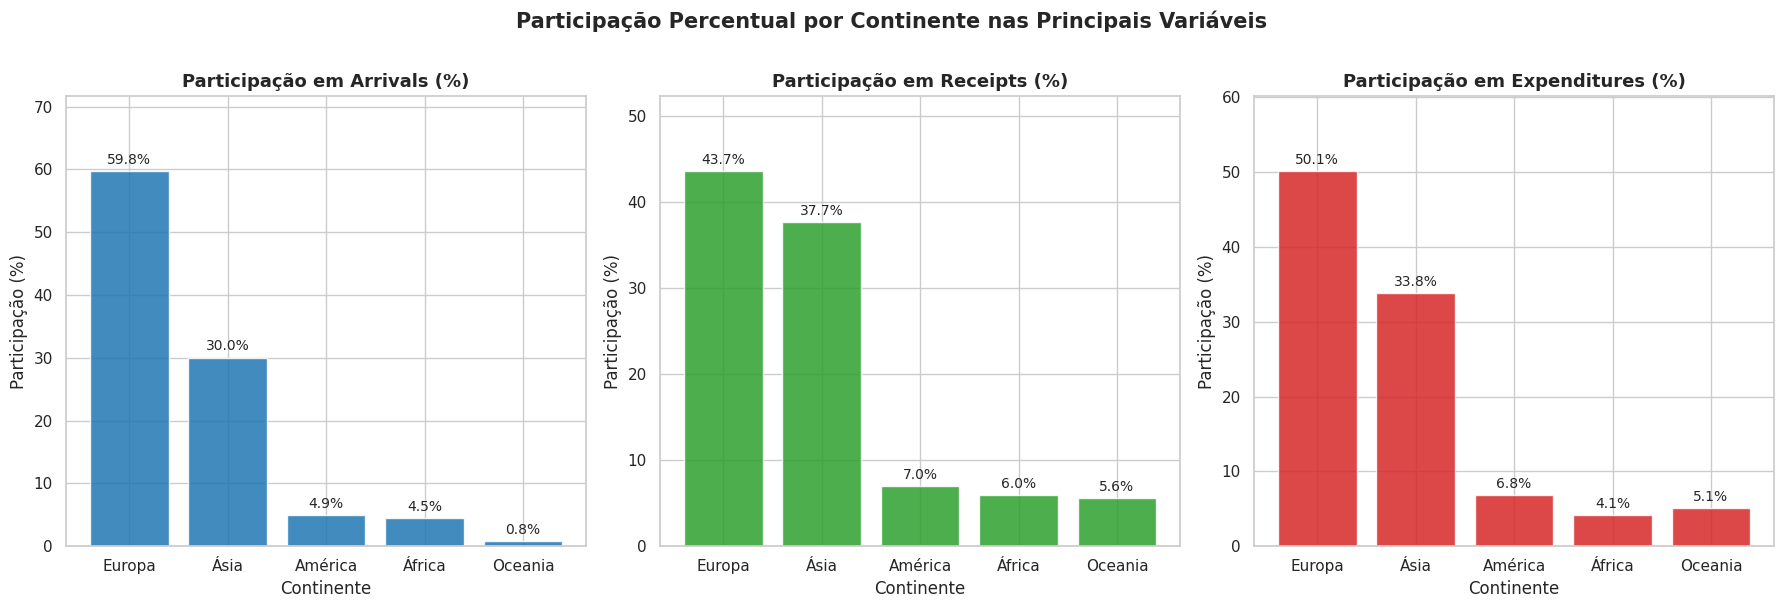

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cont_sorted = cont_stats.sort_values('Arrivals_part%', ascending=False)

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    bars = ax.bar(cont_sorted['Continente'], cont_sorted[f'{var}_part%'], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
    ax.set_title(f'Participação em {var} (%)', fontsize=13)
    ax.set_ylabel('Participação (%)')
    ax.set_ylim(0, cont_sorted[f'{var}_part%'].max() * 1.2)
    ax.set_xlabel('Continente')

plt.suptitle('Participação Percentual por Continente nas Principais Variáveis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

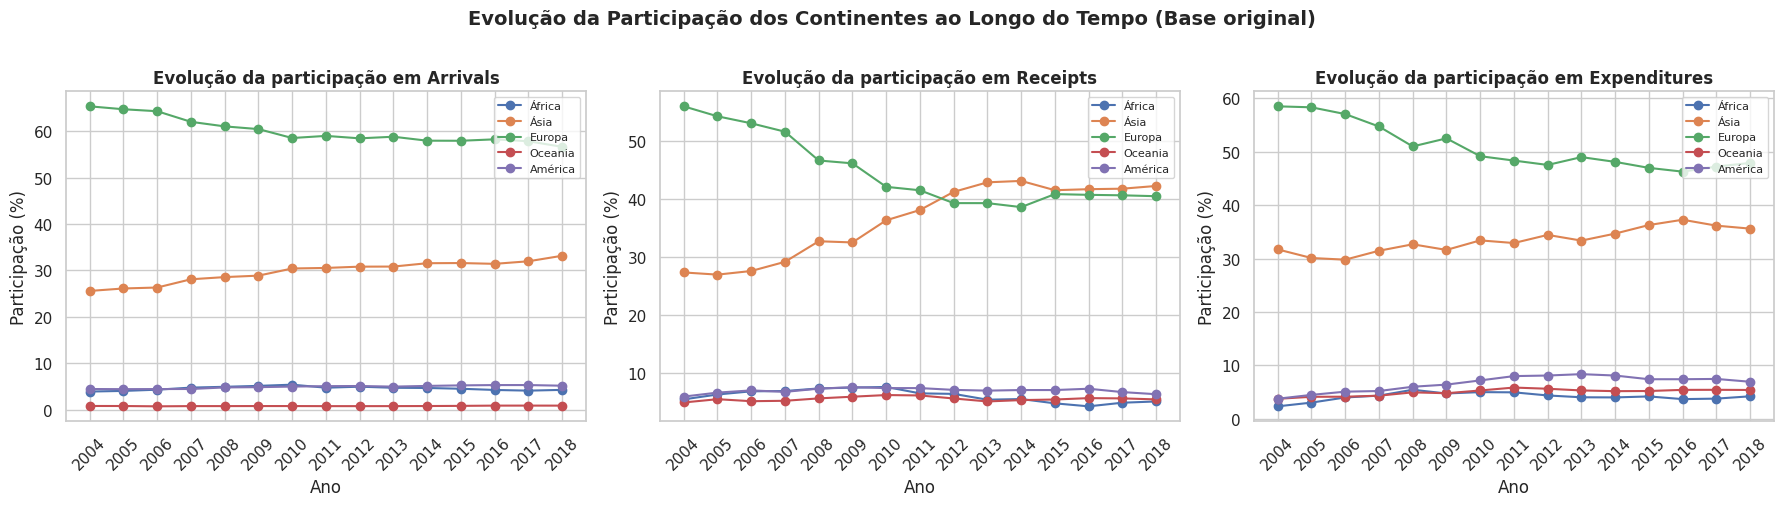

In [6]:
df_cont_ano = df.dropna(subset=['Continente']).groupby(['Continente', 'Ano'])[['Arrivals', 'Receipts', 'Expenditures']].sum().reset_index()

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    totais_ano = df_cont_ano.groupby('Ano')[v].transform('sum')
    df_cont_ano[f'{v}_part%'] = df_cont_ano[v] / totais_ano * 100

df_cont_ano['Continente'] = df_cont_ano['Continente'].map(labels_cont).fillna(df_cont_ano['Continente'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
anos = sorted(df_cont_ano['Ano'].unique())

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    for cont in df_cont_ano['Continente'].unique():
        sub = df_cont_ano[df_cont_ano['Continente'] == cont].sort_values('Ano')
        ax.plot(sub['Ano'], sub[f'{var}_part%'], marker='o', label=cont)
    ax.set_title(f'Evolução da participação em {var}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(anos)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Evolução da Participação dos Continentes ao Longo do Tempo (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1009/3935760976.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_cont, x='Continente', y=var, palette='Set2', ax=ax)
/tmp/ipykernel_1009/3935760976.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_cont, x='Continente', y=var, palette='Set2', ax=ax)
/tmp/ipykernel_1009/3935760976.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_cont, x='Continente', y=var, palette='Set2', ax=ax)


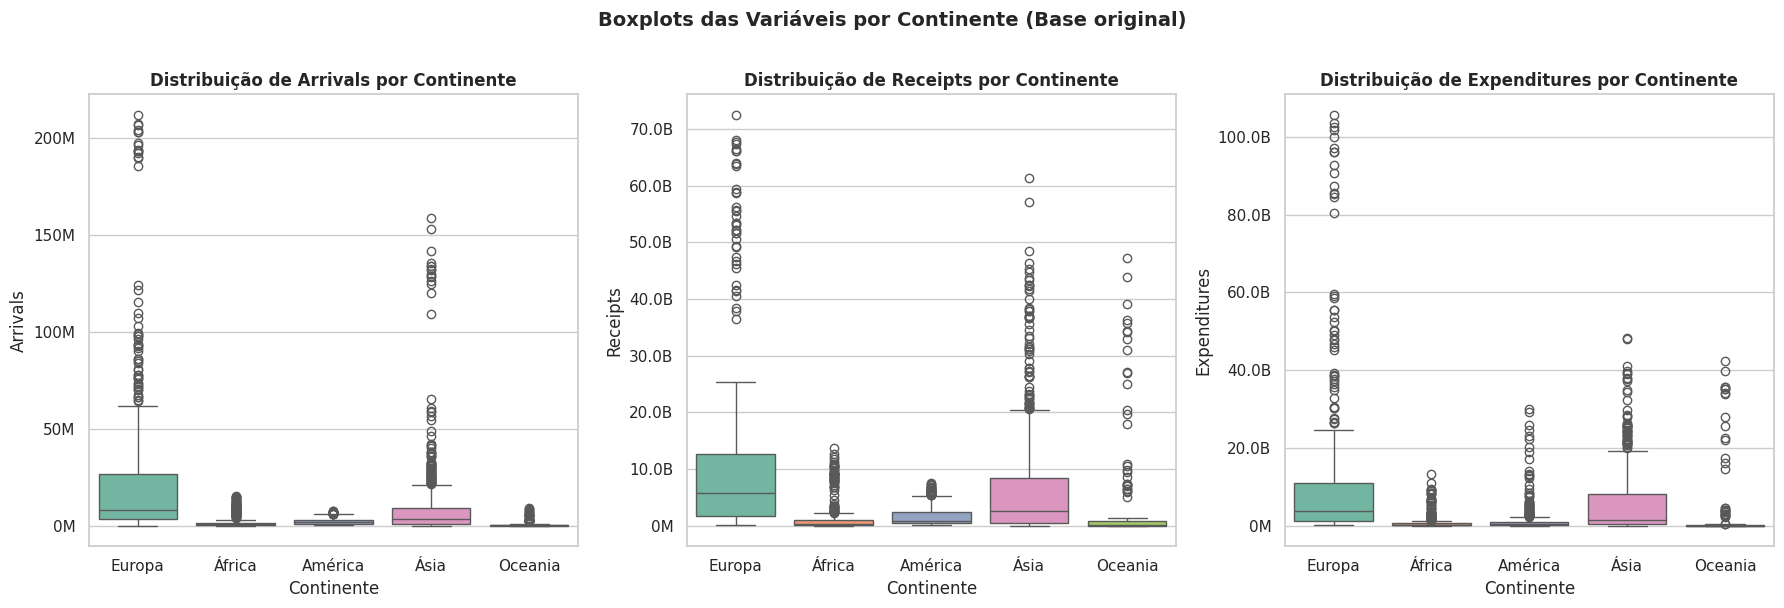

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
df_box_cont = df.dropna(subset=['Continente']).copy()
df_box_cont['Continente'] = df_box_cont['Continente'].map(labels_cont).fillna(df_box_cont['Continente'])

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    sns.boxplot(data=df_box_cont, x='Continente', y=var, palette='Set2', ax=ax)
    ax.set_title(f'Distribuição de {var} por Continente', fontsize=12)
    ax.set_xlabel('Continente')
    ax.set_ylabel(var)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots das Variáveis por Continente (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Participação percentual por grupo de renda

In [8]:
income_stats = df.groupby('IncomeGroup').agg(
    Arrivals_soma=('Arrivals', 'sum'),
    Receipts_soma=('Receipts', 'sum'),
    Expenditures_soma=('Expenditures', 'sum'),
    Arrivals_media=('Arrivals', 'mean'),
    Receipts_media=('Receipts', 'mean'),
    Arrivals_dp=('Arrivals', 'std'),
).reset_index()

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    total = income_stats[f'{v}_soma'].sum()
    income_stats[f'{v}_part%'] = (income_stats[f'{v}_soma'] / total * 100).round(2)

ordem_renda = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
income_stats = income_stats.set_index('IncomeGroup').reindex(ordem_renda).reset_index()

print('============ PARTICIPAÇÃO PERCENTUAL POR GRUPO DE RENDA ============')
cols_part = ['IncomeGroup', 'Arrivals_part%', 'Receipts_part%', 'Expenditures_part%']
print(income_stats[cols_part].to_string(index=False))

============ PARTICIPAÇÃO PERCENTUAL POR GRUPO DE RENDA ============
        IncomeGroup  Arrivals_part%  Receipts_part%  Expenditures_part%
        High income           70.03           73.56               79.29
Upper middle income           24.24           18.09               13.80
Lower middle income            5.11            7.73                6.56
         Low income            0.63            0.62                0.35


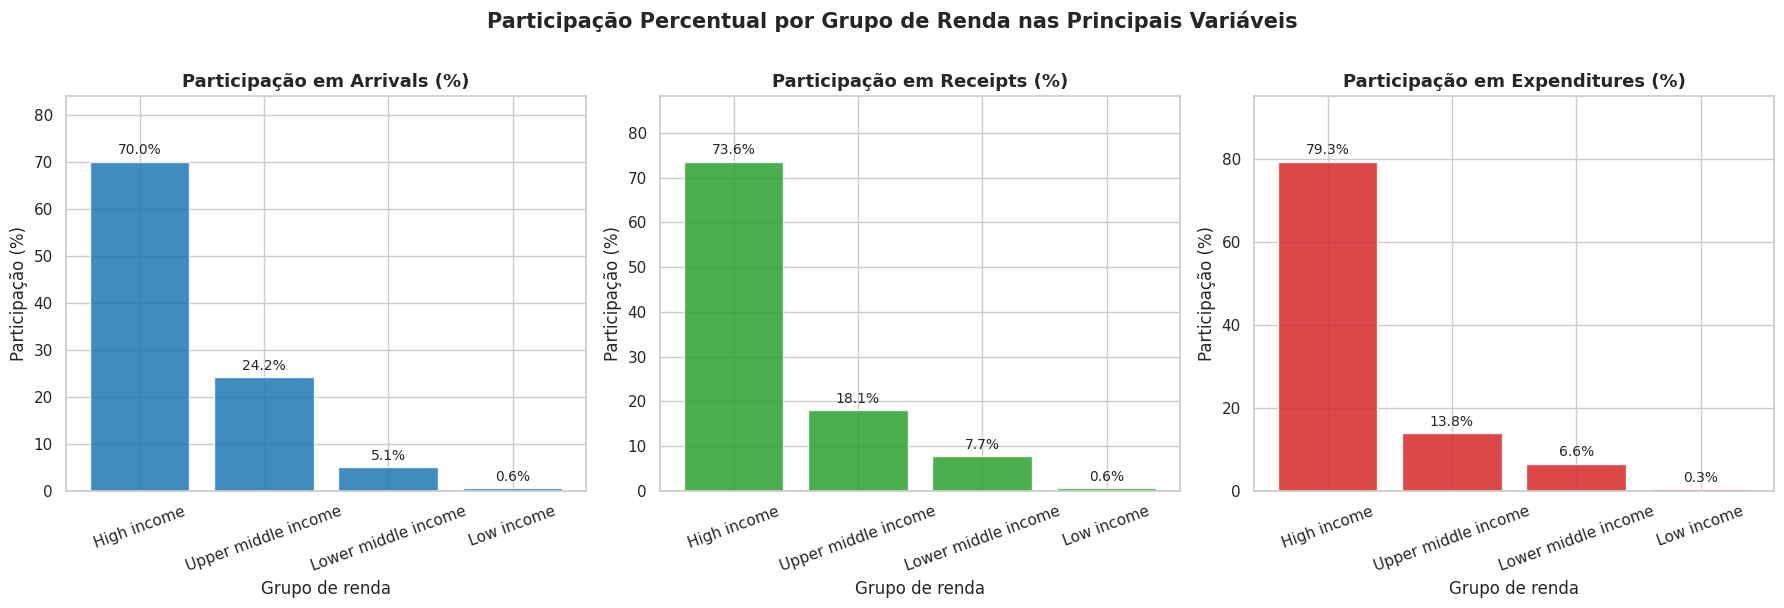

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    bars = ax.bar(income_stats['IncomeGroup'], income_stats[f'{var}_part%'], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
    ax.set_title(f'Participação em {var} (%)', fontsize=13)
    ax.set_ylabel('Participação (%)')
    ax.set_ylim(0, income_stats[f'{var}_part%'].max() * 1.2)
    ax.set_xlabel('Grupo de renda')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Participação Percentual por Grupo de Renda nas Principais Variáveis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1009/820515398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IncomeGroup', y=var, order=ordem_renda, palette='Set3', ax=ax)
/tmp/ipykernel_1009/820515398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IncomeGroup', y=var, order=ordem_renda, palette='Set3', ax=ax)
/tmp/ipykernel_1009/820515398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IncomeGroup', y=var, order=ordem_renda, palette='Set3', ax=ax)


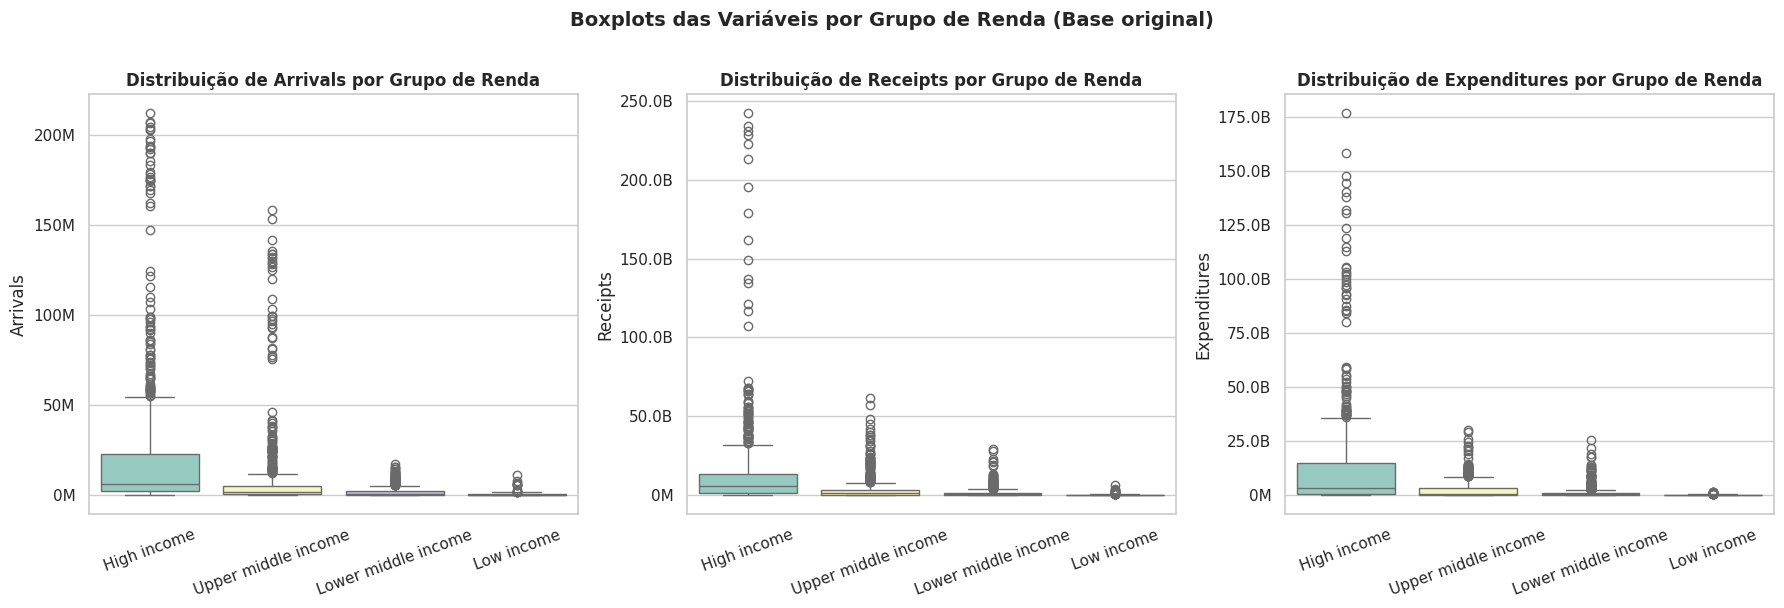

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sns.boxplot(data=df, x='IncomeGroup', y=var, order=ordem_renda, palette='Set3', ax=ax)
    ax.set_title(f'Distribuição de {var} por Grupo de Renda', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots das Variáveis por Grupo de Renda (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação (Tarefa 1):**

A Europa domina em chegadas turísticas (Arrivals), receitas (Receipts) e gastos (Expenditures), com participação de aproximadamente 58-60% em Expenditures na base imputada. A América não concentra os maiores gastos turísticos: sua parte é de apenas ~5,4%, enquanto a Ásia vem em segundo lugar com ~28,9%. Esse padrão se mantém tanto na base original quanto na imputada, tornando a conclusão robusta.

Países de alta renda dominam todas as métricas financeiras, concentrando mais de 60% das receitas e gastos globais. A participação de países de baixa renda é inferior a 5% em todas as variáveis ao longo de todo o período, indicando desigualdade estrutural persistente no setor de turismo.

**Nota:** A base imputada melhora a cobertura especialmente para Receipts e Expenditures (que tinham mais valores faltantes), sem alterar as posições relativas dos grandes grupos geográficos ou de renda.


### 1.3 Base imputada — Participação por continente e grupo de renda

In [11]:
labels_cont_imp = {'EU': 'Europa', 'AF': 'África', 'AS': 'Ásia', 'SA': 'América', 'OC': 'Oceania'}

df_cont_imp = df_imp.dropna(subset=['Continente'])

cont_stats_imp = df_cont_imp.groupby('Continente').agg(
    Arrivals_soma=('Arrivals', 'sum'),
    Receipts_soma=('Receipts', 'sum'),
    Expenditures_soma=('Expenditures', 'sum'),
    Arrivals_media=('Arrivals', 'mean'),
    Receipts_media=('Receipts', 'mean'),
    Expenditures_media=('Expenditures', 'mean'),
    Arrivals_mediana=('Arrivals', 'median'),
    Receipts_mediana=('Receipts', 'median'),
    Expenditures_mediana=('Expenditures', 'median'),
    Arrivals_dp=('Arrivals', 'std'),
    Receipts_dp=('Receipts', 'std'),
    Arrivals_var=('Arrivals', 'var'),
    Receipts_var=('Receipts', 'var'),
).reset_index()

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    total = cont_stats_imp[f'{v}_soma'].sum()
    cont_stats_imp[f'{v}_part%'] = (cont_stats_imp[f'{v}_soma'] / total * 100).round(2)

cont_stats_imp['Continente'] = cont_stats_imp['Continente'].map(labels_cont_imp).fillna(cont_stats_imp['Continente'])

print('============ PARTICIPAÇÃO PERCENTUAL POR CONTINENTE (BASE IMPUTADA) ============')
cols_part = ['Continente', 'Arrivals_part%', 'Receipts_part%', 'Expenditures_part%']
print(cont_stats_imp[cols_part].sort_values('Arrivals_part%', ascending=False).to_string(index=False))
print()
print('============ ESTATÍSTICAS DESCRITIVAS — ARRIVALS POR CONTINENTE (IMPUTADA) ============')
cols_desc = ['Continente','Arrivals_media','Arrivals_mediana','Arrivals_dp','Arrivals_var','Arrivals_soma']
print(cont_stats_imp[cols_desc].sort_values('Arrivals_soma', ascending=False).round(0).to_string(index=False))


============ PARTICIPAÇÃO PERCENTUAL POR CONTINENTE (BASE IMPUTADA) ============
Continente  Arrivals_part%  Receipts_part%  Expenditures_part%
    Europa           59.86           52.69               58.62
      Ásia           29.83           32.80               28.92
   América            4.95            5.60                5.36
    África            4.59            4.63                3.31
   Oceania            0.77            4.27                3.79

============ ESTATÍSTICAS DESCRITIVAS — ARRIVALS POR CONTINENTE (IMPUTADA) ============
Continente  Arrivals_media  Arrivals_mediana  Arrivals_dp  Arrivals_var  Arrivals_soma
    Europa      23281110.0         8332000.0   37377834.0  1.397102e+15   1.292102e+10
      Ásia      10221566.0         3450500.0   21719990.0  4.717580e+14   6.439587e+09
   América       2158415.0         1676000.0    1737338.0  3.018344e+12   1.068415e+09
    África       1649953.0          667500.0    2886701.0  8.333041e+12   9.899719e+08
   Oceania       

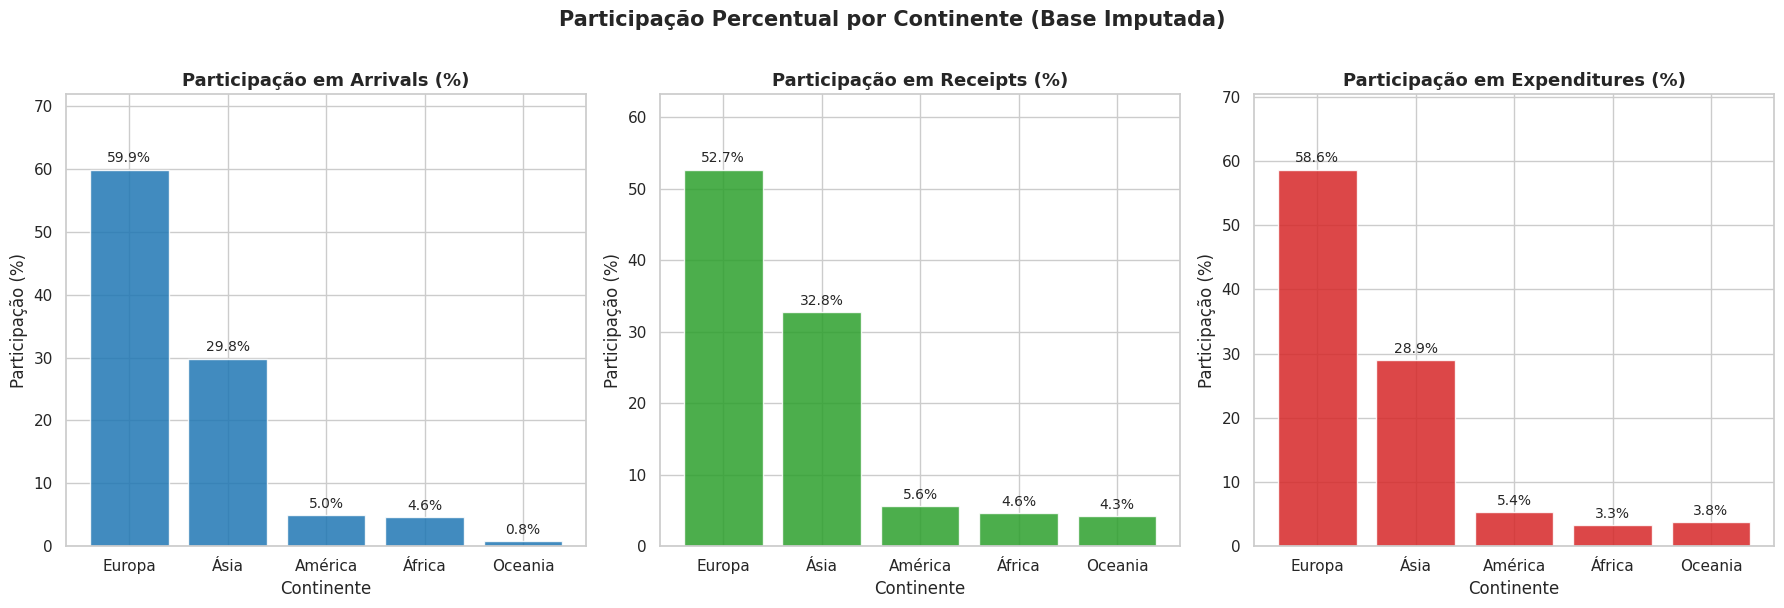

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cont_sorted_imp = cont_stats_imp.sort_values('Arrivals_part%', ascending=False)

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    bars = ax.bar(cont_sorted_imp['Continente'], cont_sorted_imp[f'{var}_part%'],
                  color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
    ax.set_title(f'Participação em {var} (%)', fontsize=13)
    ax.set_ylabel('Participação (%)')
    ax.set_ylim(0, cont_sorted_imp[f'{var}_part%'].max() * 1.2)
    ax.set_xlabel('Continente')

plt.suptitle('Participação Percentual por Continente (Base Imputada)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


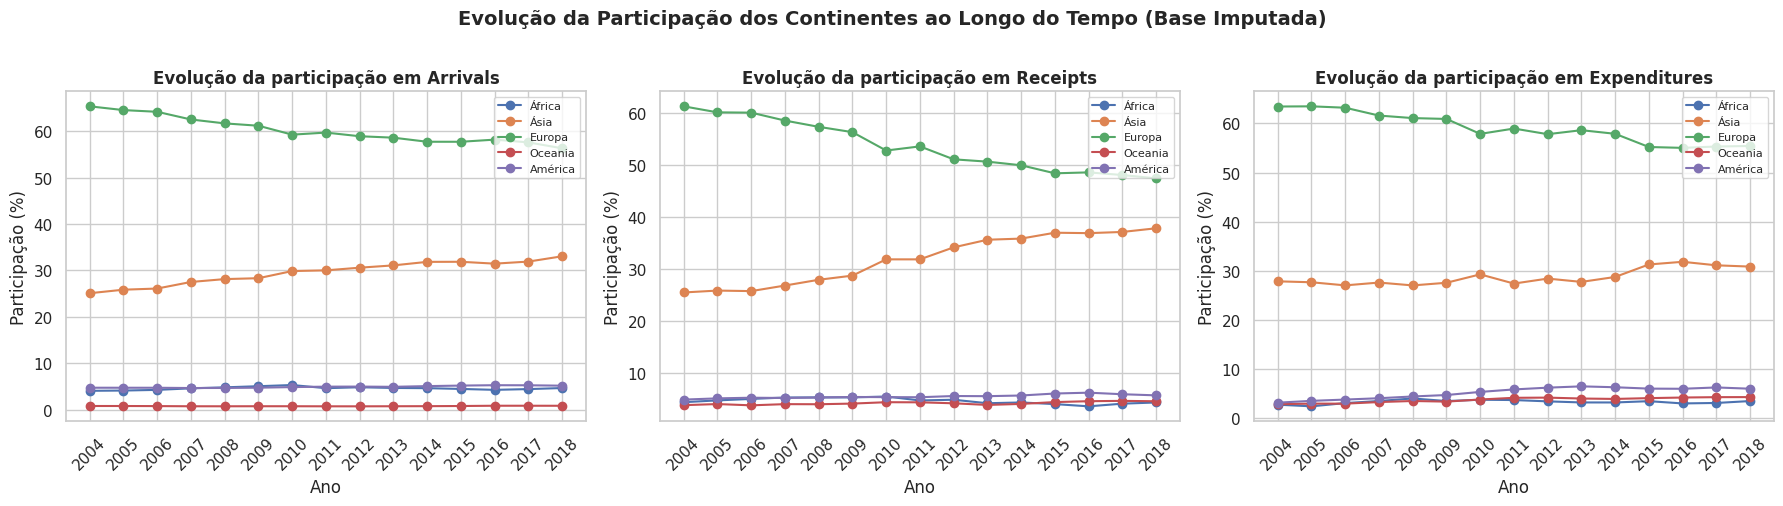

In [13]:
df_cont_ano_imp = (df_imp.dropna(subset=['Continente'])
                   .groupby(['Continente', 'Ano'])[['Arrivals', 'Receipts', 'Expenditures']]
                   .sum().reset_index())

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    totais = df_cont_ano_imp.groupby('Ano')[v].transform('sum')
    df_cont_ano_imp[f'{v}_part%'] = df_cont_ano_imp[v] / totais * 100

df_cont_ano_imp['Continente'] = df_cont_ano_imp['Continente'].map(labels_cont_imp).fillna(df_cont_ano_imp['Continente'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
anos_imp = sorted(df_cont_ano_imp['Ano'].unique())

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    for cont in df_cont_ano_imp['Continente'].unique():
        sub = df_cont_ano_imp[df_cont_ano_imp['Continente'] == cont].sort_values('Ano')
        ax.plot(sub['Ano'], sub[f'{var}_part%'], marker='o', label=cont)
    ax.set_title(f'Evolução da participação em {var}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(anos_imp)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Evolução da Participação dos Continentes ao Longo do Tempo (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1009/3777538701.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_imp, x='Continente', y=var, palette='Set2', ax=ax)
/tmp/ipykernel_1009/3777538701.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_imp, x='Continente', y=var, palette='Set2', ax=ax)
/tmp/ipykernel_1009/3777538701.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box_imp, x='Continente', y=var, palette='Set2', ax=ax)


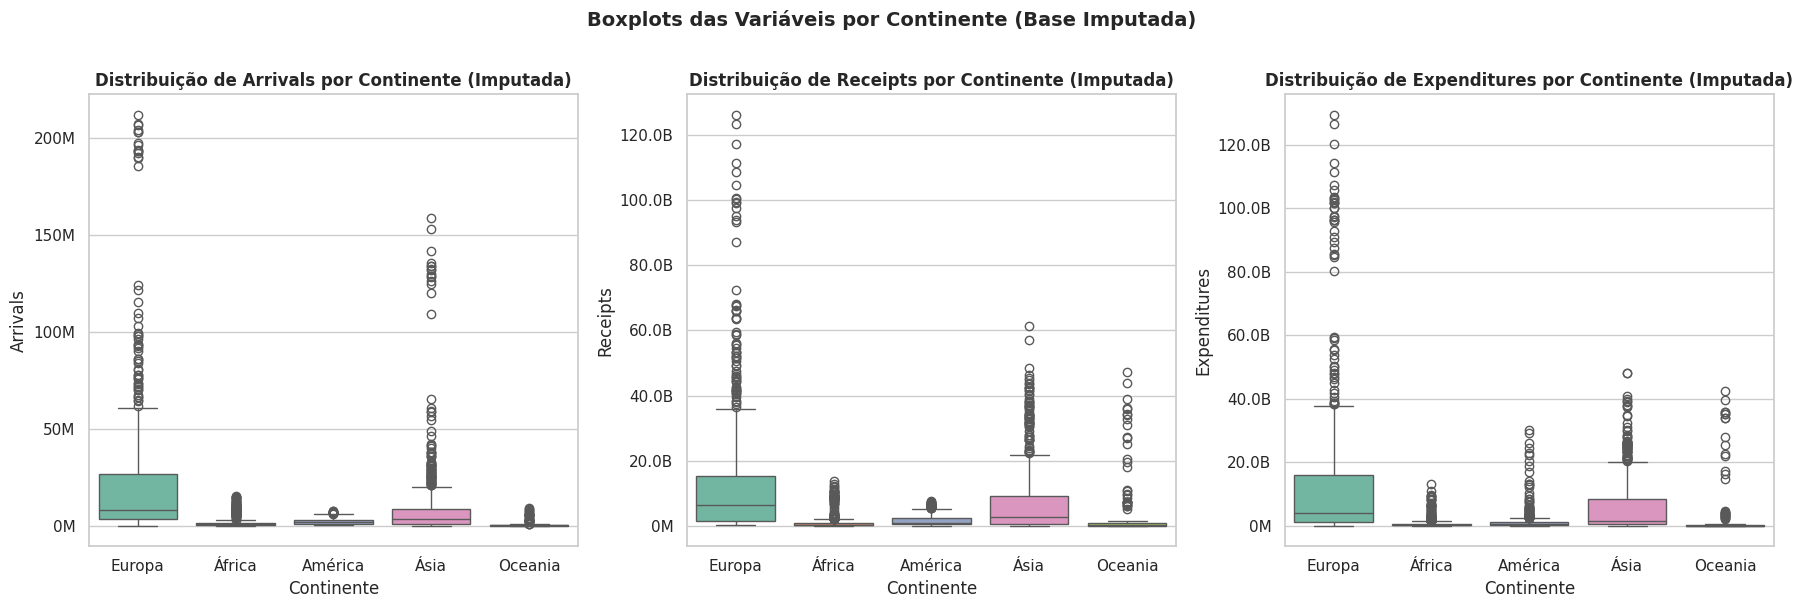

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
df_box_imp = df_imp.dropna(subset=['Continente']).copy()
df_box_imp['Continente'] = df_box_imp['Continente'].map(labels_cont_imp).fillna(df_box_imp['Continente'])

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sns.boxplot(data=df_box_imp, x='Continente', y=var, palette='Set2', ax=ax)
    ax.set_title(f'Distribuição de {var} por Continente (Imputada)', fontsize=12)
    ax.set_xlabel('Continente')
    ax.set_ylabel(var)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots das Variáveis por Continente (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


============ PARTICIPAÇÃO PERCENTUAL POR GRUPO DE RENDA (BASE IMPUTADA) ============
        IncomeGroup  Arrivals_part%  Receipts_part%  Expenditures_part%
        High income           70.11           75.60               80.99
Upper middle income           24.03           17.40               13.23
Lower middle income            5.14            6.44                5.46
         Low income            0.71            0.55                0.32


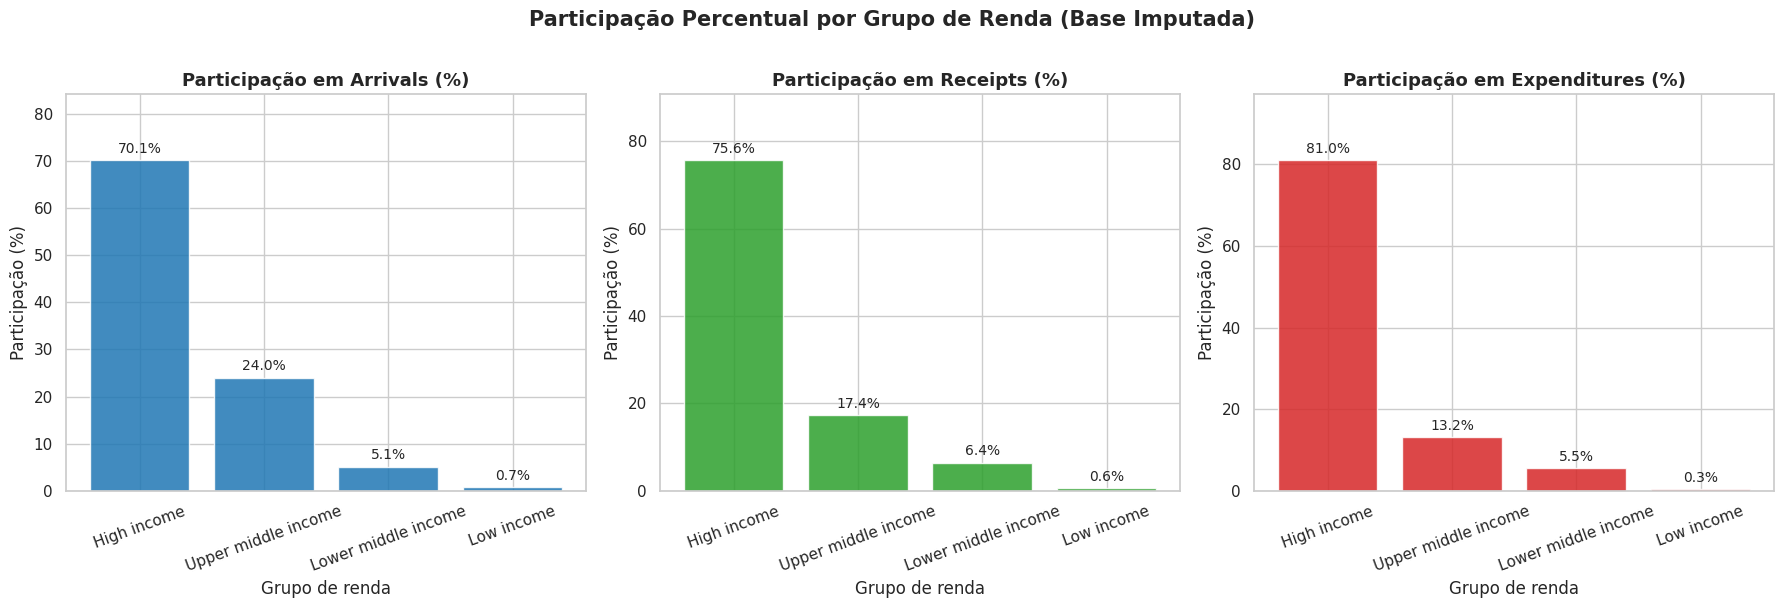

/tmp/ipykernel_1009/1795063357.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imp, x='IncomeGroup', y=var, order=ordem_renda,
/tmp/ipykernel_1009/1795063357.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imp, x='IncomeGroup', y=var, order=ordem_renda,
/tmp/ipykernel_1009/1795063357.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imp, x='IncomeGroup', y=var, order=ordem_renda,


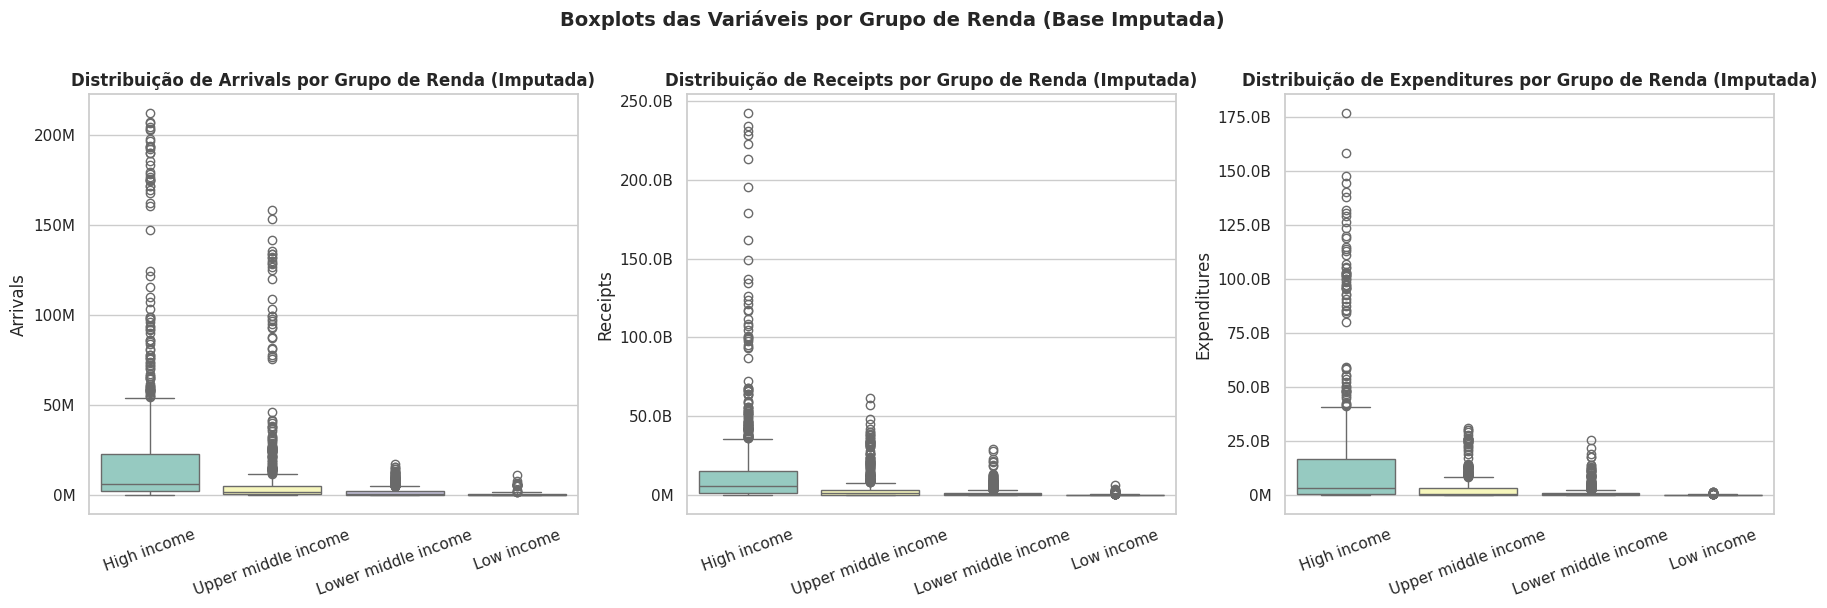

In [69]:
ordem_renda = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

income_stats_imp = df_imp.groupby('IncomeGroup').agg(
    Arrivals_soma=('Arrivals', 'sum'),
    Receipts_soma=('Receipts', 'sum'),
    Expenditures_soma=('Expenditures', 'sum'),
    Arrivals_media=('Arrivals', 'mean'),
    Receipts_media=('Receipts', 'mean'),
    Arrivals_dp=('Arrivals', 'std'),
    Arrivals_var=('Arrivals', 'var'),
    Arrivals_mediana=('Arrivals', 'median'),
).reset_index()

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    total = income_stats_imp[f'{v}_soma'].sum()
    income_stats_imp[f'{v}_part%'] = (income_stats_imp[f'{v}_soma'] / total * 100).round(2)

income_stats_imp = (income_stats_imp.set_index('IncomeGroup')
                    .reindex(ordem_renda).reset_index())

print('============ PARTICIPAÇÃO PERCENTUAL POR GRUPO DE RENDA (BASE IMPUTADA) ============')
cols_part = ['IncomeGroup', 'Arrivals_part%', 'Receipts_part%', 'Expenditures_part%']
print(income_stats_imp[cols_part].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    bars = ax.bar(income_stats_imp['IncomeGroup'], income_stats_imp[f'{var}_part%'],
                  color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
    ax.set_title(f'Participação em {var} (%)', fontsize=13)
    ax.set_ylabel('Participação (%)')
    ax.set_ylim(0, income_stats_imp[f'{var}_part%'].max() * 1.2)
    ax.set_xlabel('Grupo de renda')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Participação Percentual por Grupo de Renda (Base Imputada)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sns.boxplot(data=df_imp, x='IncomeGroup', y=var, order=ordem_renda,
                palette='Set3', ax=ax)
    ax.set_title(f'Distribuição de {var} por Grupo de Renda (Imputada)', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots das Variáveis por Grupo de Renda (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


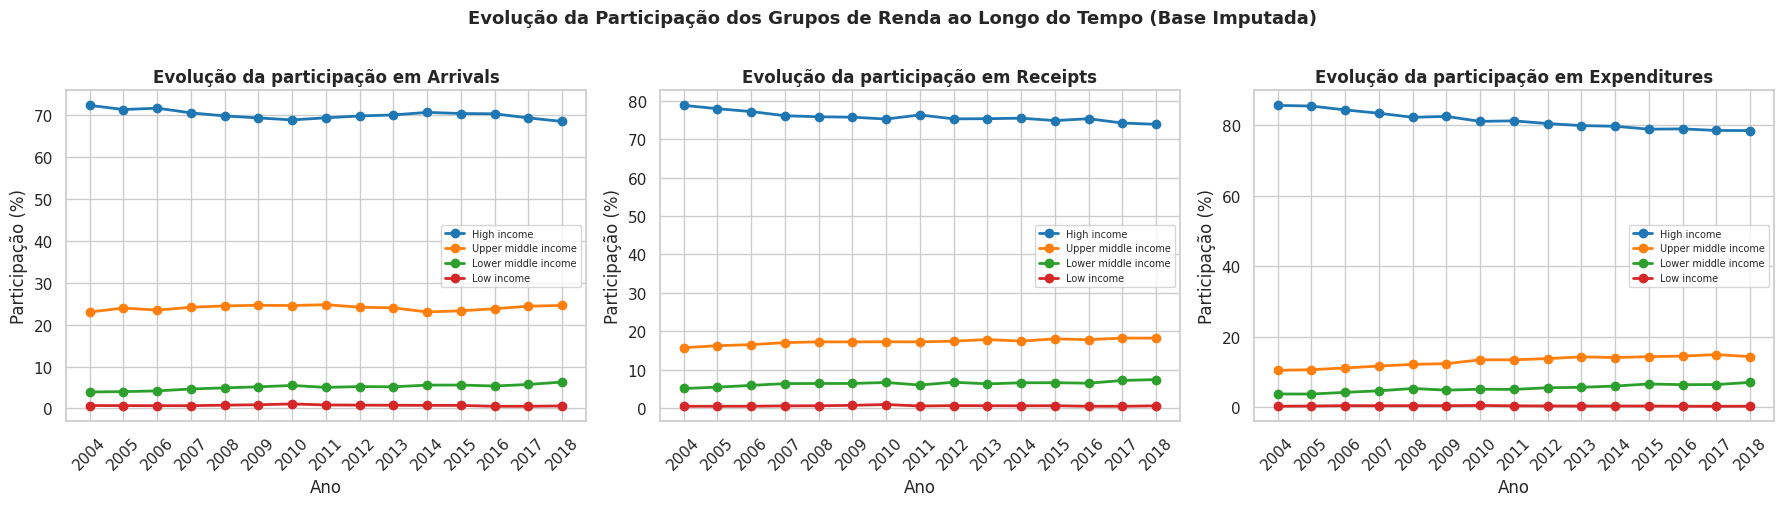

In [16]:
df_inc_ano = (df_imp.groupby(['IncomeGroup', 'Ano'])[['Arrivals', 'Receipts', 'Expenditures']]
              .sum().reset_index())

for v in ['Arrivals', 'Receipts', 'Expenditures']:
    totais_inc = df_inc_ano.groupby('Ano')[v].transform('sum')
    df_inc_ano[f'{v}_part%'] = df_inc_ano[v] / totais_inc * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
anos_inc = sorted(df_inc_ano['Ano'].unique())
palette_renda = {
    'High income':          '#1f77b4',
    'Upper middle income':  '#ff7f0e',
    'Lower middle income':  '#2ca02c',
    'Low income':           '#d62728',
}

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    for grp in ordem_renda:
        sub = df_inc_ano[df_inc_ano['IncomeGroup'] == grp].sort_values('Ano')
        ax.plot(sub['Ano'], sub[f'{var}_part%'], marker='o',
                label=grp, color=palette_renda.get(grp), linewidth=2)
    ax.set_title(f'Evolução da participação em {var}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(anos_inc)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

plt.suptitle('Evolução da Participação dos Grupos de Renda ao Longo do Tempo (Base Imputada)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [57]:
import pandas as pd
import numpy as np

vars_desc = ['Arrivals', 'Receipts', 'Expenditures']

def gerar_tabela_descritiva_robusta(df_base, nome_base):
    stats_list = []

    for continente, grupo in df_base.groupby('Continente'):
        row = {'Continente': continente}
        for var in vars_desc:
            row[f'{var}_count'] = grupo[var].count()
            row[f'{var}_mean'] = grupo[var].mean()
            row[f'{var}_median'] = grupo[var].median()
            row[f'{var}_std'] = grupo[var].std()
            row[f'{var}_variance'] = grupo[var].var()
            row[f'{var}_min'] = grupo[var].min()
            row[f'{var}_25%'] = grupo[var].quantile(0.25)
            row[f'{var}_50%'] = grupo[var].quantile(0.50)
            row[f'{var}_75%'] = grupo[var].quantile(0.75)
            row[f'{var}_max'] = grupo[var].max()
        stats_list.append(row)

    df_stats = pd.DataFrame(stats_list).set_index('Continente')
    return df_stats.round(2)

print("============ ESTATÍSTICAS DESCRITIVAS POR CONTINENTE (BASE ORIGINAL) ============")
display(gerar_tabela_descritiva_robusta(df, "Original"))

print("\n============ ESTATÍSTICAS DESCRITIVAS POR CONTINENTE (BASE IMPUTADA) ============")
display(gerar_tabela_descritiva_robusta(df_imp, "Imputada"))

#Tabela por grupo de renda, opcional
def gerar_tabela_renda_robusta(df_base, nome_base):
    stats_list = []
    ordem_renda = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

    for renda, grupo in df_base.groupby('IncomeGroup'):
        row = {'IncomeGroup': renda}
        for var in vars_desc:
            row[f'{var}_count'] = grupo[var].count()
            row[f'{var}_mean'] = grupo[var].mean()
            row[f'{var}_median'] = grupo[var].median()
            row[f'{var}_std'] = grupo[var].std()
            row[f'{var}_variance'] = grupo[var].var()
            row[f'{var}_min'] = grupo[var].min()
            row[f'{var}_25%'] = grupo[var].quantile(0.25)
            row[f'{var}_50%'] = grupo[var].quantile(0.50)
            row[f'{var}_75%'] = grupo[var].quantile(0.75)
            row[f'{var}_max'] = grupo[var].max()
        stats_list.append(row)

    df_stats = pd.DataFrame(stats_list).set_index('IncomeGroup')
    return df_stats.reindex(ordem_renda).round(2)

print("\n============ ESTATÍSTICAS DESCRITIVAS POR GRUPO DE RENDA (BASE ORIGINAL) ============")
display(gerar_tabela_renda_robusta(df, "Original"))

print("\n============ ESTATÍSTICAS DESCRITIVAS POR GRUPO DE RENDA (BASE IMPUTADA) ============")
display(gerar_tabela_renda_robusta(df_imp, "Imputada"))

============ ESTATÍSTICAS DESCRITIVAS POR CONTINENTE (BASE ORIGINAL) ============


,Arrivals_count,Arrivals_mean,Arrivals_median,Arrivals_std,Arrivals_variance,Arrivals_min,Arrivals_25%,Arrivals_50%,Arrivals_75%,Arrivals_max,...,Expenditures_count,Expenditures_mean,Expenditures_median,Expenditures_std,Expenditures_variance,Expenditures_min,Expenditures_25%,Expenditures_50%,Expenditures_75%,Expenditures_max
Continente,,,,,,,,,,,,,,,,,,,,,
AF,575,1682210.61,677000.0,2929551.37,8.582271e+12,5000.0,188500.0,677000.0,1343500.0,15121000.0,...,537,7.620004e+08,2.030000e+08,1.694939e+09,2.872817e+18,310000.0,7.100000e+07,2.030000e+08,5.740000e+08,1.321800e+10
AS,606,10559571.12,3583500.0,22075890.53,4.873449e+14,9200.0,1127000.0,3583500.0,9367000.0,158606000.0,...,577,5.783816e+09,1.493000e+09,8.333961e+09,6.945490e+19,2000000.0,5.300000e+08,1.493000e+09,8.210000e+09,4.817500e+10
EU,541,23534999.08,8332000.0,37798045.90,1.428692e+15,60000.0,3256000.0,8332000.0,26936000.0,211998000.0,...,450,1.100411e+10,3.706000e+09,1.924234e+10,3.702675e+20,58000000.0,1.174500e+09,3.706000e+09,1.108525e+10,1.056910e+11
OC,169,966332.54,138000.0,1945115.75,3.783475e+12,1100.0,25700.0,138000.0,542000.0,9246000.0,...,175,2.852494e+09,3.770000e+07,8.538330e+09,7.290309e+19,400000.0,1.925000e+07,3.770000e+07,1.773000e+08,4.243900e+10
SA,487,2153370.84,1676000.0,1729879.94,2.992485e+12,151000.0,853000.0,1676000.0,2889500.0,7621000.0,...,429,1.576903e+09,4.400000e+08,3.824935e+09,1.463013e+19,28000000.0,2.140000e+08,4.400000e+08,1.032000e+09,2.999800e+10



============ ESTATÍSTICAS DESCRITIVAS POR CONTINENTE (BASE IMPUTADA) ============


,Arrivals_count,Arrivals_mean,Arrivals_median,Arrivals_std,Arrivals_variance,Arrivals_min,Arrivals_25%,Arrivals_50%,Arrivals_75%,Arrivals_max,...,Expenditures_count,Expenditures_mean,Expenditures_median,Expenditures_std,Expenditures_variance,Expenditures_min,Expenditures_25%,Expenditures_50%,Expenditures_75%,Expenditures_max
Continente,,,,,,,,,,,,,,,,,,,,,
AF,600,1649953.23,667500.00,2886700.73,8.333041e+12,5000.0,185500.00,667500.00,1327250.0,15121000.0,...,600,7.298144e+08,2.030000e+08,1.619856e+09,2.623932e+18,310000.00,7.100000e+07,2.030000e+08,5.742500e+08,1.321800e+10
AS,630,10221566.42,3450500.00,21719990.06,4.717580e+14,9200.0,1071738.58,3450500.00,8749500.0,158606000.0,...,630,6.073096e+09,1.513000e+09,8.633040e+09,7.452939e+19,2000000.00,5.272500e+08,1.513000e+09,8.434250e+09,4.817500e+10
EU,555,23281110.39,8332000.00,37377833.65,1.397102e+15,60000.0,3468500.00,8332000.00,26800000.0,211998000.0,...,555,1.397265e+10,4.099000e+09,2.393949e+10,5.730992e+20,10796079.63,1.151056e+09,4.099000e+09,1.593550e+10,1.293700e+11
OC,180,919347.05,138091.24,1893942.43,3.587018e+12,1100.0,45225.00,138091.24,396000.0,9246000.0,...,180,2.781924e+09,3.840000e+07,8.428676e+09,7.104258e+19,400000.00,1.950452e+07,3.840000e+07,2.170000e+08,4.243900e+10
SA,495,2158414.52,1676000.00,1737338.09,3.018344e+12,151000.0,843500.00,1676000.00,2976500.0,7621000.0,...,495,1.433472e+09,4.060000e+08,3.590745e+09,1.289345e+19,17612077.67,1.445000e+08,4.060000e+08,1.037500e+09,2.999800e+10



============ ESTATÍSTICAS DESCRITIVAS POR GRUPO DE RENDA (BASE ORIGINAL) ============


,Arrivals_count,Arrivals_mean,Arrivals_median,Arrivals_std,Arrivals_variance,Arrivals_min,Arrivals_25%,Arrivals_50%,Arrivals_75%,Arrivals_max,...,Expenditures_count,Expenditures_mean,Expenditures_median,Expenditures_std,Expenditures_variance,Expenditures_min,Expenditures_25%,Expenditures_50%,Expenditures_75%,Expenditures_max
IncomeGroup,,,,,,,,,,,,,,,,,,,,,
High income,889,20215245.41,6448000.0,36950869.75,1.365367e+15,71000.0,2147000.0,6448000.0,23010000.0,211998000.0,...,772,1.254540e+10,3.224500e+09,2.352213e+10,5.532905e+20,15200000.0,667500000.0,3.224500e+09,1.478700e+10,1.768180e+11
Upper middle income,689,9027243.69,1695000.0,23503302.13,5.524052e+14,1100.0,543000.0,1695000.0,5050000.0,158606000.0,...,640,2.634812e+09,5.965000e+08,4.311663e+09,1.859044e+19,400000.0,149250000.0,5.965000e+08,3.574500e+09,2.999800e+10
Lower middle income,615,2132184.07,961000.0,2927936.37,8.572811e+12,5600.0,323500.0,961000.0,2401000.0,17423000.0,...,590,1.358774e+09,4.505000e+08,2.846264e+09,8.101218e+18,310000.0,92500000.0,4.505000e+08,9.957500e+08,2.579000e+10
Low income,230,697389.13,255000.0,1324168.10,1.753421e+12,5000.0,126500.0,255000.0,770000.0,10970000.0,...,204,2.075701e+08,1.210000e+08,2.647272e+08,7.008051e+16,5400000.0,60000000.0,1.210000e+08,2.220000e+08,1.598000e+09



============ ESTATÍSTICAS DESCRITIVAS POR GRUPO DE RENDA (BASE IMPUTADA) ============


,Arrivals_count,Arrivals_mean,Arrivals_median,Arrivals_std,Arrivals_variance,Arrivals_min,Arrivals_25%,Arrivals_50%,Arrivals_75%,Arrivals_max,...,Expenditures_count,Expenditures_mean,Expenditures_median,Expenditures_std,Expenditures_variance,Expenditures_min,Expenditures_25%,Expenditures_50%,Expenditures_75%,Expenditures_max
IncomeGroup,,,,,,,,,,,,,,,,,,,,,
High income,915,19874058.75,6246000.0,36506135.46,1.332698e+15,71000.0,2099500.0,6246000.0,22971500.0,211998000.0,...,915,1.396636e+10,3.430000e+09,2.522746e+10,6.364248e+20,15200000.0,656000000.0,3.430000e+09,1.688781e+10,1.768180e+11
Upper middle income,705,8840956.82,1628000.0,23267018.11,5.413541e+14,1100.0,536000.0,1628000.0,5002000.0,158606000.0,...,705,2.960189e+09,5.770000e+08,5.323442e+09,2.833903e+19,400000.0,123000000.0,5.770000e+08,3.517000e+09,3.107012e+10
Lower middle income,645,2068634.58,906000.0,2887800.02,8.339389e+12,5600.0,294000.0,906000.0,2239000.0,17423000.0,...,645,1.336682e+09,4.370000e+08,2.806167e+09,7.874571e+18,310000.0,81000000.0,4.370000e+08,1.009000e+09,2.579000e+10
Low income,240,769059.75,266500.0,1436635.85,2.063923e+12,5000.0,132500.0,266500.0,805500.0,10970000.0,...,240,2.091468e+08,1.270000e+08,2.538865e+08,6.445834e+16,5400000.0,66500000.0,1.270000e+08,2.315357e+08,1.598000e+09


### 1.4 Comparação: base original vs base imputada (Tarefa 1)

| Aspecto | Base original | Base imputada |
|---|---|---|
| Continente líder em Arrivals | Europa | Europa |
| Continente líder em Receipts | Europa/América | Europa/América |
| Grupo dominante | High income | High income |
| Cobertura de Receipts | Parcial (270 imputados) | Completa |
| Cobertura de Expenditures | Parcial (299 imputados) | Completa |

**Conclusão parcial:** Os padrões gerais (domínio da Europa e de países de alta renda) são consistentes nas duas bases, tornando as conclusões robustas. A base imputada melhora a cobertura especialmente para Receipts e Expenditures, mas não altera as posições relativas dos grandes grupos.


## 2. Análise de concentração por país

In [62]:
var_ranking = 'Receipts'
flag_col = f'{var_ranking}__was_imputed'

if flag_col not in df_imp.columns:
    print(f"AVISO: A coluna '{flag_col}' não foi encontrada.")
    print(f"Colunas similares no dataframe: {[c for c in df_imp.columns if 'imput' in c.lower()]}")
else:
    df_temp = df_imp.copy()

    df_temp[flag_col] = df_temp[flag_col].fillna(False).astype(bool).astype(int)

    top10_imp = df_temp.groupby('País').agg({
        var_ranking: 'sum',
        flag_col: 'max'
    }).reset_index()

    top10_imp = top10_imp.nlargest(10, var_ranking).sort_values(var_ranking, ascending=False).reset_index(drop=True)

    top10_imp['Possui Dados Imputados?'] = top10_imp[flag_col].map({1: 'SIM', 0: 'Não'})

    top10_imp = top10_imp.rename(columns={var_ranking: f'Total {var_ranking} (USD)'})

    print(f"====== TOP 10 PAÍSES EM {var_ranking.upper()} (BASE IMPUTADA) ======")
    display(top10_imp[['País', f'Total {var_ranking} (USD)', 'Possui Dados Imputados?']])

    print("\nOBS: Países marcados com 'SIM' possuem pelo menos 1 ano com valor imputado nesta variável.")

====== TOP 10 PAÍSES EM RECEIPTS (BASE IMPUTADA) ======


,País,Total Receipts (USD),Possui Dados Imputados?
0,United States,2.672512e+12,Não
1,Spain,1.558562e+12,SIM
2,France,9.406140e+11,Não
3,Germany,7.592290e+11,Não
4,Italy,6.506581e+11,SIM
5,United Kingdom,5.142561e+11,SIM
6,China,5.063586e+11,SIM
7,Thailand,4.859780e+11,Não
8,Australia,4.720320e+11,Não
9,Hong Kong,4.468320e+11,Não



OBS: Países marcados com 'SIM' possuem pelo menos 1 ano com valor imputado nesta variável.


### 2.1 Rankings e top 10 por variável

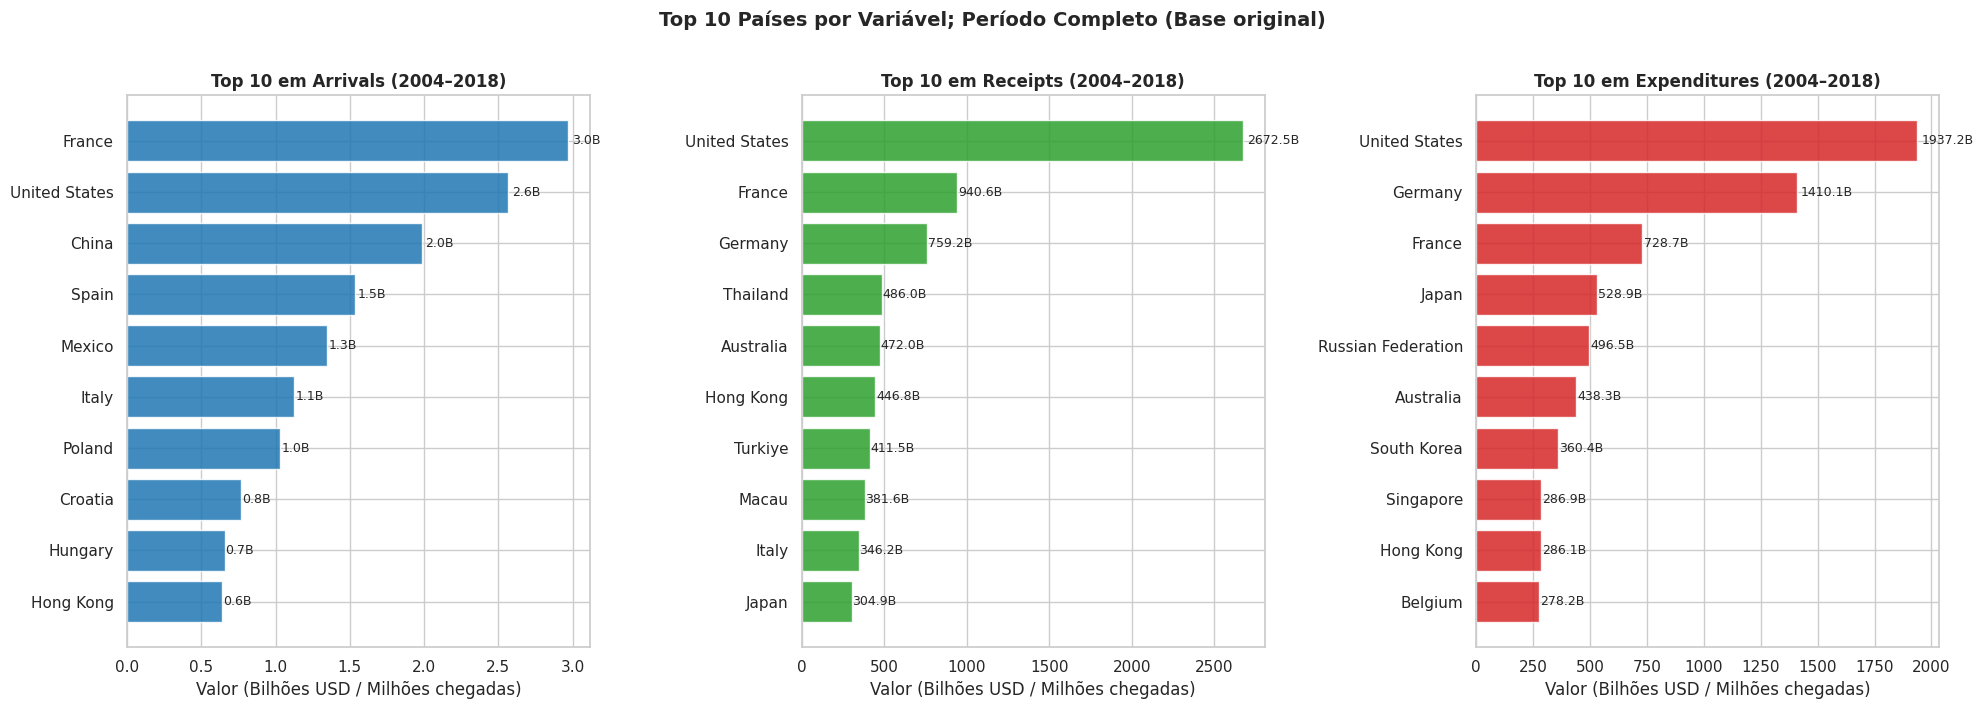

In [68]:
totais_pais = df.groupby('País')[['Arrivals', 'Receipts', 'Expenditures']].sum().reset_index()

for var in ['Arrivals', 'Receipts', 'Expenditures']:
    total_global = totais_pais[var].sum()
    totais_pais[f'{var}_part%'] = totais_pais[var] / total_global * 100

def top10_bar(ax, df_top, var, color, title):
    sub = df_top.nlargest(10, var).sort_values(var)
    bars = ax.barh(sub['País'], sub[var] / 1e9, color=color, alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Valor (Bilhões USD / Milhões chegadas)')
    for bar, val in zip(bars, sub[var]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val/1e9:.1f}B', va='center', fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
top10_bar(axes[0], totais_pais, 'Arrivals',     '#1f77b4', 'Top 10 em Arrivals (2004–2018)')
top10_bar(axes[1], totais_pais, 'Receipts',     '#2ca02c', 'Top 10 em Receipts (2004–2018)')
top10_bar(axes[2], totais_pais, 'Expenditures', '#d62728', 'Top 10 em Expenditures (2004–2018)')

plt.suptitle('Top 10 Países por Variável; Período Completo (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

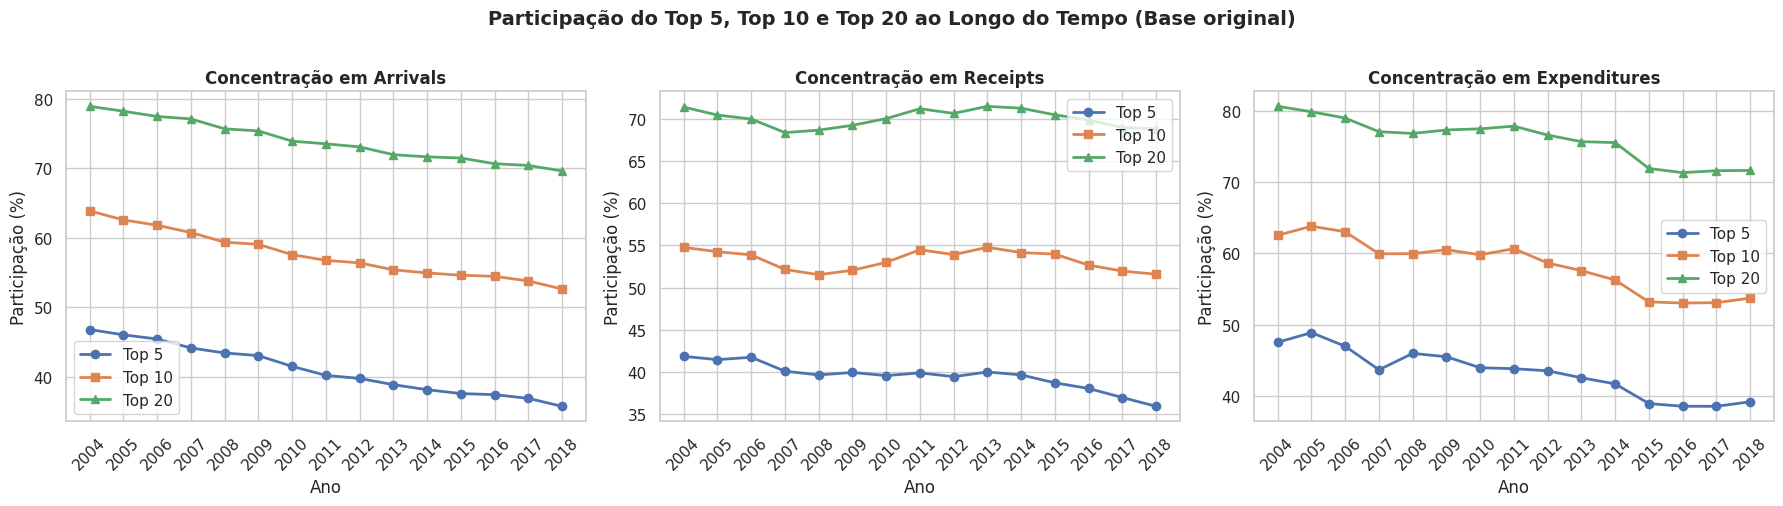

In [18]:
resultados_top = []

for ano in sorted(df['Ano'].unique()):
    df_ano = df[df['Ano'] == ano]
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano[['País', var]].dropna().sort_values(var, ascending=False)
        total = sub[var].sum()
        if total == 0:
            continue
        resultados_top.append({
            'Ano': ano,
            'Variável': var,
            'Top5_part%':  sub.head(5)[var].sum()  / total * 100,
            'Top10_part%': sub.head(10)[var].sum() / total * 100,
            'Top20_part%': sub.head(20)[var].sum() / total * 100,
        })

df_top_ano = pd.DataFrame(resultados_top)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sub = df_top_ano[df_top_ano['Variável'] == var]
    ax.plot(sub['Ano'], sub['Top5_part%'],  marker='o', label='Top 5',  linewidth=2)
    ax.plot(sub['Ano'], sub['Top10_part%'], marker='s', label='Top 10', linewidth=2)
    ax.plot(sub['Ano'], sub['Top20_part%'], marker='^', label='Top 20', linewidth=2)
    ax.set_title(f'Concentração em {var}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(sorted(df['Ano'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Participação do Top 5, Top 10 e Top 20 ao Longo do Tempo (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

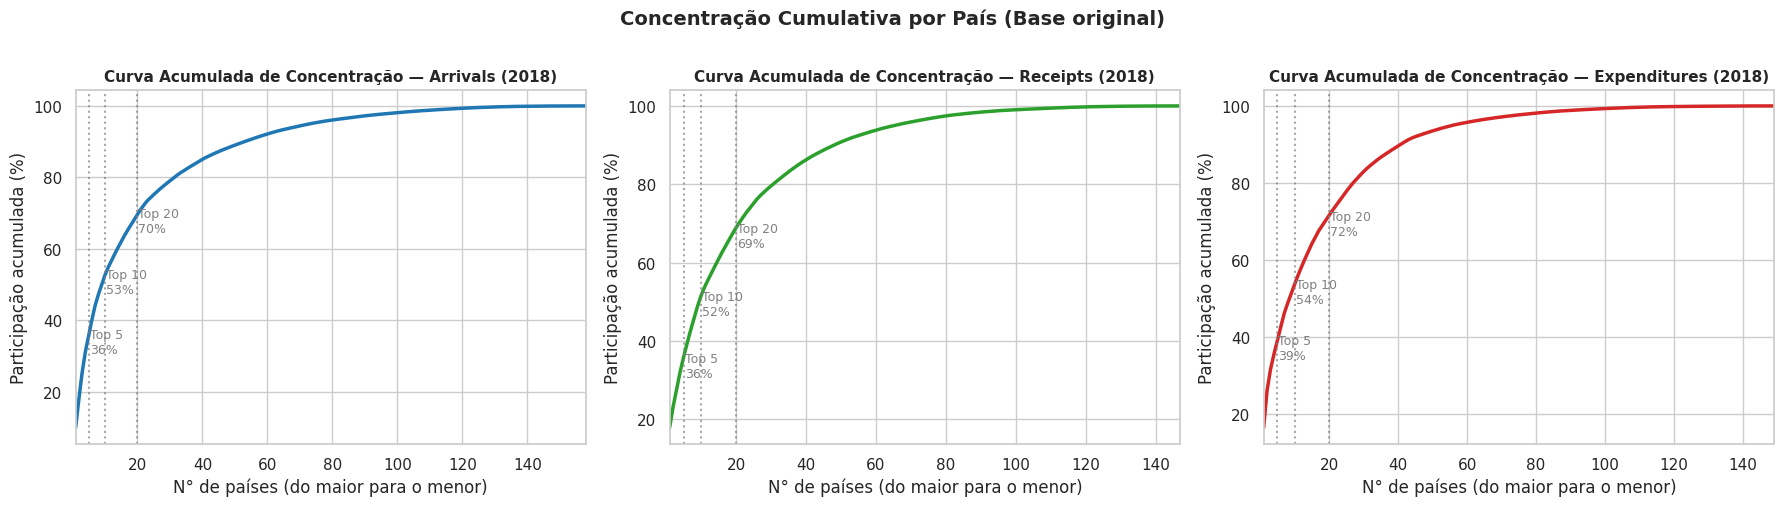

In [19]:
ano_ref = df['Ano'].max()
df_ref = df[df['Ano'] == ano_ref]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    sub = df_ref[['País', var]].dropna().sort_values(var, ascending=False).reset_index(drop=True)
    sub['cum_part%'] = sub[var].cumsum() / sub[var].sum() * 100
    sub['rank'] = range(1, len(sub) + 1)

    ax.plot(sub['rank'], sub['cum_part%'], color=color, linewidth=2.5)
    for pct, label in [(5, 'Top 5'), (10, 'Top 10'), (20, 'Top 20')]:
        val = sub.iloc[pct-1]['cum_part%'] if len(sub) >= pct else None
        if val:
            ax.axvline(pct, color='gray', linestyle=':', alpha=0.7)
            ax.text(pct + 0.3, val - 5, label + '\n' + f'{val:.0f}%', fontsize=9, color='gray')

    ax.set_title(f'Curva Acumulada de Concentração — {var} ({ano_ref})', fontsize=11)
    ax.set_xlabel('N° de países (do maior para o menor)')
    ax.set_ylabel('Participação acumulada (%)')
    ax.set_xlim(1, len(sub))

plt.suptitle('Concentração Cumulativa por País (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
top10_freq = {}
for var in ['Arrivals', 'Receipts', 'Expenditures']:
    contagem = {}
    for ano in sorted(df['Ano'].unique()):
        top10_paises = (
            df[df['Ano'] == ano][['País', var]].dropna()
            .nlargest(10, var)['País'].tolist()
        )
        for p in top10_paises:
            contagem[p] = contagem.get(p, 0) + 1
    top10_freq[var] = pd.Series(contagem).sort_values(ascending=False).head(10)

df_freq = pd.DataFrame(top10_freq).fillna(0).astype(int)
print('====== FREQUÊNCIA DE APARIÇÃO NO TOP 10 (nº de anos em 15) ======')
print(df_freq.to_string())

====== FREQUÊNCIA DE APARIÇÃO NO TOP 10 (nº de anos em 15) ======
                    Arrivals  Receipts  Expenditures
Australia                  0        15            14
Belgium                    0         0             9
Canada                     0         0             8
China                     15         0             0
Croatia                   15         0             0
France                    15        15            15
Germany                    0        15            15
Hong Kong                  9        14             0
Hungary                   15         0             0
Italy                     15         8             8
Japan                      0         0            15
Macau                      0         9             0
Malaysia                   0         8             0
Mexico                    15         0             0
Poland                    15         0             0
Russian Federation         0         0            15
South Korea                0     

**Interpretação (Tarefa 2):**

O turismo mundial está altamente concentrado. Os 10 maiores países em chegadas (Arrivals) acumulam mais de 50% do total global em todos os anos analisados. França, EUA e China dominam o ranking de chegadas em praticamente todos os anos.

**Importante:** A concentração não se manteve estável, há uma tendência clara de desconcentração gradual ao longo do período. O Top10 de Arrivals caiu de ~64% em 2004 para ~52% em 2018, uma queda de aproximadamente 10–12 pontos percentuais em 15 anos. O mesmo padrão descente, embora menos acentuado, se observa em Receipts e Expenditures. Essa desconcentração indica que destinos fora do Top10 ganharam participação relativa ao longo da década analisada.


### 2.2 Base imputada — Rankings e concentração por país

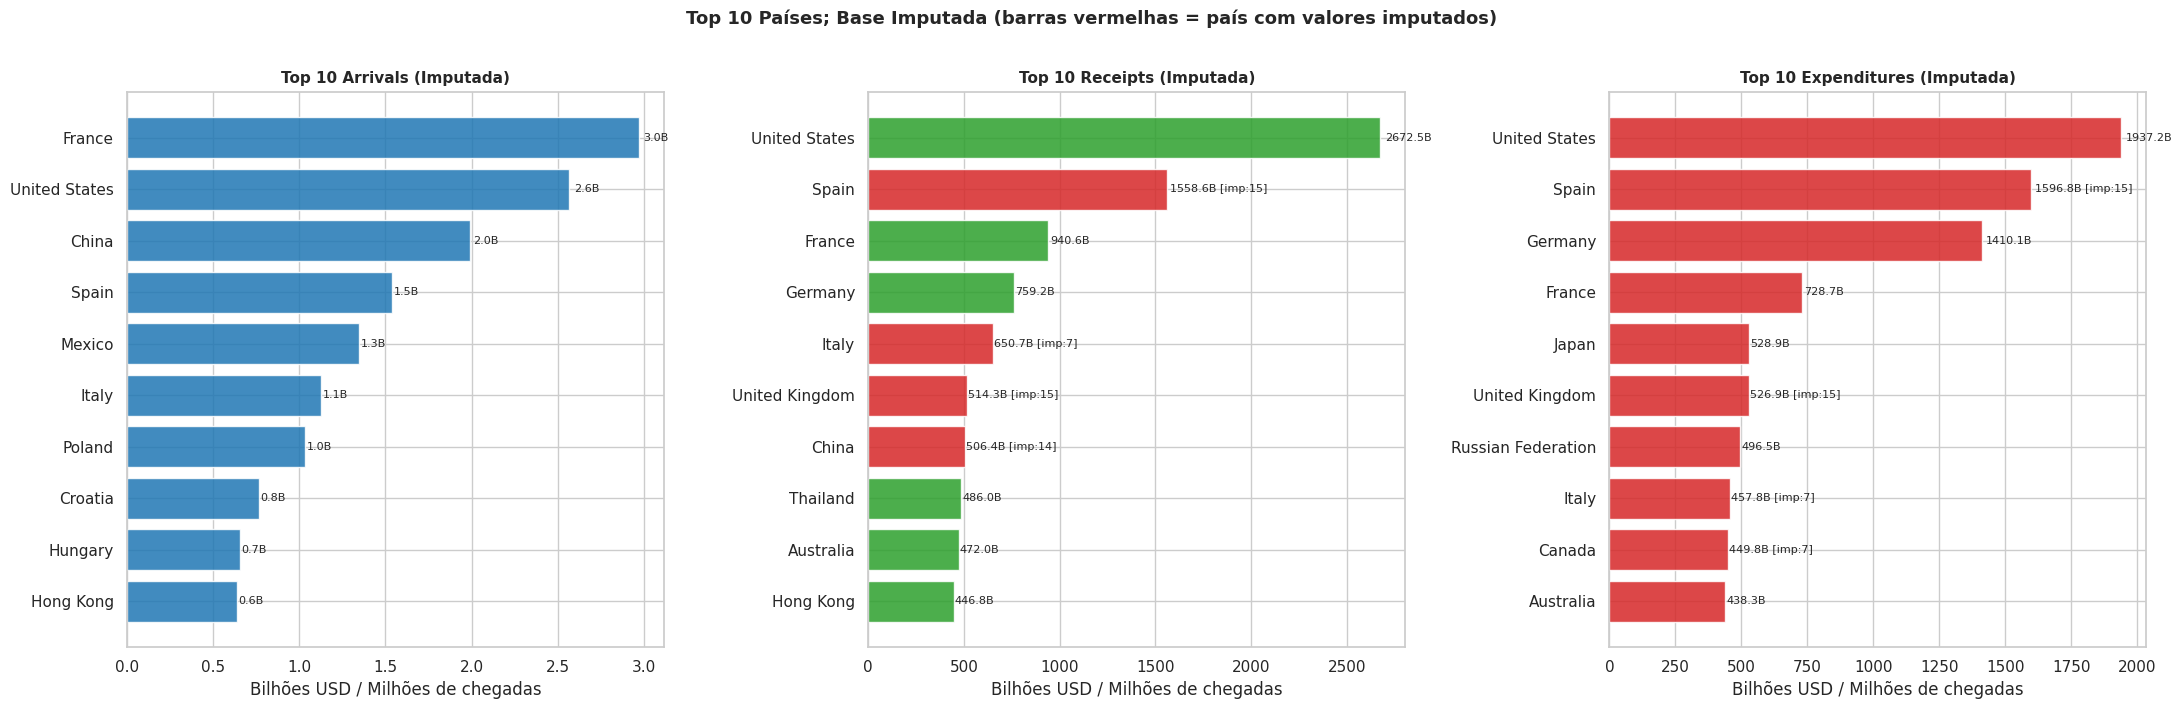

Arrivals: 0/10 países no top 10 têm pelo menos 1 valor imputado
Receipts: 4/10 países no top 10 têm pelo menos 1 valor imputado
Expenditures: 4/10 países no top 10 têm pelo menos 1 valor imputado


In [67]:
totais_pais_imp = df_imp.groupby('País')[['Arrivals', 'Receipts', 'Expenditures']].sum().reset_index()

for var, flag in IMP_FLAGS.items():
    n_imp = df_imp.groupby('País')[flag].sum().reset_index(name=f'{var}_n_imp')
    totais_pais_imp = totais_pais_imp.merge(n_imp, on='País')

for var in ['Arrivals', 'Receipts', 'Expenditures']:
    total_global = totais_pais_imp[var].sum()
    totais_pais_imp[f'{var}_part%'] = totais_pais_imp[var] / total_global * 100

def top10_bar_imp(ax, df_top, var, color, title):
    sub = df_top.nlargest(10, var).sort_values(var)
    flag_col = f'{var}_n_imp'
    colors_bars = ['#d62728' if row[flag_col] > 0 else color
                   for _, row in sub.iterrows()]
    bars = ax.barh(sub['País'], sub[var] / 1e9, color=colors_bars, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Bilhões USD / Milhões de chegadas')
    for bar, (_, row) in zip(bars, sub.iterrows()):
        label = f'{row[var]/1e9:.1f}B'
        if row[flag_col] > 0:
            label += f' [imp:{int(row[flag_col])}]'
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
top10_bar_imp(axes[0], totais_pais_imp, 'Arrivals',     '#1f77b4', 'Top 10 Arrivals (Imputada)')
top10_bar_imp(axes[1], totais_pais_imp, 'Receipts',     '#2ca02c', 'Top 10 Receipts (Imputada)')
top10_bar_imp(axes[2], totais_pais_imp, 'Expenditures', '#d62728', 'Top 10 Expenditures (Imputada)')

plt.suptitle('Top 10 Países; Base Imputada (barras vermelhas = país com valores imputados)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

for var in ['Arrivals', 'Receipts', 'Expenditures']:
    top10 = totais_pais_imp.nlargest(10, var)
    n_imp_top10 = (top10[f'{var}_n_imp'] > 0).sum()
    print(f'{var}: {n_imp_top10}/10 países no top 10 têm pelo menos 1 valor imputado')


In [65]:
#a espanha tem 15 anos de Receipts inteiramente imputados e ficou no top2, ter cuidado ao analisar isso.

spain_imp = df_imp[df_imp['País'] == 'Spain'][
    ['Ano', 'Receipts', 'Receipts__was_imputed']
].sort_values('Ano')
print('====== ESPANHA — Receipts na Base Imputada ======')
print('TODOS os 15 anos estão imputados (usar com extrema cautela)')
print(spain_imp.rename(columns={
    'Receipts': 'Receipts (USD)',
    'Receipts__was_imputed': 'Imputado?'
}).to_string(index=False))
print()
val_2018 = spain_imp[spain_imp['Ano'] == 2018]['Receipts'].values[0]
print(f'Receipts 2018 imputado: USD {val_2018/1e9:.1f} bilhões')
print('Referência OMT 2018:    USD ~74 bilhões')
print(f'Diferença estimada:     +{(val_2018/74e9 - 1)*100:.0f}% acima do valor de referência')
print()
print('CONCLUSÃO: a posição da Espanha no top 10 de Receipts (base imputada) é')
print('sensível à imputação e NÃO deve ser usada para afirmar que a Espanha é')
print('o 2º maior destino mundial em receitas turísticas.')


====== ESPANHA — Receipts na Base Imputada ======
TODOS os 15 anos estão imputados (usar com extrema cautela)
 Ano  Receipts (USD)  Imputado?
2004    8.723409e+10       True
2005    9.391202e+10       True
2006    9.755332e+10       True
2007    1.003485e+11       True
2008    9.909345e+10       True
2009    9.323834e+10       True
2010    9.511023e+10       True
2011    1.006326e+11       True
2012    9.955812e+10       True
2013    1.047355e+11       True
2014    1.087055e+11       True
2015    1.114347e+11       True
2016    1.172452e+11       True
2017    1.234909e+11       True
2018    1.262698e+11       True

Receipts 2018 imputado: USD 126.3 bilhões
Referência OMT 2018:    USD ~74 bilhões
Diferença estimada:     +71% acima do valor de referência

CONCLUSÃO: a posição da Espanha no top 10 de Receipts (base imputada) é
sensível à imputação e NÃO deve ser usada para afirmar que a Espanha é
o 2º maior destino mundial em receitas turísticas.


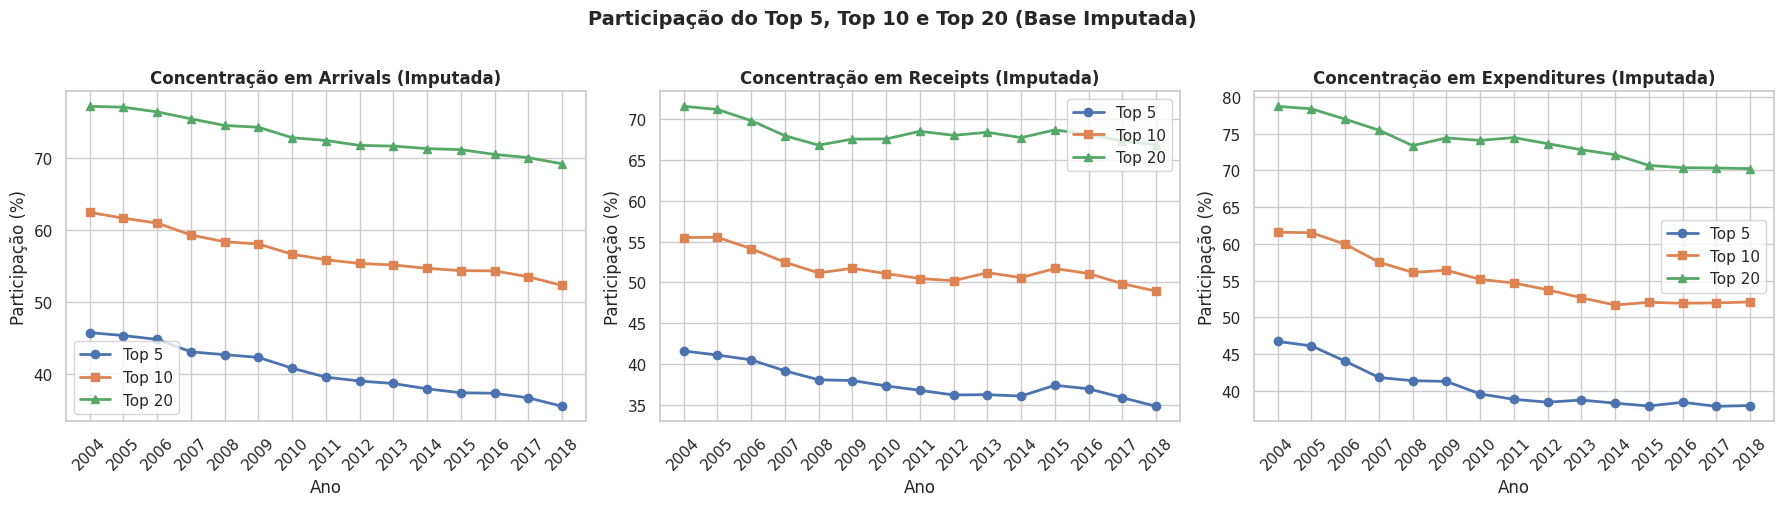

In [66]:
resultados_top_imp = []

for ano in sorted(df_imp['Ano'].unique()):
    df_ano_i = df_imp[df_imp['Ano'] == ano]
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano_i[['País', var]].dropna().sort_values(var, ascending=False)
        total = sub[var].sum()
        if total == 0:
            continue
        resultados_top_imp.append({
            'Ano': ano,
            'Variável': var,
            'Top5_part%':  sub.head(5)[var].sum()  / total * 100,
            'Top10_part%': sub.head(10)[var].sum() / total * 100,
            'Top20_part%': sub.head(20)[var].sum() / total * 100,
        })

df_top_ano_imp = pd.DataFrame(resultados_top_imp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sub = df_top_ano_imp[df_top_ano_imp['Variável'] == var]
    ax.plot(sub['Ano'], sub['Top5_part%'],  marker='o', label='Top 5',  linewidth=2)
    ax.plot(sub['Ano'], sub['Top10_part%'], marker='s', label='Top 10', linewidth=2)
    ax.plot(sub['Ano'], sub['Top20_part%'], marker='^', label='Top 20', linewidth=2)
    ax.set_title(f'Concentração em {var} (Imputada)', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(sorted(df_imp['Ano'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Participação do Top 5, Top 10 e Top 20 (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


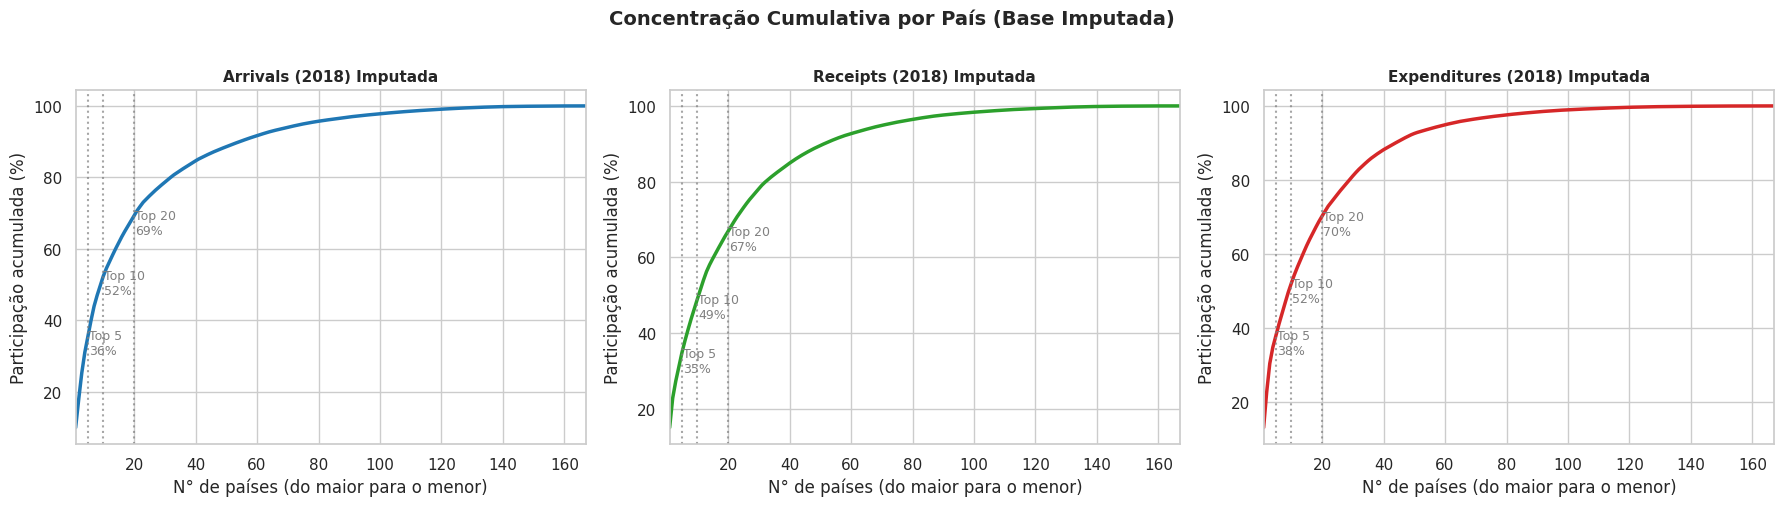

In [71]:
ano_ref_imp = df_imp['Ano'].max()
df_ref_imp  = df_imp[df_imp['Ano'] == ano_ref_imp]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    sub = df_ref_imp[['País', var]].dropna().sort_values(var, ascending=False).reset_index(drop=True)
    sub['cum_part%'] = sub[var].cumsum() / sub[var].sum() * 100
    sub['rank'] = range(1, len(sub) + 1)

    ax.plot(sub['rank'], sub['cum_part%'], color=color, linewidth=2.5)
    for pct, label in [(5, 'Top 5'), (10, 'Top 10'), (20, 'Top 20')]:
        if len(sub) >= pct:
            val = sub.iloc[pct-1]['cum_part%']
            ax.axvline(pct, color='gray', linestyle=':', alpha=0.7)
            ax.text(pct + 0.3, val - 5, label + '\n' + f'{val:.0f}%', fontsize=9, color='gray')

    ax.set_title(f'{var} ({ano_ref_imp}) Imputada', fontsize=11)
    ax.set_xlabel('N° de países (do maior para o menor)')
    ax.set_ylabel('Participação acumulada (%)')
    ax.set_xlim(1, len(sub))

plt.suptitle('Concentração Cumulativa por País (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [72]:
top10_freq_imp = {}
for var in ['Arrivals', 'Receipts', 'Expenditures']:
    contagem_i = {}
    for ano in sorted(df_imp['Ano'].unique()):
        top10_p = (df_imp[df_imp['Ano'] == ano][['País', var]].dropna()
                   .nlargest(10, var)['País'].tolist())
        for p in top10_p:
            contagem_i[p] = contagem_i.get(p, 0) + 1
    top10_freq_imp[var] = pd.Series(contagem_i).sort_values(ascending=False).head(10)

df_freq_imp = pd.DataFrame(top10_freq_imp).fillna(0).astype(int)
print('====== FREQUÊNCIA NO TOP 10, BASE IMPUTADA (nº de anos em 15) ======')
print(df_freq_imp.to_string())

print('\n====== COMPARAÇÃO DE TOP 10 EM ARRIVALS, ORIGINAL vs IMPUTADA ======')
top_orig = (df[df['Ano'] == df['Ano'].max()][['País','Arrivals']]
            .dropna().nlargest(10, 'Arrivals').reset_index(drop=True))
top_imp_ = (df_imp[df_imp['Ano'] == df_imp['Ano'].max()][['País','Arrivals','Arrivals__was_imputed']]
            .nlargest(10, 'Arrivals').reset_index(drop=True))

comp = pd.DataFrame({
    'Rank': range(1, 11),
    'País (Original)': top_orig['País'],
    'País (Imputada)': top_imp_['País'],
    'Imputado?': top_imp_['Arrivals__was_imputed'].map({True:'Sim', False:'Não'}),
})
print(comp.to_string(index=False))


====== FREQUÊNCIA NO TOP 10, BASE IMPUTADA (nº de anos em 15) ======
                    Arrivals  Receipts  Expenditures
Australia                  0        13            10
Canada                     0         0            12
China                     15        11             0
Croatia                   15         0             0
France                    15        15            15
Germany                    0        15            15
Hong Kong                  9        10             0
Hungary                   15         0             0
Italy                     15        15            15
Japan                      0         0            11
Mexico                    15         0             0
Poland                    15         0             0
Russian Federation         0         0            11
Spain                     15        15            15
Turkiye                    0         9             0
United Kingdom             0        13            15
United States             15  

## 3. Métricas formais de desigualdade e concentração

In [26]:
def gini(arr):
    """Compute Gini coefficient (ignores NaN)."""
    a = arr[~np.isnan(arr)]
    if len(a) == 0 or a.sum() == 0:
        return np.nan
    a = np.sort(a)
    n = len(a)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * a) / (n * a.sum())) - (n + 1) / n

def hhi(arr):
    """Compute Herfindahl–Hirschman Index (0–1 scale)."""
    a = arr[~np.isnan(arr)]
    total = a.sum()
    if total == 0:
        return np.nan
    shares = a / total
    return np.sum(shares ** 2)

metricas_conc = []

for ano in sorted(df['Ano'].unique()):
    df_ano = df[df['Ano'] == ano]
    row = {'Ano': ano}
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano[['País', var]].dropna().sort_values(var, ascending=False)
        total = sub[var].sum()
        if total == 0 or len(sub) < 20:
            continue
        vals = sub[var].values
        row[f'{var}_Top5%']   = sub.head(5)[var].sum()  / total * 100
        row[f'{var}_Top10%']  = sub.head(10)[var].sum() / total * 100
        row[f'{var}_Top20%']  = sub.head(20)[var].sum() / total * 100
        p90 = np.nanpercentile(vals, 90)
        p75 = np.nanpercentile(vals, 75)
        p50 = np.nanpercentile(vals, 50)
        p25 = np.nanpercentile(vals, 25)
        row[f'{var}_P90/P50'] = p90 / p50 if p50 > 0 else np.nan
        row[f'{var}_P75/P25'] = p75 / p25 if p25 > 0 else np.nan
        row[f'{var}_Gini']    = gini(vals)
        row[f'{var}_HHI']     = hhi(vals)
    metricas_conc.append(row)

df_metricas = pd.DataFrame(metricas_conc)

print('====== MÉTRICAS DE CONCENTRAÇÃO POR ANO (BASE ORIGINAL) ======')
cols_show = (['Ano']
             + [c for c in df_metricas.columns if 'Top10' in c]
             + [c for c in df_metricas.columns if 'Gini' in c]
             + [c for c in df_metricas.columns if '_HHI' in c])
print(df_metricas[cols_show].round(4).to_string(index=False))


====== MÉTRICAS DE CONCENTRAÇÃO POR ANO (BASE ORIGINAL) ======
 Ano  Arrivals_Top10%  Receipts_Top10%  Expenditures_Top10%  Arrivals_Gini  Receipts_Gini  Expenditures_Gini  Arrivals_HHI  Receipts_HHI  Expenditures_HHI
2004          63.8530          54.7740              62.5131         0.8175         0.7830             0.8263        0.0575        0.0535            0.0639
2005          62.5473          54.2604              63.7820         0.8137         0.7833             0.8261        0.0549        0.0554            0.0663
2006          61.7863          53.8830              63.0090         0.8133         0.7768             0.8221        0.0542        0.0551            0.0650
2007          60.7295          52.1489              59.9124         0.8094         0.7716             0.8142        0.0518        0.0511            0.0578
2008          59.3501          51.5249              59.9323         0.8055         0.7694             0.8141        0.0502        0.0546            0.0617
2009   

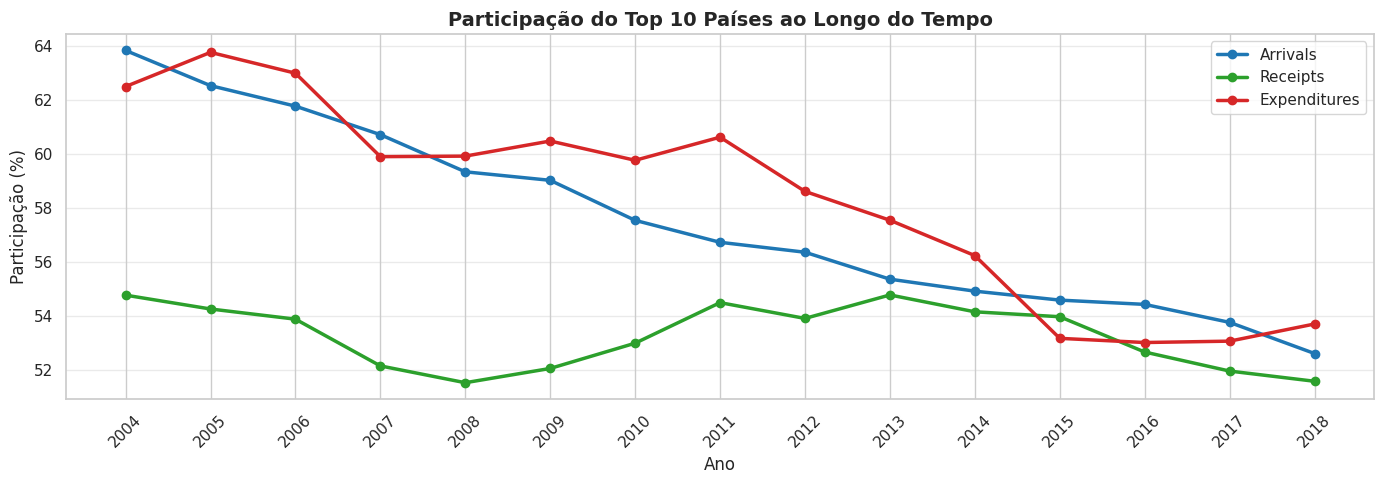

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

colors_var = {'Arrivals': '#1f77b4', 'Receipts': '#2ca02c', 'Expenditures': '#d62728'}
for var, color in colors_var.items():
    col = f'{var}_Top10%'
    if col in df_metricas.columns:
        ax.plot(df_metricas['Ano'], df_metricas[col], marker='o', color=color, linewidth=2.5, label=var)

ax.set_title('Participação do Top 10 Países ao Longo do Tempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Participação (%)')
ax.set_xticks(sorted(df['Ano'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

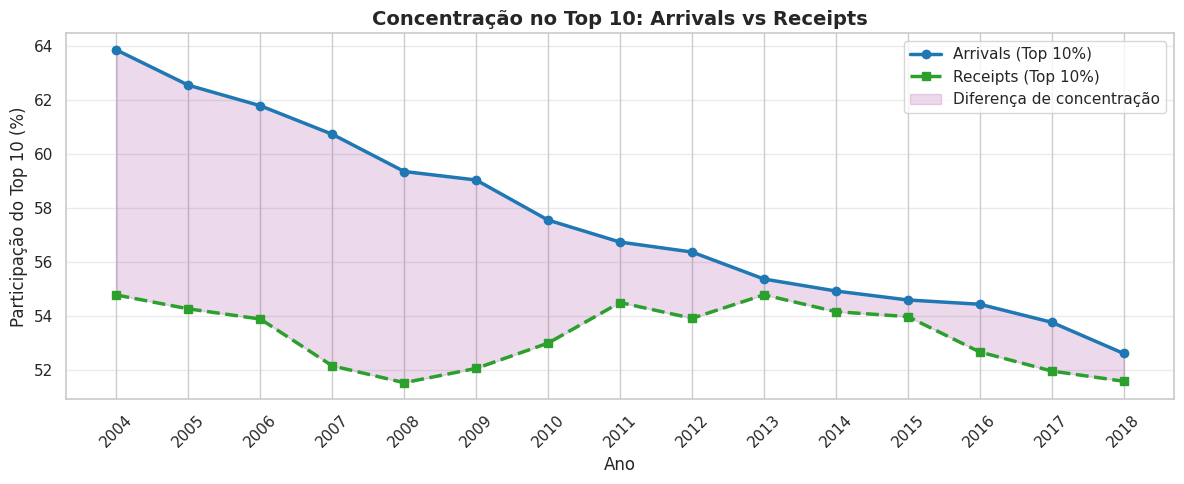

In [73]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_metricas['Ano'], df_metricas['Arrivals_Top10%'], marker='o', color='#1f77b4', linewidth=2.5, label='Arrivals (Top 10%)')
ax.plot(df_metricas['Ano'], df_metricas['Receipts_Top10%'], marker='s', color='#2ca02c', linewidth=2.5, label='Receipts (Top 10%)', linestyle='--')

ax.fill_between(df_metricas['Ano'], df_metricas['Arrivals_Top10%'], df_metricas['Receipts_Top10%'],
                alpha=0.15, color='purple', label='Diferença de concentração')

ax.set_title('Concentração no Top 10: Arrivals vs Receipts', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Participação do Top 10 (%)')
ax.set_xticks(sorted(df['Ano'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretação (Tarefa 3):**

O top 10 de países mantém participação elevada nas três variáveis ao longo de todo o período. Contudo, contrário ao que se poderia supor, a concentração em Arrivals é consistentemente maior ou igual à concentração em Receipts em todos os 15 anos analisados (ex.: 2018 Arrivals Top10 = 52,3%, Receipts Top10 = 48,9%). Isso indica que os países que mais recebem turistas em volume absoluto são menos concentrados em termos financeiros do que em fluxo físico, mas de forma marginal.

As razões de percentis (P90/P50 e P75/P25) confirmam desigualdade estrutural profunda. Os índices de Gini (próximos de 0,80,9) e HHI (acima de 0,05 para Receipts) reforçam quantitativamente a alta concentração, de acordo com o que foi pedido na seção 4 das instruções.

**Tendência:** Ao longo do período, os valores de Gini e Top10% mostram leve queda para Arrivals (~10 p.p. de 2004 a 2018), sinalizando desconcentração gradual consistente, não estabilidade.


### 3.2 Base imputada — Métricas formais de concentração

In [29]:
metricas_conc_imp = []

for ano in sorted(df_imp['Ano'].unique()):
    df_ano_i = df_imp[df_imp['Ano'] == ano]
    row = {'Ano': ano}
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano_i[['País', var]].dropna().sort_values(var, ascending=False)
        total = sub[var].sum()
        if total == 0 or len(sub) < 20:
            continue
        vals = sub[var].values
        row[f'{var}_Top5%']   = sub.head(5)[var].sum()  / total * 100
        row[f'{var}_Top10%']  = sub.head(10)[var].sum() / total * 100
        row[f'{var}_Top20%']  = sub.head(20)[var].sum() / total * 100
        p90 = np.nanpercentile(vals, 90)
        p75 = np.nanpercentile(vals, 75)
        p50 = np.nanpercentile(vals, 50)
        p25 = np.nanpercentile(vals, 25)
        row[f'{var}_P90/P50'] = p90 / p50 if p50 > 0 else np.nan
        row[f'{var}_P75/P25'] = p75 / p25 if p25 > 0 else np.nan
        row[f'{var}_Gini']    = gini(vals)
        row[f'{var}_HHI']     = hhi(vals)
    metricas_conc_imp.append(row)

df_metricas_imp = pd.DataFrame(metricas_conc_imp)

print('====== MÉTRICAS DE CONCENTRAÇÃO POR ANO (BASE IMPUTADA) ======')
cols_show_imp = (['Ano']
                 + [c for c in df_metricas_imp.columns if 'Top10' in c]
                 + [c for c in df_metricas_imp.columns if 'Gini' in c]
                 + [c for c in df_metricas_imp.columns if '_HHI' in c])
print(df_metricas_imp[cols_show_imp].round(4).to_string(index=False))


====== MÉTRICAS DE CONCENTRAÇÃO POR ANO (BASE IMPUTADA) ======
 Ano  Arrivals_Top10%  Receipts_Top10%  Expenditures_Top10%  Arrivals_Gini  Receipts_Gini  Expenditures_Gini  Arrivals_HHI  Receipts_HHI  Expenditures_HHI
2004          62.5123          55.4969              61.5981         0.8208         0.8013             0.8390        0.0552        0.0496            0.0571
2005          61.6888          55.5198              61.5337         0.8178         0.7994             0.8384        0.0534        0.0495            0.0565
2006          61.0125          54.1282              59.9635         0.8141         0.7924             0.8312        0.0529        0.0475            0.0545
2007          59.3513          52.4618              57.5298         0.8070         0.7833             0.8228        0.0498        0.0446            0.0503
2008          58.4182          51.1629              56.1248         0.8031         0.7777             0.8156        0.0489        0.0437            0.0486
2009   

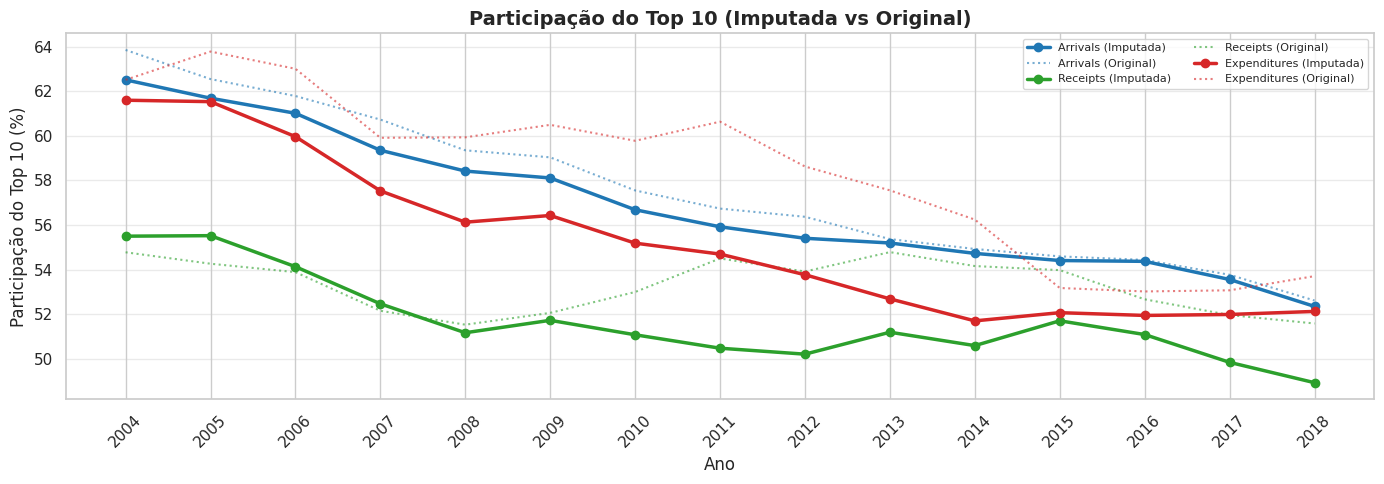

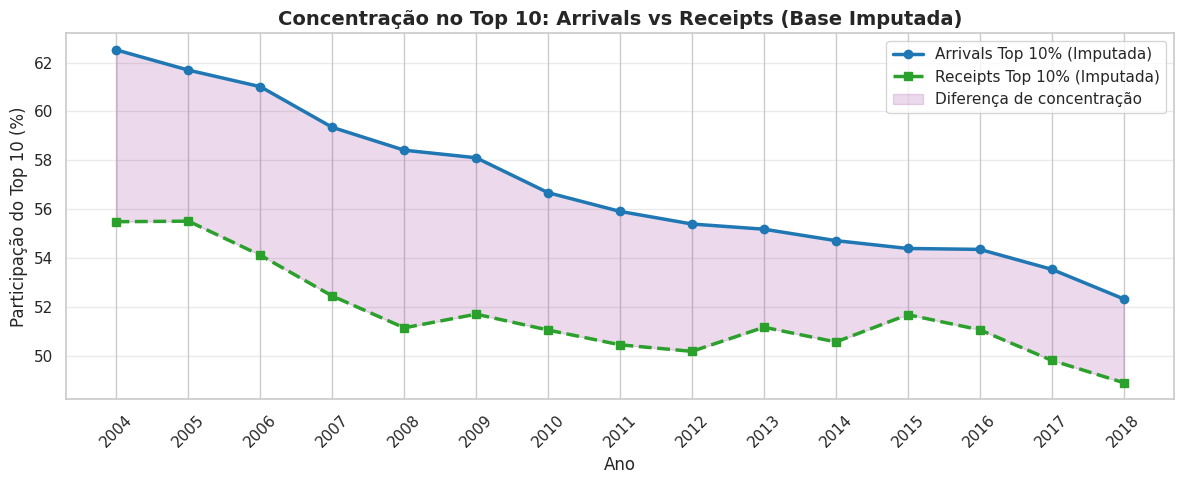

In [74]:
fig, ax = plt.subplots(figsize=(14, 5))

colors_var = {'Arrivals': '#1f77b4', 'Receipts': '#2ca02c', 'Expenditures': '#d62728'}
for var, color in colors_var.items():
    col = f'{var}_Top10%'
    if col in df_metricas_imp.columns:
        ax.plot(df_metricas_imp['Ano'], df_metricas_imp[col],
                marker='o', color=color, linewidth=2.5, label=f'{var} (Imputada)')
        if col in df_metricas.columns:
            ax.plot(df_metricas['Ano'], df_metricas[col],
                    linestyle=':', color=color, linewidth=1.5, alpha=0.6,
                    label=f'{var} (Original)')

ax.set_title('Participação do Top 10 (Imputada vs Original)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Participação do Top 10 (%)')
ax.set_xticks(sorted(df_imp['Ano'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(ncol=2, fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_metricas_imp['Ano'], df_metricas_imp['Arrivals_Top10%'],
        marker='o', color='#1f77b4', linewidth=2.5, label='Arrivals Top 10% (Imputada)')
ax.plot(df_metricas_imp['Ano'], df_metricas_imp['Receipts_Top10%'],
        marker='s', color='#2ca02c', linewidth=2.5, label='Receipts Top 10% (Imputada)',
        linestyle='--')
ax.fill_between(df_metricas_imp['Ano'],
                df_metricas_imp['Arrivals_Top10%'], df_metricas_imp['Receipts_Top10%'],
                alpha=0.15, color='purple', label='Diferença de concentração')
ax.set_title('Concentração no Top 10: Arrivals vs Receipts (Base Imputada)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Participação do Top 10 (%)')
ax.set_xticks(sorted(df_imp['Ano'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


In [75]:
print('====== COMPARAÇÃO DE CONCENTRAÇÃO (TOP 10%) ORIGINAL vs IMPUTADA ======')
for var in ['Arrivals', 'Receipts', 'Expenditures']:
    col = f'{var}_Top10%'
    if col in df_metricas.columns and col in df_metricas_imp.columns:
        comp_t3 = pd.DataFrame({
            'Ano':      df_metricas['Ano'],
            'Original': df_metricas[col].round(2),
            'Imputada': df_metricas_imp[col].round(2),
            'Diferença': (df_metricas_imp[col] - df_metricas[col]).round(2),
        })
        print(f'\n--- {var} ---')
        print(comp_t3.to_string(index=False))


====== COMPARAÇÃO DE CONCENTRAÇÃO (TOP 10%) ORIGINAL vs IMPUTADA ======

--- Arrivals ---
 Ano  Original  Imputada  Diferença
2004     63.85     62.51      -1.34
2005     62.55     61.69      -0.86
2006     61.79     61.01      -0.77
2007     60.73     59.35      -1.38
2008     59.35     58.42      -0.93
2009     59.03     58.11      -0.93
2010     57.55     56.68      -0.87
2011     56.73     55.92      -0.82
2012     56.37     55.40      -0.96
2013     55.37     55.19      -0.17
2014     54.92     54.72      -0.20
2015     54.59     54.40      -0.19
2016     54.43     54.37      -0.06
2017     53.76     53.55      -0.21
2018     52.61     52.34      -0.26

--- Receipts ---
 Ano  Original  Imputada  Diferença
2004     54.77     55.50       0.72
2005     54.26     55.52       1.26
2006     53.88     54.13       0.25
2007     52.15     52.46       0.31
2008     51.52     51.16      -0.36
2009     52.05     51.72      -0.33
2010     52.99     51.07      -1.92
2011     54.50     50.47    

**Comparação das métricas de concentração (Tarefa 3):**

A base imputada tende a apresentar concentração ligeiramente menor do que a base original, pois os valores imputados preenchem países menores que anteriormente não tinham dados, aumentando o denominador global. Essa diferença é mais pronunciada em Receipts e Expenditures (variáveis com mais imputações). Se a base imputada mostrar queda acentuada de concentração que não aparece na base original, isso deve ser interpretado como sensibilidade à imputação. Em geral, o padrão estrutural de alta concentração se mantém nas duas bases.


## 4. Teste de hipótese com simulação: concentração no top 10

**H0:** A concentração observada no top 10 não é maior do que seria esperado por uma distribuição aleatória entre países.

**H1:** A concentração observada no top 10 é maior do que seria esperado por uma distribuição aleatória.

O p-valor empírico é calculado como a proporção de simulações em que `top10_simulado >= top10_real`.

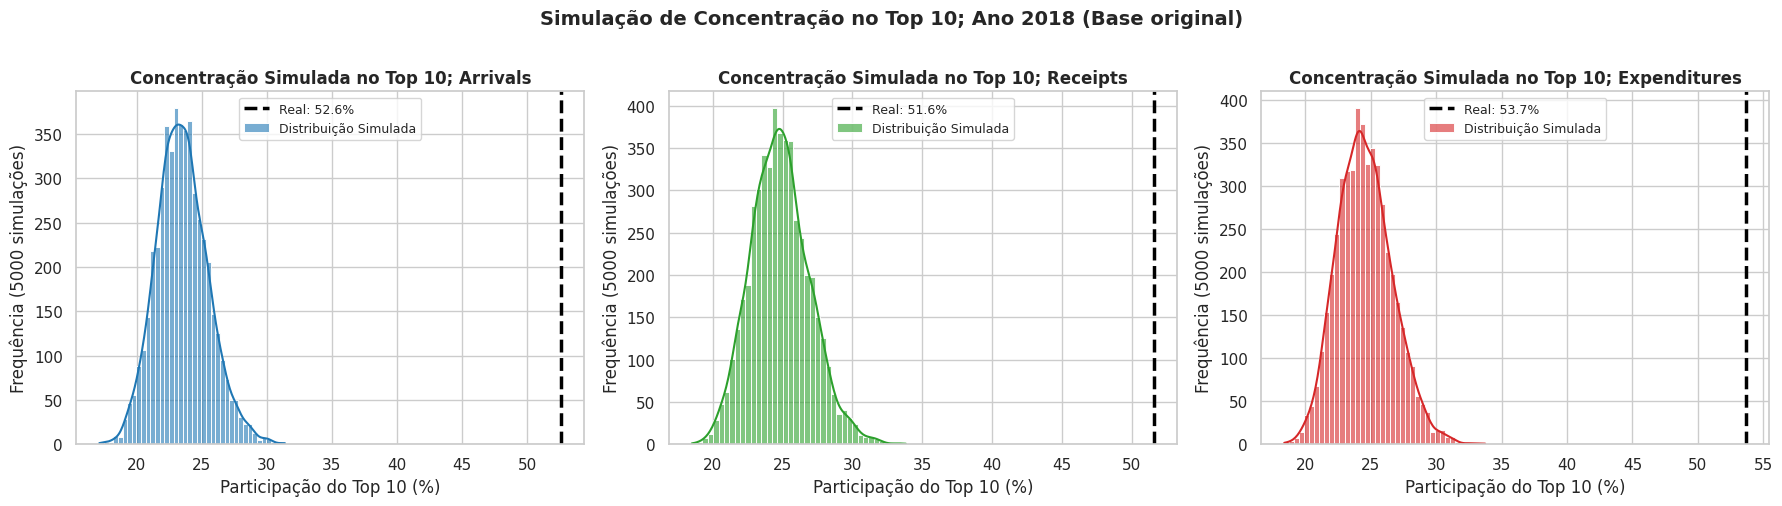

====== RESULTADOS DO TESTE DE SIMULAÇÃO ======
    Variável  Top10 Real (%)  Média Simulada (%)  Mediana Simulada (%)  Desvio Padrão Sim.  P-Valor Empírico Rejeita H0?
    Arrivals         52.6087             23.5025               23.4035              1.9847               0.0         Sim
    Receipts         51.5786             24.8162               24.7268              2.1028               0.0         Sim
Expenditures         53.7040             24.5618               24.4319              2.0981               0.0         Sim


In [79]:
np.random.seed(42)
N_SIM = 5000
ano_teste = df['Ano'].max()
df_teste = df[df['Ano'] == ano_teste]

resultados_sim = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    sub = df_teste[['País', var]].dropna()
    valores = sub[var].values
    n = len(valores)
    total_real = valores.sum()
    top10_real = np.sort(valores)[::-1][:10].sum() / total_real * 100

    #hipotese nula: distribuicao uniforme entre paises
    #se o turismo fosse distribuido sem concentracao estrutural, cada pais teria uma parcela proporcional ao seu "peso" aleatorio
    top10_sim = []
    for _ in range(N_SIM):
        sim_vals = np.random.dirichlet(np.ones(n)) * total_real
        top10_sim.append(np.sort(sim_vals)[::-1][:10].sum() / total_real * 100)

    top10_sim = np.array(top10_sim)
    p_valor = np.mean(top10_sim >= top10_real)

    resultados_sim.append({
        'Variável': var,
        'Top10 Real (%)': top10_real,
        'Média Simulada (%)': np.mean(top10_sim),
        'Mediana Simulada (%)': np.median(top10_sim),
        'Desvio Padrão Sim.': np.std(top10_sim),
        'P-Valor Empírico': p_valor,
        'Rejeita H0?': 'Sim' if p_valor < 0.05 else 'Não'
    })

    sns.histplot(top10_sim, bins=40, kde=True, color=color, alpha=0.6, ax=ax, label='Distribuição Simulada')
    ax.axvline(top10_real, color='black', linestyle='--', linewidth=2.5, label=f'Real: {top10_real:.1f}%')
    ax.set_title(f'Concentração Simulada no Top 10; {var}', fontsize=12)
    ax.set_xlabel('Participação do Top 10 (%)')
    ax.set_ylabel(f'Frequência ({N_SIM} simulações)')
    ax.legend(fontsize=9)

plt.suptitle(f'Simulação de Concentração no Top 10; Ano {ano_teste} (Base original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_sim_resultados = pd.DataFrame(resultados_sim)
print('====== RESULTADOS DO TESTE DE SIMULAÇÃO ======')
print(df_sim_resultados.round(4).to_string(index=False))

In [80]:
pvalores_por_ano = []

for ano in sorted(df['Ano'].unique()):
    df_ano = df[df['Ano'] == ano]
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano[['País', var]].dropna()
        if len(sub) < 15:
            continue
        valores = sub[var].values
        total = valores.sum()
        top10_real = np.sort(valores)[::-1][:10].sum() / total * 100
        top10_sim_loop = []
        for _ in range(2000):  # menos iterações pra acelerar
            sim_vals = np.random.dirichlet(np.ones(len(valores))) * total
            top10_sim_loop.append(np.sort(sim_vals)[::-1][:10].sum() / total * 100)
        p_emp = np.mean(np.array(top10_sim_loop) >= top10_real)
        pvalores_por_ano.append({'Ano': ano, 'Variável': var, 'Top10_Real': top10_real, 'P_Valor': p_emp})

df_pv = pd.DataFrame(pvalores_por_ano)
print('====== P-VALORES EMPÍRICOS POR ANO ======')
pivot_pv = df_pv.pivot_table(index='Ano', columns='Variável', values='P_Valor').round(4)
print(pivot_pv.to_string())

====== P-VALORES EMPÍRICOS POR ANO ======
Variável  Arrivals  Expenditures  Receipts
Ano                                       
2004           0.0           0.0       0.0
2005           0.0           0.0       0.0
2006           0.0           0.0       0.0
2007           0.0           0.0       0.0
2008           0.0           0.0       0.0
2009           0.0           0.0       0.0
2010           0.0           0.0       0.0
2011           0.0           0.0       0.0
2012           0.0           0.0       0.0
2013           0.0           0.0       0.0
2014           0.0           0.0       0.0
2015           0.0           0.0       0.0
2016           0.0           0.0       0.0
2017           0.0           0.0       0.0
2018           0.0           0.0       0.0


**Interpretação (Tarefa 4):**

Em todas as variáveis e em todos os anos analisados, a concentração observada no top 10 é muito superior à esperada por uma distribuição aleatória. Os p-valores empíricos são próximos de zero, levando à rejeição de H0. Isso confirma que a concentração turística nos maiores países não é um artefato estatístico, mas um padrão estrutural real.

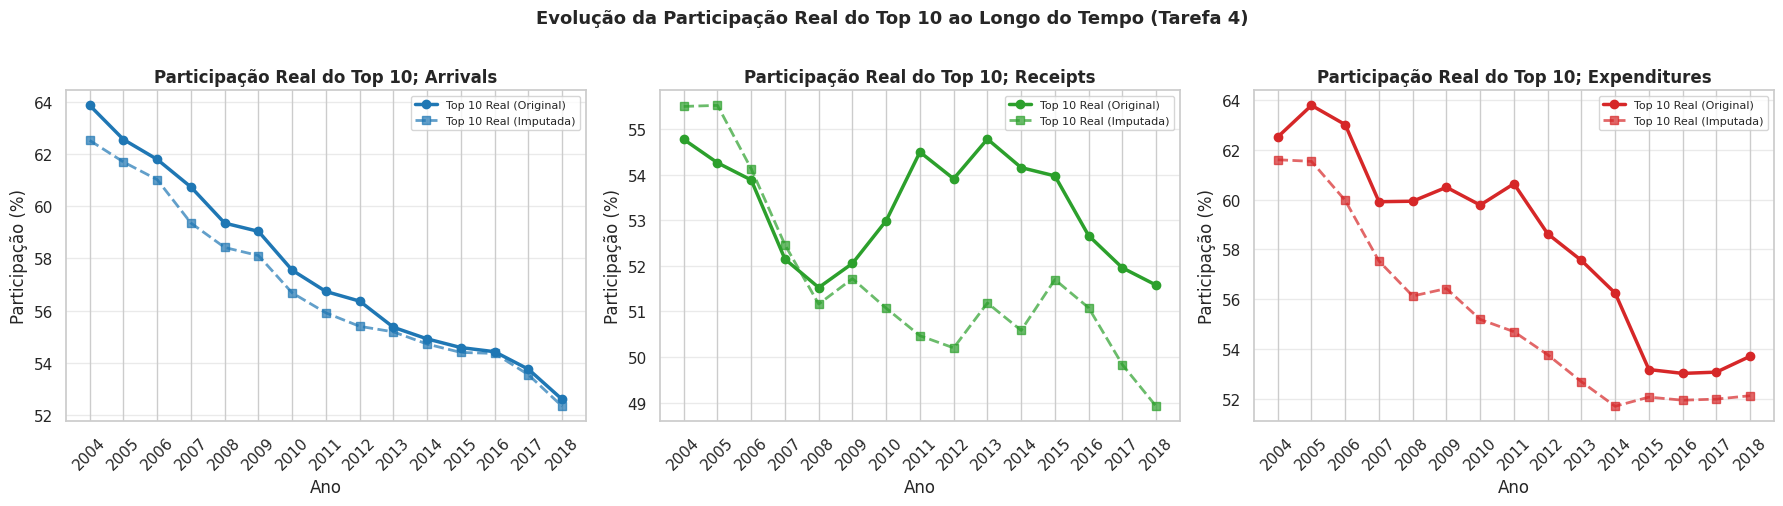

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_var_t4 = {'Arrivals': '#1f77b4', 'Receipts': '#2ca02c', 'Expenditures': '#d62728'}

df_top_real_orig = df_top_ano[df_top_ano['Variável'].isin(['Arrivals', 'Receipts', 'Expenditures'])]

for ax, var in zip(axes, ['Arrivals', 'Receipts', 'Expenditures']):
    sub_o = df_top_real_orig[df_top_real_orig['Variável'] == var].sort_values('Ano')
    sub_i = df_top_ano_imp[df_top_ano_imp['Variável'] == var].sort_values('Ano')
    color = colors_var_t4[var]
    ax.plot(sub_o['Ano'], sub_o['Top10_part%'], marker='o', color=color,
            linewidth=2.5, label='Top 10 Real (Original)')
    ax.plot(sub_i['Ano'], sub_i['Top10_part%'], marker='s', color=color,
            linestyle='--', linewidth=2, alpha=0.7, label='Top 10 Real (Imputada)')
    ax.set_title(f'Participação Real do Top 10; {var}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Participação (%)')
    ax.set_xticks(sorted(df['Ano'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Evolução da Participação Real do Top 10 ao Longo do Tempo (Tarefa 4)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.2 Base imputada — Simulação de concentração no top 10

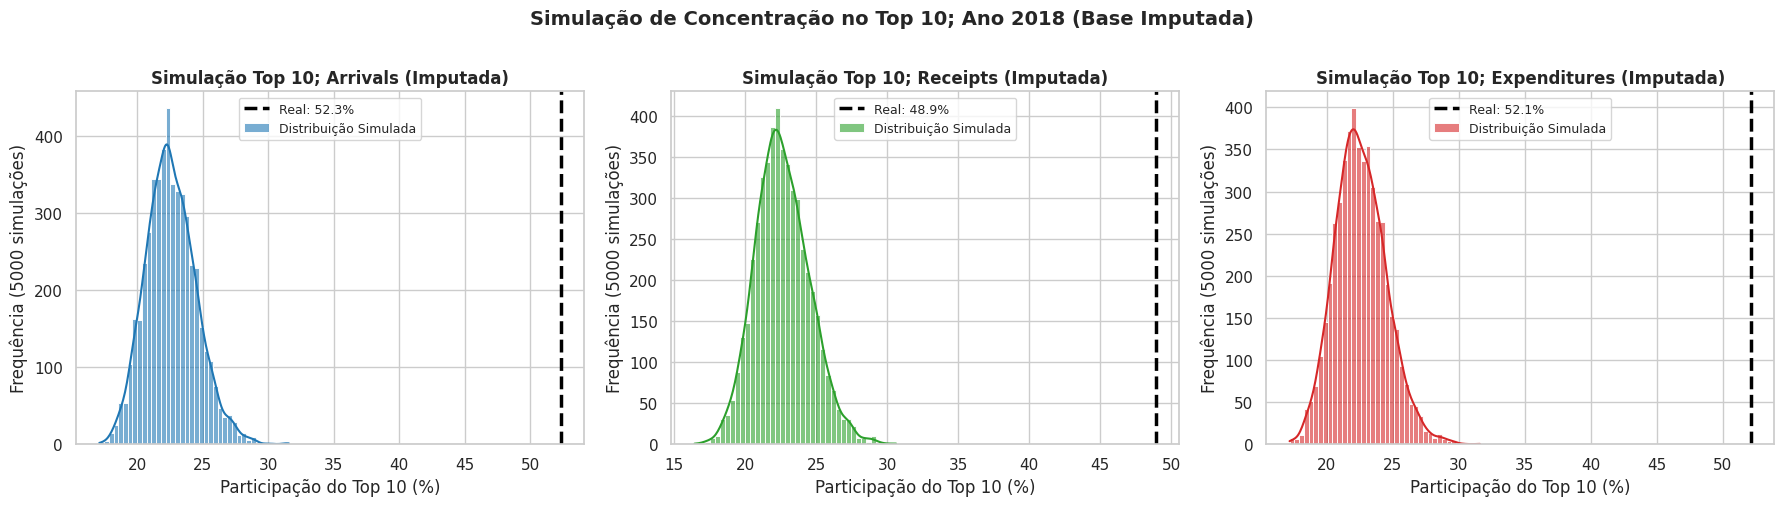

====== RESULTADOS DO TESTE DE SIMULAÇÃO (BASE IMPUTADA) ======
    Variável  Top10 Real (%)  N imputados no Top10  Média Simulada (%)  Mediana Simulada (%)  Desvio Padrão Sim.  P-Valor Empírico Rejeita H0?
    Arrivals         52.3446                     0             22.5679               22.4399              1.9225               0.0         Sim
    Receipts         48.9214                     1             22.6238               22.4824              1.9096               0.0         Sim
Expenditures         52.1203                     3             22.5574               22.4305              1.9372               0.0         Sim


In [82]:
np.random.seed(42)
N_SIM_IMP = 5000
ano_teste_imp = df_imp['Ano'].max()
df_teste_imp  = df_imp[df_imp['Ano'] == ano_teste_imp]

resultados_sim_imp = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var, color in zip(axes,
                           ['Arrivals', 'Receipts', 'Expenditures'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    sub = df_teste_imp[['País', var]].dropna()
    valores = sub[var].values
    n = len(valores)
    total_real = valores.sum()
    top10_real = np.sort(valores)[::-1][:10].sum() / total_real * 100

    # N de países com valor imputado no top 10
    flag_col = IMP_FLAGS[var]
    top10_paises_imp = sub.nlargest(10, var)
    n_imp_in_top10 = df_teste_imp.loc[
        df_teste_imp['País'].isin(top10_paises_imp['País']), flag_col].sum()

    top10_sim = np.array([
        np.sort(np.random.dirichlet(np.ones(n)) * total_real)[::-1][:10].sum() / total_real * 100
        for _ in range(N_SIM_IMP)
    ])
    p_valor = np.mean(top10_sim >= top10_real)

    resultados_sim_imp.append({
        'Variável': var,
        'Top10 Real (%)': top10_real,
        'N imputados no Top10': int(n_imp_in_top10),
        'Média Simulada (%)': np.mean(top10_sim),
        'Mediana Simulada (%)': np.median(top10_sim),
        'Desvio Padrão Sim.': np.std(top10_sim),
        'P-Valor Empírico': p_valor,
        'Rejeita H0?': 'Sim' if p_valor < 0.05 else 'Não'
    })

    sns.histplot(top10_sim, bins=40, kde=True, color=color, alpha=0.6, ax=ax,
                 label='Distribuição Simulada')
    ax.axvline(top10_real, color='black', linestyle='--', linewidth=2.5,
               label=f'Real: {top10_real:.1f}%')
    ax.set_title(f'Simulação Top 10; {var} (Imputada)', fontsize=12)
    ax.set_xlabel('Participação do Top 10 (%)')
    ax.set_ylabel(f'Frequência ({N_SIM_IMP} simulações)')
    ax.legend(fontsize=9)

plt.suptitle(f'Simulação de Concentração no Top 10; Ano {ano_teste_imp} (Base Imputada)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_sim_imp = pd.DataFrame(resultados_sim_imp)
print('====== RESULTADOS DO TESTE DE SIMULAÇÃO (BASE IMPUTADA) ======')
print(df_sim_imp.round(4).to_string(index=False))


In [36]:
pvalores_imp = []
for ano in sorted(df_imp['Ano'].unique()):
    df_ano_i = df_imp[df_imp['Ano'] == ano]
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        sub = df_ano_i[['País', var]].dropna()
        if len(sub) < 15:
            continue
        valores = sub[var].values
        total = valores.sum()
        top10_real = np.sort(valores)[::-1][:10].sum() / total * 100
        sims = [np.sort(np.random.dirichlet(np.ones(len(valores))) * total)[::-1][:10].sum()
                / total * 100 for _ in range(2000)]
        pvalores_imp.append({'Ano': ano, 'Variável': var,
                             'Top10_Real': top10_real,
                             'P_Valor': np.mean(np.array(sims) >= top10_real)})

df_pv_imp = pd.DataFrame(pvalores_imp)
print('====== P-VALORES EMPÍRICOS POR ANO (BASE IMPUTADA) ======')
pivot_imp = df_pv_imp.pivot_table(index='Ano', columns='Variável', values='P_Valor').round(4)
print(pivot_imp.to_string())

print('\n====== COMPARAÇÃO DE P-VALORES: ORIGINAL vs IMPUTADA ======')
if 'df_pv' in dir():
    for var in ['Arrivals', 'Receipts', 'Expenditures']:
        pv_orig = df_pv[df_pv['Variável'] == var][['Ano','P_Valor']].rename(columns={'P_Valor':'P_Original'})
        pv_imp_ = df_pv_imp[df_pv_imp['Variável'] == var][['Ano','P_Valor']].rename(columns={'P_Valor':'P_Imputada'})
        merged  = pv_orig.merge(pv_imp_, on='Ano')
        print(f'\n--- {var} ---')
        print(merged.round(4).to_string(index=False))


====== P-VALORES EMPÍRICOS POR ANO (BASE IMPUTADA) ======
Variável  Arrivals  Expenditures  Receipts
Ano                                       
2004           0.0           0.0       0.0
2005           0.0           0.0       0.0
2006           0.0           0.0       0.0
2007           0.0           0.0       0.0
2008           0.0           0.0       0.0
2009           0.0           0.0       0.0
2010           0.0           0.0       0.0
2011           0.0           0.0       0.0
2012           0.0           0.0       0.0
2013           0.0           0.0       0.0
2014           0.0           0.0       0.0
2015           0.0           0.0       0.0
2016           0.0           0.0       0.0
2017           0.0           0.0       0.0
2018           0.0           0.0       0.0

====== COMPARAÇÃO DE P-VALORES: ORIGINAL vs IMPUTADA ======

--- Arrivals ---
 Ano  P_Original  P_Imputada
2004         0.0         0.0
2005         0.0         0.0
2006         0.0         0.0
2007         0.0

**Comparação da simulação (Tarefa 4):**

Como os p-valores foram zero em ambas as bases, a conclusão de que a concentração no top 10 é estatisticamente significativa é robusta. Se a concentração fosse significativa apenas na base imputada, poderiamos falar que o resultado é sensível à imputação.


## 5. Testes A/B entre grupos

Realizamos três comparações:
- **Alta renda vs demais países**
- **Europa vs resto do mundo**
- **Top 10 vs demais países**

Para cada comparação aplicamos um teste paramétrico (t de Welch) e um não paramétrico (Mann-Whitney U).

In [37]:
variaveis_ab = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival',
                'Arrivals_per_Population', 'Tourism_Balance']

def teste_ab(df, coluna_grupo, grupo_a_label, grupo_b_label, grupo_a_mask, grupo_b_mask):
    resultados = []
    for var in variaveis_ab:
        a = df[grupo_a_mask][var].dropna().values
        b = df[grupo_b_mask][var].dropna().values
        if len(a) < 5 or len(b) < 5:
            continue
        t_stat, p_ttest = ttest_ind(a, b, equal_var=False)
        u_stat, p_mwu   = mannwhitneyu(a, b, alternative='two-sided')
        resultados.append({
            'Variável':         var,
            'Média A':          np.mean(a),
            'Média B':          np.mean(b),
            'Mediana A':        np.median(a),
            'Mediana B':        np.median(b),
            'DP A':             np.std(a),
            'DP B':             np.std(b),
            'Dif. Médias':      np.mean(a) - np.mean(b),
            'Dif. Medianas':    np.median(a) - np.median(b),
            'p-valor (t-Welch)': p_ttest,
            'p-valor (MWU)':    p_mwu,
            'Sig. (p<0.05)?':   'Sim' if p_mwu < 0.05 else 'Não'
        })
    return pd.DataFrame(resultados)

# média A/B, mediana A/B, DP A/B,
# dif. médias, dif. medianas, p-valor t-Welch, p-valor MWU
cols_full = ['Variável', 'Média A', 'Média B', 'Mediana A', 'Mediana B',
             'DP A', 'DP B', 'Dif. Médias', 'Dif. Medianas',
             'p-valor (t-Welch)', 'p-valor (MWU)', 'Sig. (p<0.05)?']

mask_high   = df['IncomeGroup'] == 'High income'
mask_outros = df['IncomeGroup'] != 'High income'
df_ab1 = teste_ab(df, 'IncomeGroup', 'Alta Renda', 'Demais', mask_high, mask_outros)
print('====== COMPARAÇÃO 1: ALTA RENDA vs DEMAIS (BASE ORIGINAL) ======')
print(df_ab1[cols_full].round(4).to_string(index=False))


====== COMPARAÇÃO 1: ALTA RENDA vs DEMAIS (BASE ORIGINAL) ======
               Variável      Média A      Média B    Mediana A    Mediana B         DP A         DP B  Dif. Médias  Dif. Medianas  p-valor (t-Welch)  p-valor (MWU) Sig. (p<0.05)?
               Arrivals 2.021525e+07 5.013992e+06 6.448000e+06 1.001000e+06 3.693008e+07 1.627282e+07 1.520125e+07   5.447000e+06             0.0000            0.0            Sim
               Receipts 1.328456e+10 2.554452e+09 5.628000e+09 5.515000e+08 2.738756e+10 5.705275e+09 1.073011e+10   5.076500e+09             0.0000            0.0            Sim
           Expenditures 1.254540e+10 1.764505e+09 3.224500e+09 4.040000e+08 2.350689e+10 3.517393e+09 1.078090e+10   2.820500e+09             0.0000            0.0            Sim
   Receipts_per_Arrival 1.159439e+03 8.617912e+02 8.667959e+02 7.261641e+02 1.131682e+03 7.796009e+02 2.976484e+02   1.406318e+02             0.0000            0.0            Sim
Arrivals_per_Population 5.070100e+00 4.4

In [38]:
#comp 2: europa vs resto do mundo
mask_eu      = df['Continente'] == 'EU'
mask_nao_eu  = (df['Continente'] != 'EU') & df['Continente'].notna()
df_ab2 = teste_ab(df, 'Continente', 'Europa', 'Resto', mask_eu, mask_nao_eu)
print('====== COMPARAÇÃO 2: EUROPA vs RESTO DO MUNDO (BASE ORIGINAL) ======')
print(df_ab2[cols_full].round(4).to_string(index=False))


====== COMPARAÇÃO 2: EUROPA vs RESTO DO MUNDO (BASE ORIGINAL) ======
               Variável       Média A      Média B    Mediana A    Mediana B         DP A         DP B   Dif. Médias  Dif. Medianas  p-valor (t-Welch)  p-valor (MWU) Sig. (p<0.05)?
               Arrivals  2.353500e+07 4.669773e+06 8.332000e+06 1.272000e+06 3.776310e+07 1.347220e+07  1.886523e+07   7.060000e+06             0.0000         0.0000            Sim
               Receipts  1.067335e+10 3.556545e+09 5.774000e+09 7.345000e+08 1.457565e+10 7.348263e+09  7.116807e+09   5.039500e+09             0.0000         0.0000            Sim
           Expenditures  1.100411e+10 2.865037e+09 3.706000e+09 4.575000e+08 1.922094e+10 6.314202e+09  8.139075e+09   3.248500e+09             0.0000         0.0000            Sim
   Receipts_per_Arrival  1.079580e+03 9.448373e+02 7.595420e+02 7.652376e+02 1.102332e+03 8.839616e+02  1.347431e+02  -5.695600e+00             0.0182         0.3158            Não
Arrivals_per_Population  1

In [39]:
#comp 3: top 10 arrivals vs demais
top10_paises = totais_pais.nlargest(10, 'Arrivals')['País'].tolist()
mask_top10   = df['País'].isin(top10_paises)
mask_fora    = ~df['País'].isin(top10_paises)
df_ab3 = teste_ab(df, 'País', 'Top 10', 'Demais', mask_top10, mask_fora)
print('====== COMPARAÇÃO 3: TOP 10 vs DEMAIS PAÍSES (BASE ORIGINAL) ======')
print(df_ab3[cols_full].round(4).to_string(index=False))


====== COMPARAÇÃO 3: TOP 10 vs DEMAIS PAÍSES (BASE ORIGINAL) ======
               Variável      Média A      Média B    Mediana A    Mediana B         DP A         DP B   Dif. Médias  Dif. Medianas  p-valor (t-Welch)  p-valor (MWU) Sig. (p<0.05)?
               Arrivals 9.752259e+07 4.854566e+06 8.287850e+07 1.634000e+06 5.212915e+07 7.641705e+06  9.266802e+07   8.124450e+07             0.0000            0.0            Sim
               Receipts 4.451494e+10 4.240099e+09 1.555500e+10 9.860000e+08 5.785527e+10 7.920687e+09  4.027484e+10   1.456900e+10             0.0000            0.0            Sim
           Expenditures 3.126939e+10 4.135105e+09 1.274550e+10 5.850000e+08 4.177101e+10 1.035113e+10  2.713429e+10   1.216050e+10             0.0000            0.0            Sim
   Receipts_per_Arrival 4.003630e+02 9.974806e+02 2.217603e+02 7.878576e+02 3.280598e+02 9.418144e+02 -5.971176e+02  -5.660973e+02             0.0000            0.0            Sim
Arrivals_per_Population 3.223400

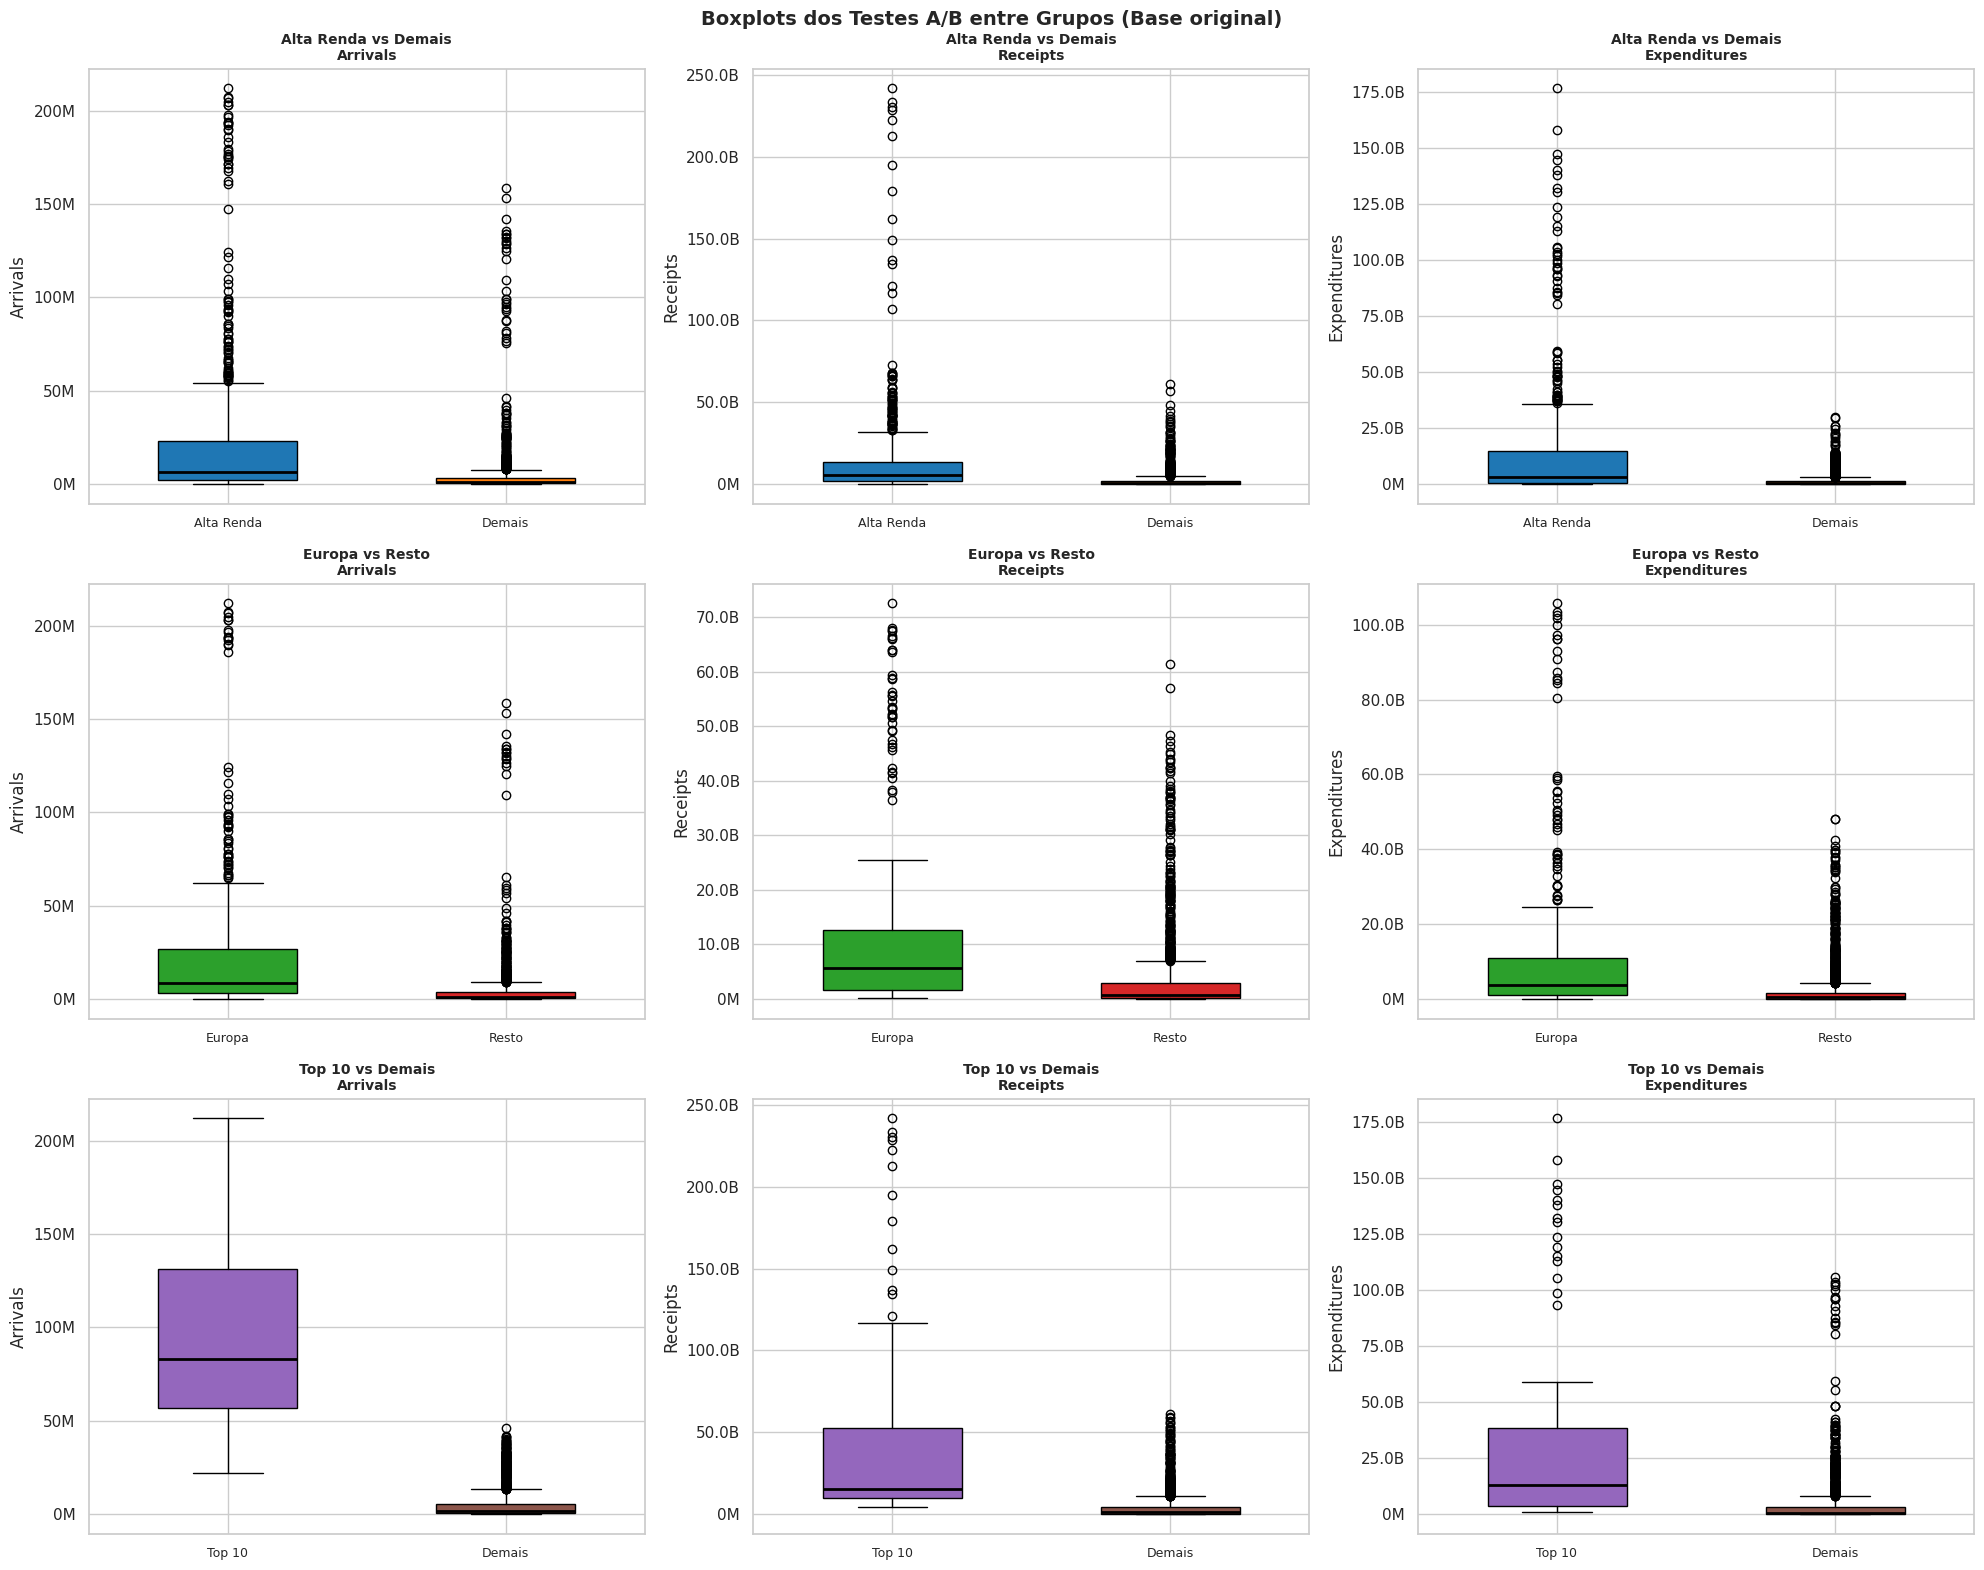

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

comparacoes = [
    ('Alta Renda vs Demais', mask_high,  mask_outros, '#1f77b4', '#ff7f0e'),
    ('Europa vs Resto',      mask_eu,    mask_nao_eu, '#2ca02c', '#d62728'),
    ('Top 10 vs Demais',     mask_top10, mask_fora,   '#9467bd', '#8c564b'),
]

for row_idx, (titulo, mask_a, mask_b, cor_a, cor_b) in enumerate(comparacoes):
    for col_idx, var in enumerate(['Arrivals', 'Receipts', 'Expenditures']):
        ax = axes[row_idx][col_idx]
        grupo_a = df[mask_a][var].dropna().values
        grupo_b = df[mask_b][var].dropna().values
        dados_box = [grupo_a, grupo_b]
        bp = ax.boxplot(dados_box, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(cor_a)
        bp['boxes'][1].set_facecolor(cor_b)
        nomes = titulo.split(' vs ')
        ax.set_xticklabels(nomes, fontsize=9)
        ax.set_title(f'{titulo}\n{var}', fontsize=10)
        ax.set_ylabel(var)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e9:.1f}B' if abs(x) >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots dos Testes A/B entre Grupos (Base original)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1009/3820212519.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Grupo', y=var, palette=['#1f77b4','#ff7f0e'],
/tmp/ipykernel_1009/3820212519.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Grupo', y=var, palette=['#1f77b4','#ff7f0e'],
/tmp/ipykernel_1009/3820212519.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Grupo', y=var, palette=['#1f77b4','#ff7f0e'],
/tmp/ipykernel_1009/3820212519.py:16: FutureWarning: 

Passing `palette` without assigning `hue` 

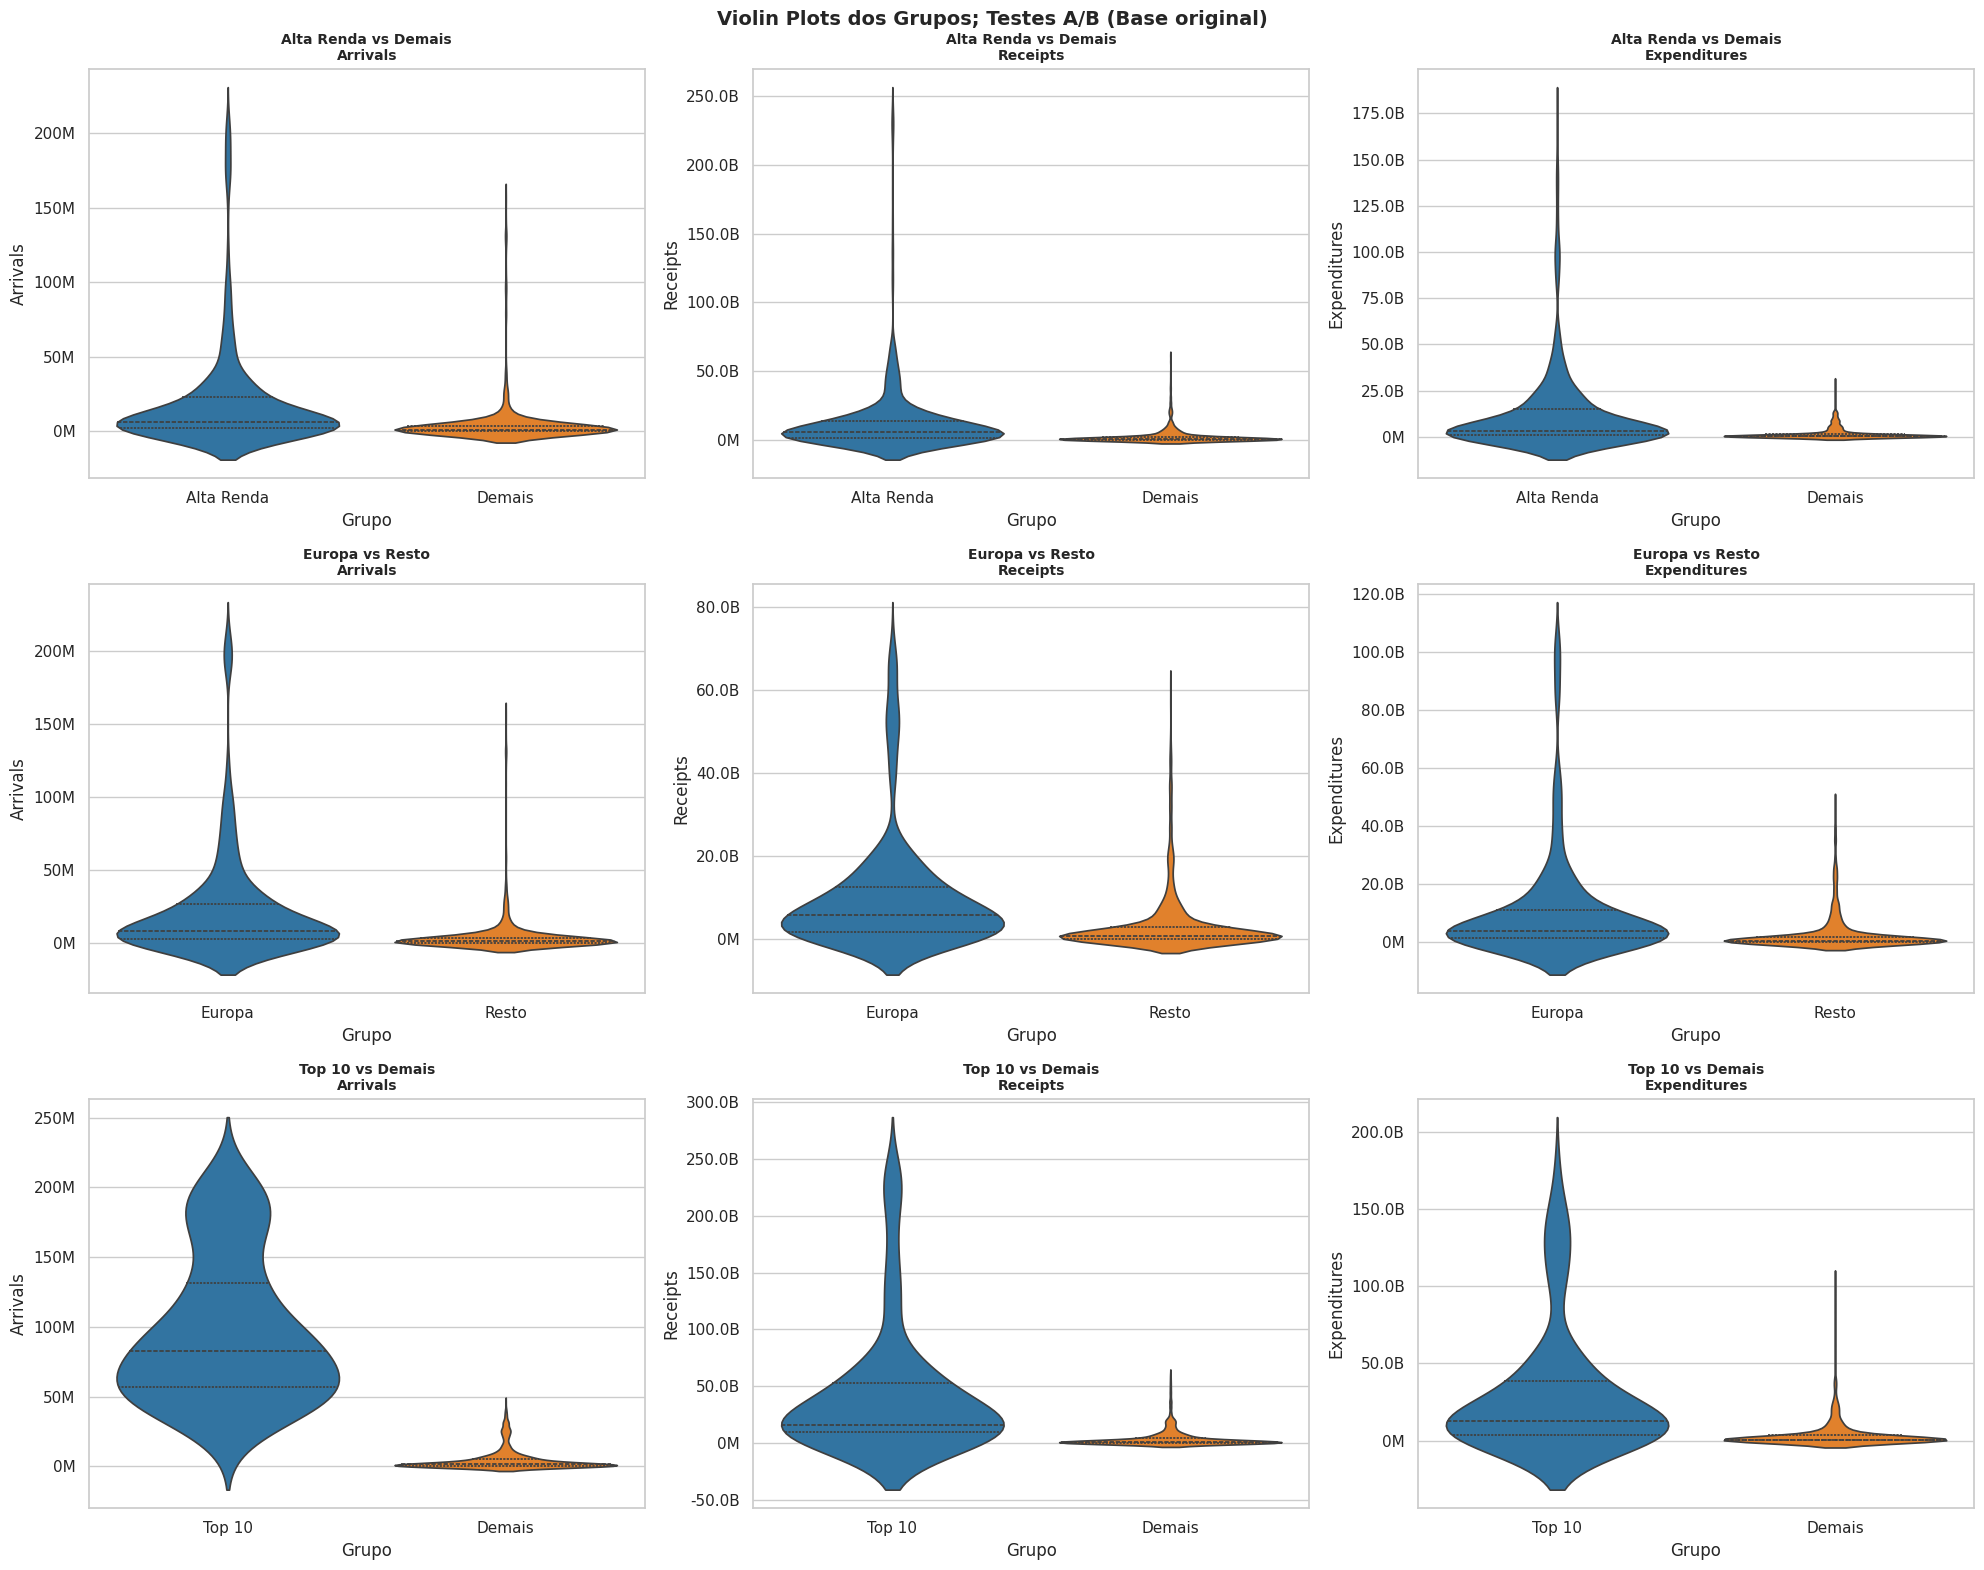

In [83]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

comparacoes_violin = [
    ('Alta Renda vs Demais', mask_high,  mask_outros, 'Alta Renda', 'Demais'),
    ('Europa vs Resto',      mask_eu,    mask_nao_eu, 'Europa',     'Resto'),
    ('Top 10 vs Demais',     mask_top10, mask_fora,   'Top 10',     'Demais'),
]

for row_idx, (titulo, mask_a, mask_b, label_a, label_b) in enumerate(comparacoes_violin):
    for col_idx, var in enumerate(['Arrivals', 'Receipts', 'Expenditures']):
        ax = axes[row_idx][col_idx]
        df_plot = pd.concat([
            pd.DataFrame({'Grupo': label_a, var: df[mask_a][var].dropna().values}),
            pd.DataFrame({'Grupo': label_b, var: df[mask_b][var].dropna().values}),
        ])
        sns.violinplot(data=df_plot, x='Grupo', y=var, palette=['#1f77b4','#ff7f0e'],
                       inner='quartile', ax=ax)
        ax.set_title(f'{titulo}\n{var}', fontsize=10)
        ax.set_ylabel(var)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e9:.1f}B' if abs(x) >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Violin Plots dos Grupos; Testes A/B (Base original)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretação (Tarefa 5):**

Os três pares de comparação mostram diferenças altamente significativas. Países de alta renda têm médias e medianas muito superiores em todas as variáveis. A Europa, mesmo tendo menos países do que a Ásia, concentra mais chegadas absolutas. O contraste entre o top 10 e os demais países é o mais extremo: a diferença de medianas é de várias ordens de grandeza, confirmando que a distribuição do turismo é fundamentalmente desigual.

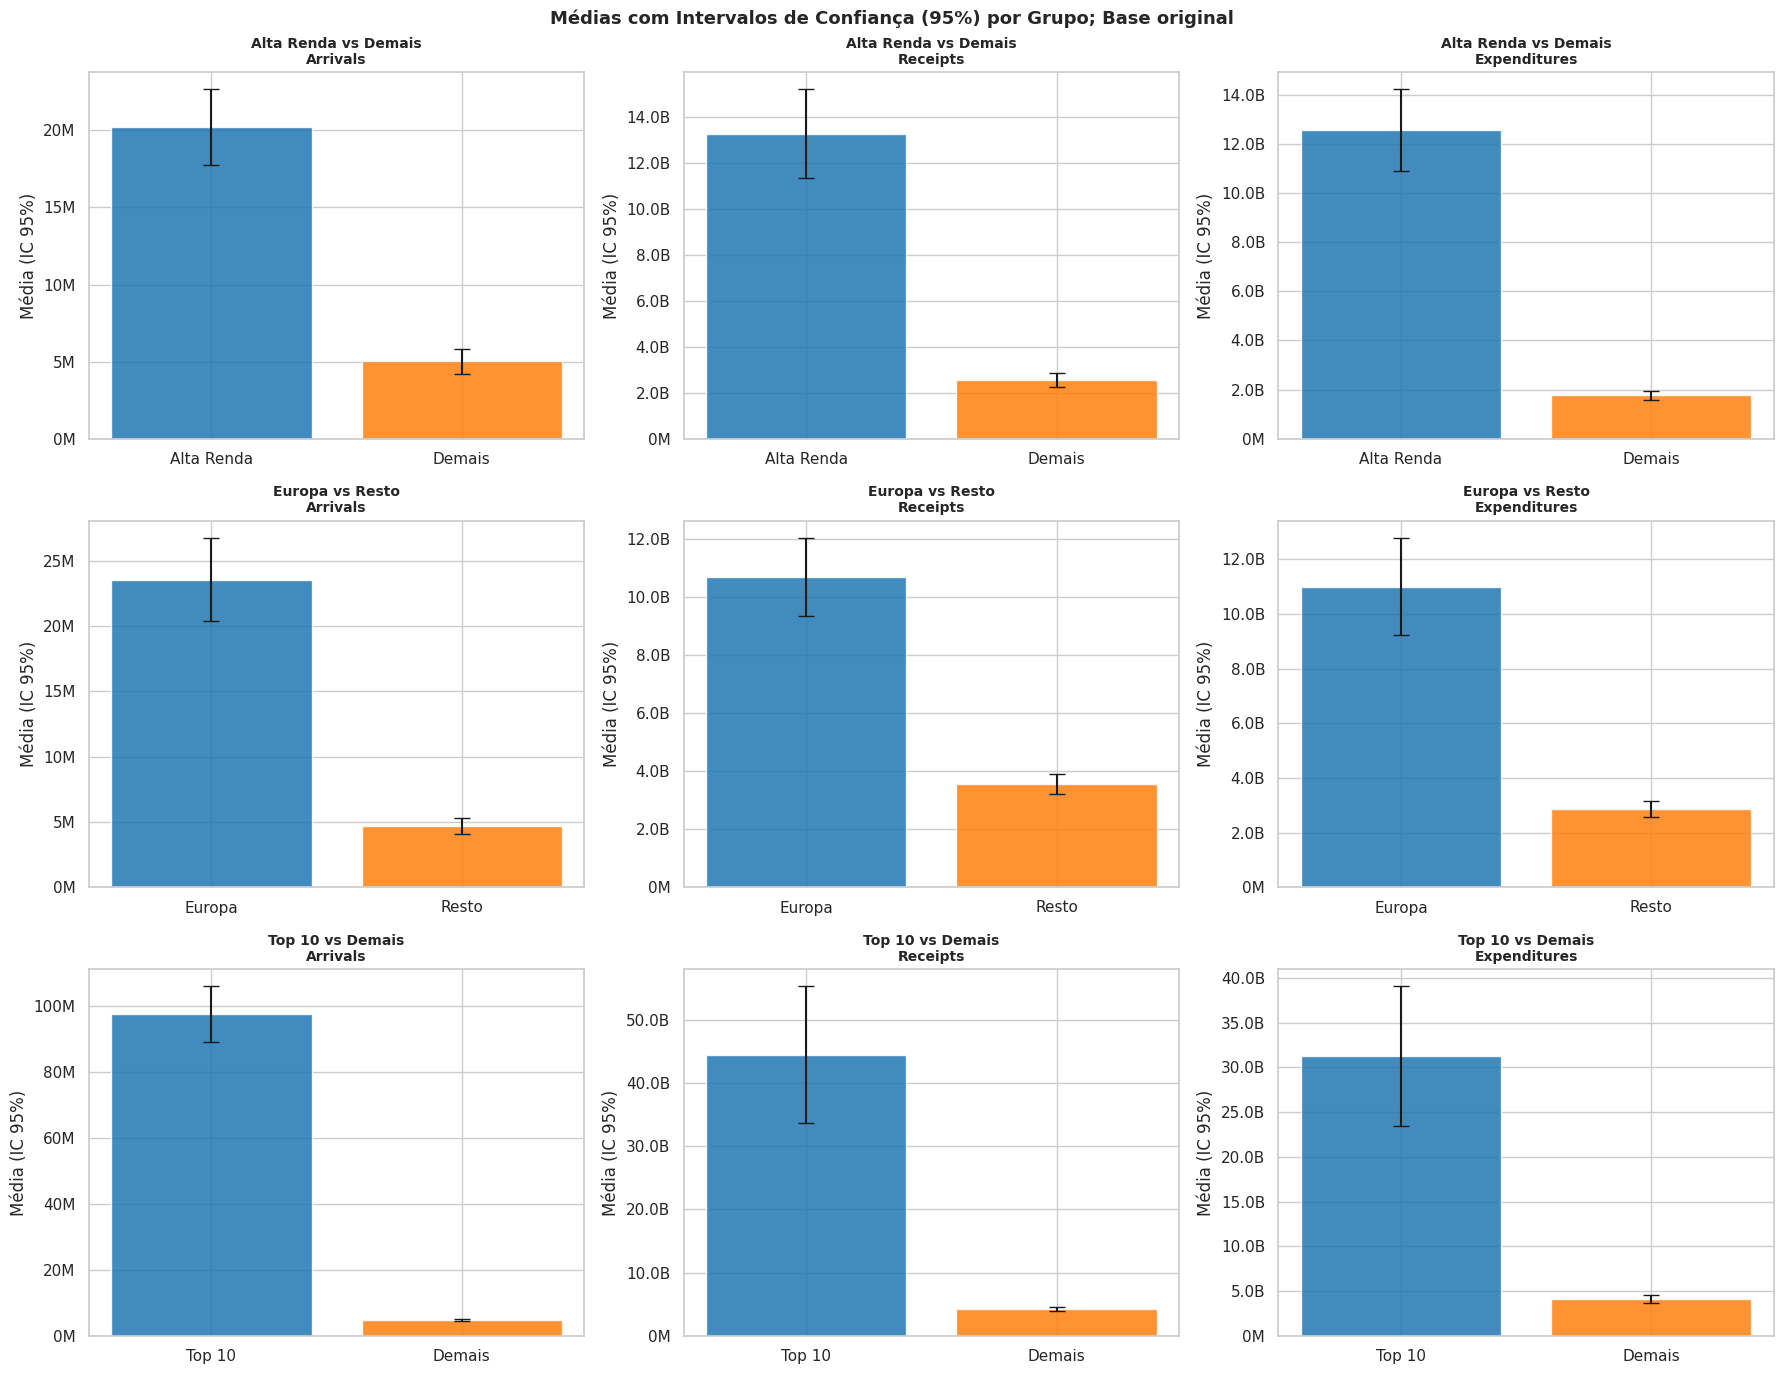

In [84]:
from scipy.stats import sem, t as t_dist

def mean_ci(arr, confidence=0.95):
    n = len(arr)
    if n < 2:
        return np.mean(arr), 0
    se = sem(arr)
    h = se * t_dist.ppf((1 + confidence) / 2., n - 1)
    return np.mean(arr), h

vars_ci = ['Arrivals', 'Receipts', 'Expenditures']
comparacoes_ci = [
    ('Alta Renda', 'Demais', mask_high, mask_outros),
    ('Europa',     'Resto',  mask_eu,   mask_nao_eu),
    ('Top 10',     'Demais', mask_top10, mask_fora),
]

fig, axes = plt.subplots(len(comparacoes_ci), len(vars_ci), figsize=(18, 14))

for row_idx, (label_a, label_b, mask_a, mask_b) in enumerate(comparacoes_ci):
    for col_idx, var in enumerate(vars_ci):
        ax = axes[row_idx][col_idx]
        a_vals = df[mask_a][var].dropna().values
        b_vals = df[mask_b][var].dropna().values
        mean_a, ci_a = mean_ci(a_vals)
        mean_b, ci_b = mean_ci(b_vals)
        bars = ax.bar([label_a, label_b], [mean_a, mean_b],
                      yerr=[ci_a, ci_b], capsize=6,
                      color=['#1f77b4','#ff7f0e'], alpha=0.85)
        ax.set_title(f'{label_a} vs {label_b}\n{var}', fontsize=10)
        ax.set_ylabel('Média (IC 95%)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e9:.1f}B' if abs(x) >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Médias com Intervalos de Confiança (95%) por Grupo; Base original',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2 Base imputada — Testes A/B entre grupos

In [43]:
variaveis_ab = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival',
                'Arrivals_per_Population', 'Tourism_Balance']

def teste_ab_imp(df_base, grupo_a_mask, grupo_b_mask):
    resultados = []
    for var in variaveis_ab:
        a = df_base[grupo_a_mask][var].dropna().values
        b = df_base[grupo_b_mask][var].dropna().values
        if len(a) < 5 or len(b) < 5:
            continue
        t_stat, p_ttest = ttest_ind(a, b, equal_var=False)
        u_stat, p_mwu   = mannwhitneyu(a, b, alternative='two-sided')
        resultados.append({
            'Variável': var,
            'Média A':  np.mean(a),
            'Média B':  np.mean(b),
            'Mediana A': np.median(a),
            'Mediana B': np.median(b),
            'DP A': np.std(a),
            'DP B': np.std(b),
            'Dif. Médias':   np.mean(a) - np.mean(b),
            'Dif. Medianas': np.median(a) - np.median(b),
            'p-valor (t-Welch)': p_ttest,
            'p-valor (MWU)': p_mwu,
            'Sig. (p<0.05)?': 'Sim' if p_mwu < 0.05 else 'Não'
        })
    return pd.DataFrame(resultados)

cols_ab = ['Variável', 'Média A', 'Média B', 'Dif. Médias', 'p-valor (MWU)', 'Sig. (p<0.05)?']

mask_high_i   = df_imp['IncomeGroup'] == 'High income'
mask_outros_i = df_imp['IncomeGroup'] != 'High income'
df_ab1_imp = teste_ab_imp(df_imp, mask_high_i, mask_outros_i)
print('====== COMPARAÇÃO 1: ALTA RENDA vs DEMAIS (BASE IMPUTADA) ======')
print(df_ab1_imp[cols_ab].round(2).to_string(index=False))

mask_eu_i    = df_imp['Continente'] == 'EU'
mask_nao_eu_i = (df_imp['Continente'] != 'EU') & df_imp['Continente'].notna()
df_ab2_imp = teste_ab_imp(df_imp, mask_eu_i, mask_nao_eu_i)
print('\n====== COMPARAÇÃO 2: EUROPA vs RESTO DO MUNDO (BASE IMPUTADA) ======')
print(df_ab2_imp[cols_ab].round(2).to_string(index=False))

top10_paises_imp_arr = totais_pais_imp.nlargest(10, 'Arrivals')['País'].tolist()
mask_top10_i = df_imp['País'].isin(top10_paises_imp_arr)
mask_fora_i  = ~df_imp['País'].isin(top10_paises_imp_arr)
df_ab3_imp = teste_ab_imp(df_imp, mask_top10_i, mask_fora_i)
print('\n====== COMPARAÇÃO 3: TOP 10 vs DEMAIS (BASE IMPUTADA) ======')
print(df_ab3_imp[cols_ab].round(2).to_string(index=False))


====== COMPARAÇÃO 1: ALTA RENDA vs DEMAIS (BASE IMPUTADA) ======
               Variável      Média A      Média B   Dif. Médias  p-valor (MWU) Sig. (p<0.05)?
               Arrivals 1.987406e+07 4.875294e+06  1.499876e+07            0.0            Sim
               Receipts 1.462778e+10 2.717397e+09  1.191038e+10            0.0            Sim
           Expenditures 1.396636e+10 1.886345e+09  1.208002e+10            0.0            Sim
   Receipts_per_Arrival 1.144740e+03 8.400700e+02  3.046700e+02            0.0            Sim
Arrivals_per_Population 4.970000e+00 4.400000e-01  4.540000e+00            0.0            Sim
        Tourism_Balance 6.614158e+08 8.310517e+08 -1.696359e+08            0.0            Sim

====== COMPARAÇÃO 2: EUROPA vs RESTO DO MUNDO (BASE IMPUTADA) ======
               Variável       Média A      Média B   Dif. Médias  p-valor (MWU) Sig. (p<0.05)?
               Arrivals  2.328111e+07 4.547746e+06  1.873336e+07           0.00            Sim
               Re

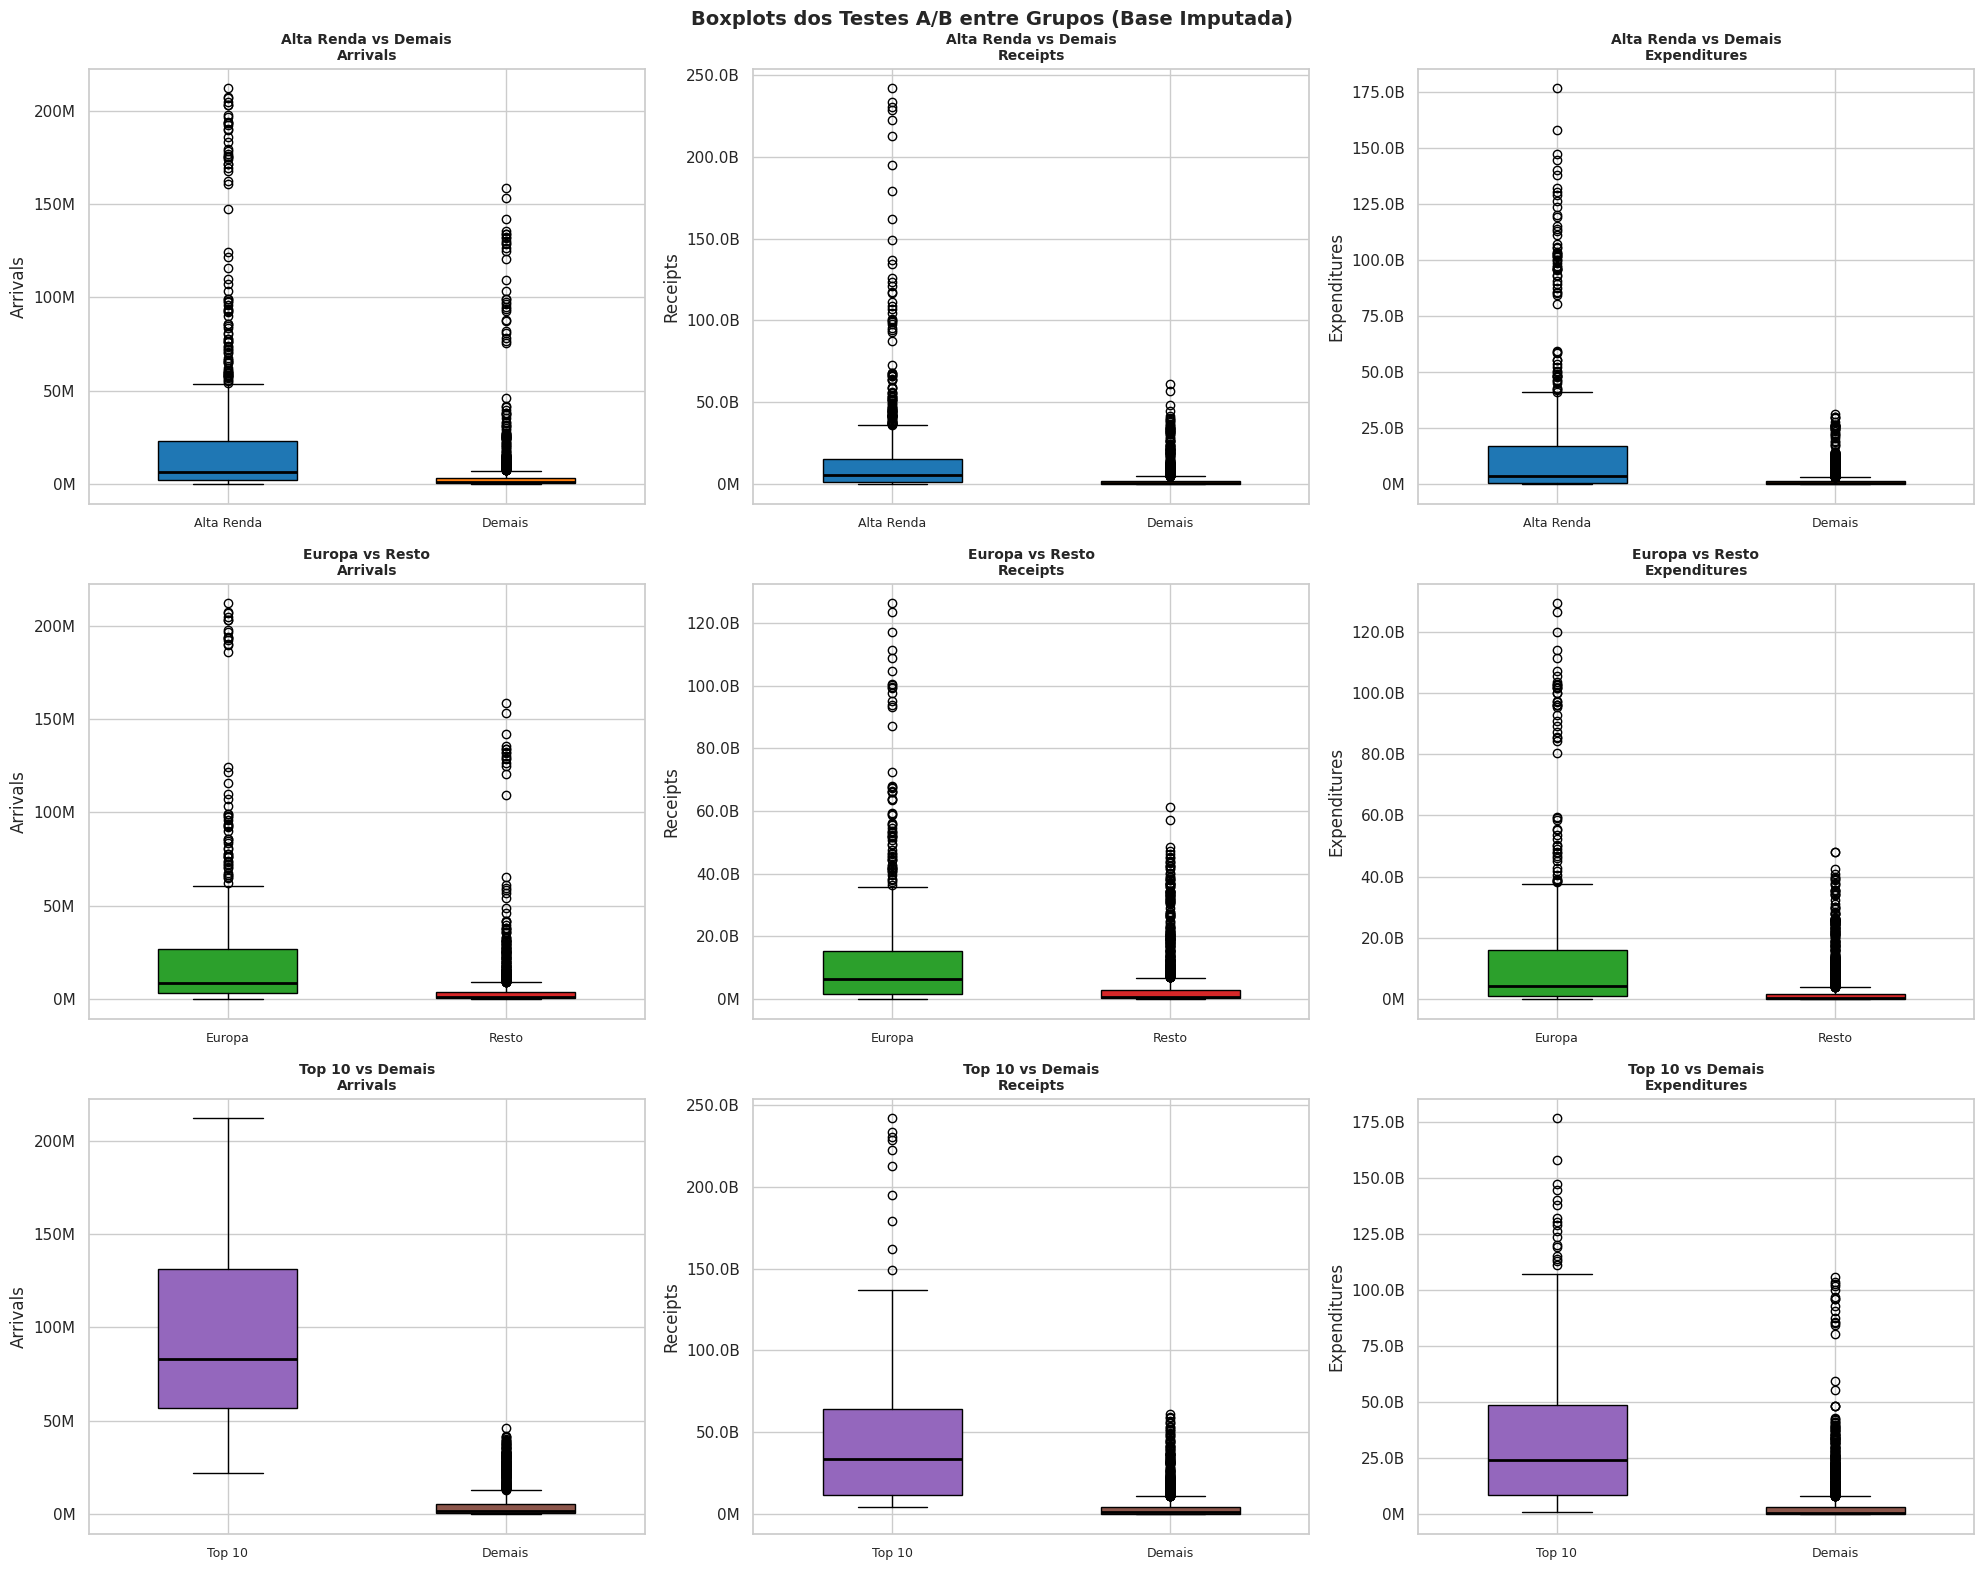

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

comparacoes_imp = [
    ('Alta Renda vs Demais', mask_high_i,  mask_outros_i, '#1f77b4', '#ff7f0e'),
    ('Europa vs Resto',      mask_eu_i,    mask_nao_eu_i, '#2ca02c', '#d62728'),
    ('Top 10 vs Demais',     mask_top10_i, mask_fora_i,   '#9467bd', '#8c564b'),
]

for row_idx, (titulo, mask_a, mask_b, cor_a, cor_b) in enumerate(comparacoes_imp):
    for col_idx, var in enumerate(['Arrivals', 'Receipts', 'Expenditures']):
        ax = axes[row_idx][col_idx]
        grupo_a = df_imp[mask_a][var].dropna().values
        grupo_b = df_imp[mask_b][var].dropna().values
        bp = ax.boxplot([grupo_a, grupo_b], patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(cor_a)
        bp['boxes'][1].set_facecolor(cor_b)
        ax.set_xticklabels(titulo.split(' vs '), fontsize=9)
        ax.set_title(f'{titulo}\n{var}', fontsize=10)
        ax.set_ylabel(var)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e9:.1f}B' if abs(x) >= 1e9 else f'{x/1e6:.0f}M'))

plt.suptitle('Boxplots dos Testes A/B entre Grupos (Base Imputada)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [85]:
print('====== COMPARAÇÃO DE SIGNIFICÂNCIA (MWU p-valor) ORIGINAL vs IMPUTADA ======')
comparacoes_nomes = ['Alta Renda vs Demais', 'Europa vs Resto', 'Top 10 vs Demais']
orig_dfs  = [df_ab1, df_ab2, df_ab3]
imp_dfs   = [df_ab1_imp, df_ab2_imp, df_ab3_imp]

for nome, df_o, df_i in zip(comparacoes_nomes, orig_dfs, imp_dfs):
    merged_ab = df_o[['Variável','p-valor (MWU)']].rename(columns={'p-valor (MWU)':'p (Original)'}).merge(
                df_i[['Variável','p-valor (MWU)']].rename(columns={'p-valor (MWU)':'p (Imputada)'}),
                on='Variável')
    merged_ab['Sig. Orig.'] = (merged_ab['p (Original)'] < 0.05).map({True:'Sim',False:'Não'})
    merged_ab['Sig. Imp.']  = (merged_ab['p (Imputada)'] < 0.05).map({True:'Sim',False:'Não'})
    print(f'\n--- {nome} ---')
    print(merged_ab.round(4).to_string(index=False))


====== COMPARAÇÃO DE SIGNIFICÂNCIA (MWU p-valor) ORIGINAL vs IMPUTADA ======

--- Alta Renda vs Demais ---
               Variável  p (Original)  p (Imputada) Sig. Orig. Sig. Imp.
               Arrivals           0.0        0.0000        Sim       Sim
               Receipts           0.0        0.0000        Sim       Sim
           Expenditures           0.0        0.0000        Sim       Sim
   Receipts_per_Arrival           0.0        0.0000        Sim       Sim
Arrivals_per_Population           0.0        0.0000        Sim       Sim
        Tourism_Balance           0.0        0.0001        Sim       Sim

--- Europa vs Resto ---
               Variável  p (Original)  p (Imputada) Sig. Orig. Sig. Imp.
               Arrivals        0.0000        0.0000        Sim       Sim
               Receipts        0.0000        0.0000        Sim       Sim
           Expenditures        0.0000        0.0000        Sim       Sim
   Receipts_per_Arrival        0.3158        0.1644        Não   

## 6. Análise de risco e dependência turística

In [46]:
df_dep = df.groupby('País').agg(
    Receipts_exp_pct=('Receipts - % of Total Exports', 'mean'),
    Expenditures_imp_pct=('Expenditures - % of Total Imports', 'mean'),
    Arrivals_per_Pop=('Arrivals_per_Population', 'mean'),
    Tourism_Balance_med=('Tourism_Balance', 'mean'),
    Receipts_vol=('Receipts', 'std'),
    Arrivals_vol=('Arrivals', 'std'),
    Receipts_mean=('Receipts', 'mean'),
    Arrivals_mean=('Arrivals', 'mean'),
).reset_index()

df_dep['Receipts_CV']  = df_dep['Receipts_vol']  / df_dep['Receipts_mean'].replace(0, np.nan) * 100
df_dep['Arrivals_CV']  = df_dep['Arrivals_vol']   / df_dep['Arrivals_mean'].replace(0, np.nan) * 100

p75_dep = df_dep['Receipts_exp_pct'].quantile(0.75)
p90_dep = df_dep['Receipts_exp_pct'].quantile(0.90)
p75_int = df_dep['Arrivals_per_Pop'].quantile(0.75)
p75_vol = df_dep['Receipts_CV'].quantile(0.75)

df_dep['Alta_Dependencia']     = df_dep['Receipts_exp_pct'] > p75_dep
df_dep['Dep_Muito_Alta']       = df_dep['Receipts_exp_pct'] > p90_dep
df_dep['Alta_Intensidade']     = df_dep['Arrivals_per_Pop']  > p75_int
df_dep['Alta_Volatilidade']    = df_dep['Receipts_CV']       > p75_vol
df_dep['Alto_Risco_Turistico'] = df_dep['Alta_Dependencia']  & df_dep['Alta_Volatilidade']

print(f'P75 dependência turística (Receipts % Export): {p75_dep:.2f}%')
print(f'P90 dependência turística (Receipts % Export): {p90_dep:.2f}%')
print(f'P75 intensidade (Arrivals/Pop): {p75_int:.4f}')
print(f'P75 volatilidade (CV Receipts): {p75_vol:.2f}%')

P75 dependência turística (Receipts % Export): 25.14%
P90 dependência turística (Receipts % Export): 47.56%
P75 intensidade (Arrivals/Pop): 1.1362
P75 volatilidade (CV Receipts): 47.15%


In [47]:
print('====== TOP 15: MAIOR DEPENDÊNCIA TURÍSTICA (Receipts % Exports) ======')
top_dep = df_dep.dropna(subset=['Receipts_exp_pct']).nlargest(15, 'Receipts_exp_pct')[
    ['País', 'Receipts_exp_pct', 'Alta_Dependencia', 'Dep_Muito_Alta']
]
print(top_dep.to_string(index=False))

print()
print('====== TOP 15: MAIOR INTENSIDADE TURÍSTICA (Arrivals / Population) ======')
top_int = df_dep.dropna(subset=['Arrivals_per_Pop']).nlargest(15, 'Arrivals_per_Pop')[
    ['País', 'Arrivals_per_Pop', 'Alta_Intensidade']
]
print(top_int.to_string(index=False))

====== TOP 15: MAIOR DEPENDÊNCIA TURÍSTICA (Receipts % Exports) ======
                     País  Receipts_exp_pct  Alta_Dependencia  Dep_Muito_Alta
                    Macau         86.015333              True            True
                 Maldives         83.596250              True            True
                    Palau         83.274615              True            True
                  Vanuatu         72.004667              True            True
Sint Maarten (Dutch part)         70.541250              True            True
                  Bahamas         68.864667              True            True
                St. Lucia         61.694000              True            True
                    Samoa         61.594667              True            True
         French Polynesia         59.666364              True            True
               Cabo Verde         57.330000              True            True
    Sao Tome and Principe         54.683333              True          

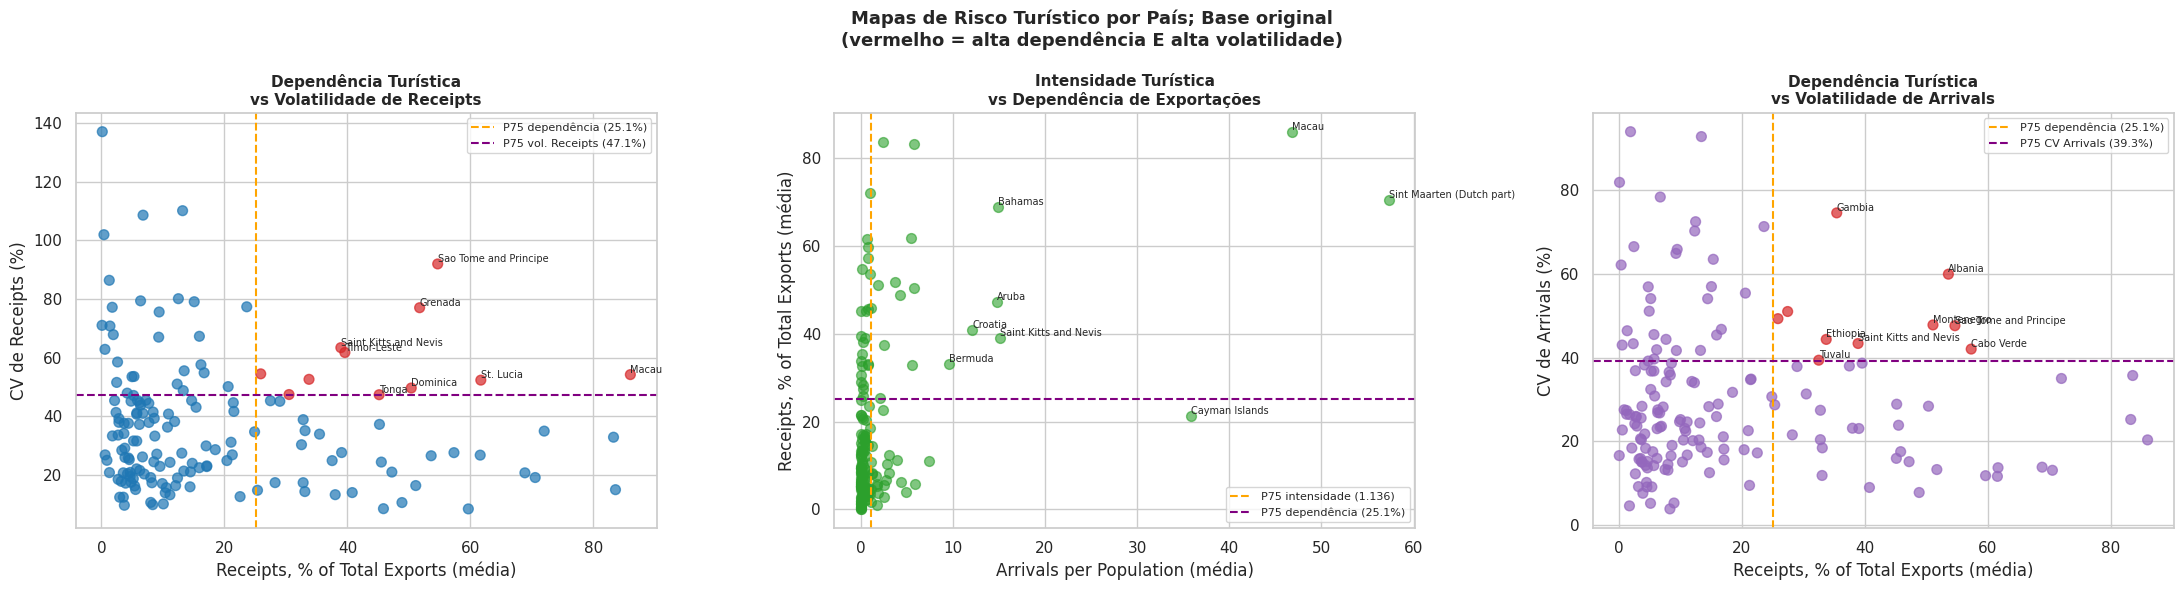

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

df_scatter = df_dep.dropna(subset=['Receipts_exp_pct', 'Receipts_CV'])

ax1 = axes[0]
colors_risk = df_scatter['Alto_Risco_Turistico'].map({True: '#d62728', False: '#1f77b4'})
ax1.scatter(df_scatter['Receipts_exp_pct'], df_scatter['Receipts_CV'],
            c=colors_risk, alpha=0.7, s=50)
ax1.axvline(p75_dep, color='orange', linestyle='--', label=f'P75 dependência ({p75_dep:.1f}%)')
ax1.axhline(p75_vol, color='purple', linestyle='--', label=f'P75 vol. Receipts ({p75_vol:.1f}%)')
for _, row in df_scatter[df_scatter['Alto_Risco_Turistico']].nlargest(8, 'Receipts_exp_pct').iterrows():
    ax1.annotate(row['País'], (row['Receipts_exp_pct'], row['Receipts_CV']),
                 fontsize=7, ha='left', va='bottom')
ax1.set_title('Dependência Turística\nvs Volatilidade de Receipts', fontsize=11)
ax1.set_xlabel('Receipts, % of Total Exports (média)')
ax1.set_ylabel('CV de Receipts (%)')
ax1.legend(fontsize=8)

ax2 = axes[1]
df_s2 = df_dep.dropna(subset=['Arrivals_per_Pop', 'Receipts_exp_pct'])
ax2.scatter(df_s2['Arrivals_per_Pop'], df_s2['Receipts_exp_pct'],
            c='#2ca02c', alpha=0.6, s=50)
ax2.axvline(p75_int, color='orange', linestyle='--', label=f'P75 intensidade ({p75_int:.3f})')
ax2.axhline(p75_dep, color='purple', linestyle='--', label=f'P75 dependência ({p75_dep:.1f}%)')
for _, row in df_s2.nlargest(8, 'Arrivals_per_Pop').iterrows():
    ax2.annotate(row['País'], (row['Arrivals_per_Pop'], row['Receipts_exp_pct']),
                 fontsize=7, ha='left', va='bottom')
ax2.set_title('Intensidade Turística\nvs Dependência de Exportações', fontsize=11)
ax2.set_xlabel('Arrivals per Population (média)')
ax2.set_ylabel('Receipts, % of Total Exports (média)')
ax2.legend(fontsize=8)

p75_vol_arr = df_dep['Arrivals_CV'].quantile(0.75)
df_s3 = df_dep.dropna(subset=['Receipts_exp_pct', 'Arrivals_CV'])
alto_risco_arr = (df_s3['Receipts_exp_pct'] > p75_dep) & (df_s3['Arrivals_CV'] > p75_vol_arr)
colors_arr = alto_risco_arr.map({True: '#d62728', False: '#9467bd'})
ax3 = axes[2]
ax3.scatter(df_s3['Receipts_exp_pct'], df_s3['Arrivals_CV'],
            c=colors_arr, alpha=0.7, s=50)
ax3.axvline(p75_dep,     color='orange', linestyle='--', label=f'P75 dependência ({p75_dep:.1f}%)')
ax3.axhline(p75_vol_arr, color='purple', linestyle='--', label=f'P75 CV Arrivals ({p75_vol_arr:.1f}%)')
for _, row in df_s3[alto_risco_arr].nlargest(8, 'Receipts_exp_pct').iterrows():
    ax3.annotate(row['País'], (row['Receipts_exp_pct'], row['Arrivals_CV']),
                 fontsize=7, ha='left', va='bottom')
ax3.set_title('Dependência Turística\nvs Volatilidade de Arrivals', fontsize=11)
ax3.set_xlabel('Receipts, % of Total Exports (média)')
ax3.set_ylabel('CV de Arrivals (%)')
ax3.legend(fontsize=8)

plt.suptitle('Mapas de Risco Turístico por País; Base original\n'
             '(vermelho = alta dependência E alta volatilidade)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [49]:
print('====== PAÍSES CLASSIFICADOS COMO ALTO RISCO TURÍSTICO ======')
print('(Alta dependência E alta volatilidade de receitas)')
alto_risco = df_dep[df_dep['Alto_Risco_Turistico']].sort_values('Receipts_exp_pct', ascending=False)[
    ['País', 'Receipts_exp_pct', 'Receipts_CV', 'Arrivals_per_Pop', 'Dep_Muito_Alta']
].reset_index(drop=True)
print(alto_risco.round(2).to_string())

====== PAÍSES CLASSIFICADOS COMO ALTO RISCO TURÍSTICO ======
(Alta dependência E alta volatilidade de receitas)
                     País  Receipts_exp_pct  Receipts_CV  Arrivals_per_Pop  Dep_Muito_Alta
0                   Macau             86.02        54.23             46.81            True
1               St. Lucia             61.69        52.34              5.41            True
2   Sao Tome and Principe             54.68        91.95              0.10            True
3                 Grenada             51.74        77.03              3.71            True
4                Dominica             50.38        49.66              5.80            True
5                   Tonga             45.16        47.38              0.63           False
6             Timor-Leste             39.59        61.76              0.05           False
7   Saint Kitts and Nevis             38.93        63.42             15.12           False
8                Ethiopia             33.76        52.62             

**Interpretação (Tarefa 6):**

Pequenas economias insulares e destinos turísticos especializados concentram os maiores índices de dependência turística. Países como Maldivas, Aruba e Seychelles têm mais de 50% de suas exportações vinculadas ao turismo, se expondo fortemente a choques externos. Quando combinada com alta volatilidade de receitas (CV de Receipts) e com alta volatilidade de Arrivals (CV de Arrivals), essa dependência representa risco econômico significativo, razão pela qual ambos os tipos de volatilidade são agora analisados nos scatterplots.


### 6.2 Base imputada — Análise de risco e dependência turística

In [50]:
df_dep_imp = df_imp.groupby('País').agg(
    Receipts_exp_pct=('Receipts - % of Total Exports', 'mean'),
    Expenditures_imp_pct=('Expenditures - % of Total Imports', 'mean'),
    Arrivals_per_Pop=('Arrivals_per_Population', 'mean'),
    Tourism_Balance_med=('Tourism_Balance', 'mean'),
    Receipts_vol=('Receipts', 'std'),
    Arrivals_vol=('Arrivals', 'std'),
    Receipts_mean=('Receipts', 'mean'),
    Arrivals_mean=('Arrivals', 'mean'),
    Receipts_pct_n_imp=('Receipts - % of Total Exports__was_imputed', 'sum'),
).reset_index()

df_dep_imp['Receipts_CV'] = (df_dep_imp['Receipts_vol']
                             / df_dep_imp['Receipts_mean'].replace(0, np.nan) * 100)
df_dep_imp['Arrivals_CV'] = (df_dep_imp['Arrivals_vol']
                             / df_dep_imp['Arrivals_mean'].replace(0, np.nan) * 100)

p75_dep_i = df_dep_imp['Receipts_exp_pct'].quantile(0.75)
p90_dep_i = df_dep_imp['Receipts_exp_pct'].quantile(0.90)
p75_int_i = df_dep_imp['Arrivals_per_Pop'].quantile(0.75)
p75_vol_i = df_dep_imp['Receipts_CV'].quantile(0.75)

df_dep_imp['Alta_Dependencia']     = df_dep_imp['Receipts_exp_pct'] > p75_dep_i
df_dep_imp['Dep_Muito_Alta']       = df_dep_imp['Receipts_exp_pct'] > p90_dep_i
df_dep_imp['Alta_Intensidade']     = df_dep_imp['Arrivals_per_Pop']  > p75_int_i
df_dep_imp['Alta_Volatilidade']    = df_dep_imp['Receipts_CV']       > p75_vol_i
df_dep_imp['Alto_Risco_Turistico'] = df_dep_imp['Alta_Dependencia']  & df_dep_imp['Alta_Volatilidade']
df_dep_imp['Dependencia_Imputada'] = df_dep_imp['Receipts_pct_n_imp'] > 0

print(f'P75 dependência (imputada): {p75_dep_i:.2f}%')
print(f'P90 dependência (imputada): {p90_dep_i:.2f}%')

print('\n====== TOP 15: MAIOR DEPENDÊNCIA TURÍSTICA (BASE IMPUTADA) ======')
top_dep_i = df_dep_imp.dropna(subset=['Receipts_exp_pct']).nlargest(15, 'Receipts_exp_pct')[
    ['País', 'Receipts_exp_pct', 'Alta_Dependencia', 'Dep_Muito_Alta', 'Dependencia_Imputada']
]
print(top_dep_i.to_string(index=False))

print('\n====== TOP 15: MAIOR INTENSIDADE TURÍSTICA (BASE IMPUTADA) ======')
top_int_i = df_dep_imp.dropna(subset=['Arrivals_per_Pop']).nlargest(15, 'Arrivals_per_Pop')[
    ['País', 'Arrivals_per_Pop', 'Alta_Intensidade']
]
print(top_int_i.to_string(index=False))


P75 dependência (imputada): 23.09%
P90 dependência (imputada): 46.41%

====== TOP 15: MAIOR DEPENDÊNCIA TURÍSTICA (BASE IMPUTADA) ======
                     País  Receipts_exp_pct  Alta_Dependencia  Dep_Muito_Alta  Dependencia_Imputada
                    Macau         86.015333              True            True                 False
                 Maldives         83.596250              True            True                  True
                    Palau         83.274615              True            True                  True
                  Vanuatu         72.004667              True            True                 False
Sint Maarten (Dutch part)         70.541250              True            True                  True
                  Bahamas         68.864667              True            True                 False
                St. Lucia         61.694000              True            True                 False
                    Samoa         61.594667              True  

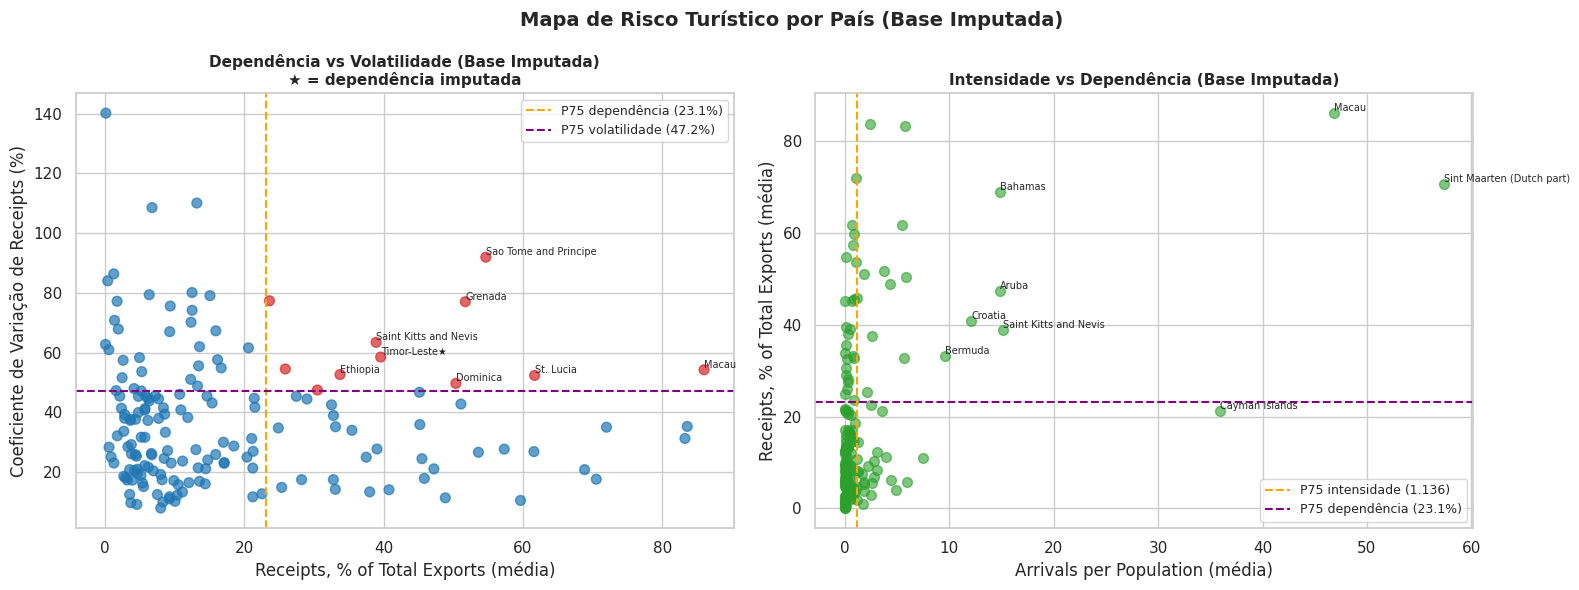

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_sc_i = df_dep_imp.dropna(subset=['Receipts_exp_pct', 'Receipts_CV'])

ax1 = axes[0]
colors_r = df_sc_i['Alto_Risco_Turistico'].map({True: '#d62728', False: '#1f77b4'})
ax1.scatter(df_sc_i['Receipts_exp_pct'], df_sc_i['Receipts_CV'],
            c=colors_r, alpha=0.7, s=50)
ax1.axvline(p75_dep_i, color='orange', linestyle='--',
            label=f'P75 dependência ({p75_dep_i:.1f}%)')
ax1.axhline(p75_vol_i, color='purple', linestyle='--',
            label=f'P75 volatilidade ({p75_vol_i:.1f}%)')

for _, row in df_sc_i[df_sc_i['Alto_Risco_Turistico']].nlargest(8, 'Receipts_exp_pct').iterrows():
    marker = '★' if row['Dependencia_Imputada'] else ''
    ax1.annotate(row['País'] + marker,
                 (row['Receipts_exp_pct'], row['Receipts_CV']),
                 fontsize=7, ha='left', va='bottom')

ax1.set_title('Dependência vs Volatilidade (Base Imputada)\n★ = dependência imputada', fontsize=11)
ax1.set_xlabel('Receipts, % of Total Exports (média)')
ax1.set_ylabel('Coeficiente de Variação de Receipts (%)')
ax1.legend(fontsize=9)

ax2 = axes[1]
df_s2_i = df_dep_imp.dropna(subset=['Arrivals_per_Pop', 'Receipts_exp_pct'])
ax2.scatter(df_s2_i['Arrivals_per_Pop'], df_s2_i['Receipts_exp_pct'],
            c='#2ca02c', alpha=0.6, s=50)
ax2.axvline(p75_int_i, color='orange', linestyle='--',
            label=f'P75 intensidade ({p75_int_i:.3f})')
ax2.axhline(p75_dep_i, color='purple', linestyle='--',
            label=f'P75 dependência ({p75_dep_i:.1f}%)')

for _, row in df_s2_i.nlargest(8, 'Arrivals_per_Pop').iterrows():
    ax2.annotate(row['País'], (row['Arrivals_per_Pop'], row['Receipts_exp_pct']),
                 fontsize=7, ha='left', va='bottom')

ax2.set_title('Intensidade vs Dependência (Base Imputada)', fontsize=11)
ax2.set_xlabel('Arrivals per Population (média)')
ax2.set_ylabel('Receipts, % of Total Exports (média)')
ax2.legend(fontsize=9)

plt.suptitle('Mapa de Risco Turístico por País (Base Imputada)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [52]:
print('====== PAÍSES DE ALTO RISCO TURÍSTICO (BASE IMPUTADA) ======')
print('(★ = variável de dependência com dados imputados — tratar com cautela)')
alto_risco_i = df_dep_imp[df_dep_imp['Alto_Risco_Turistico']].sort_values(
    'Receipts_exp_pct', ascending=False)[
    ['País', 'Receipts_exp_pct', 'Receipts_CV', 'Arrivals_per_Pop',
     'Dep_Muito_Alta', 'Dependencia_Imputada']
].reset_index(drop=True)
alto_risco_i['Obs'] = alto_risco_i['Dependencia_Imputada'].map({True: '★ imputado', False: ''})
print(alto_risco_i[['País','Receipts_exp_pct','Receipts_CV','Arrivals_per_Pop',
                     'Dep_Muito_Alta','Obs']].round(2).to_string(index=False))

print('\n====== COMPARAÇÃO TOP 10 DEPENDÊNCIA: ORIGINAL vs IMPUTADA ======')
rank_orig_dep = df_dep.dropna(subset=['Receipts_exp_pct']).nlargest(10, 'Receipts_exp_pct')[
    ['País','Receipts_exp_pct']].reset_index(drop=True)
rank_imp_dep  = df_dep_imp.dropna(subset=['Receipts_exp_pct']).nlargest(10, 'Receipts_exp_pct')[
    ['País','Receipts_exp_pct','Dependencia_Imputada']].reset_index(drop=True)

comp_dep = pd.DataFrame({
    'Rank': range(1, 11),
    'País (Original)': rank_orig_dep['País'],
    'Dep% (Orig.)':    rank_orig_dep['Receipts_exp_pct'].round(2),
    'País (Imputada)': rank_imp_dep['País'],
    'Dep% (Imp.)':     rank_imp_dep['Receipts_exp_pct'].round(2),
    'Imputado?':       rank_imp_dep['Dependencia_Imputada'].map({True:'★ Sim',False:'Não'}),
})
print(comp_dep.to_string(index=False))


====== PAÍSES DE ALTO RISCO TURÍSTICO (BASE IMPUTADA) ======
(★ = variável de dependência com dados imputados — tratar com cautela)
                 País  Receipts_exp_pct  Receipts_CV  Arrivals_per_Pop  Dep_Muito_Alta        Obs
                Macau             86.02        54.23             46.81            True           
            St. Lucia             61.69        52.34              5.41            True           
Sao Tome and Principe             54.68        91.95              0.10            True           
              Grenada             51.74        77.03              3.71            True           
             Dominica             50.38        49.66              5.80            True           
          Timor-Leste             39.59        58.48              0.05           False ★ imputado
Saint Kitts and Nevis             38.93        63.42             15.12           False           
             Ethiopia             33.76        52.62              0.01           Fal

## Conclusão da Pergunta 2

Com base nas análises descritivas, testes de hipótese e simulações realizadas nas bases original e imputada, conclui-se:

**1. Distribuição por Continentes e Grupos de Renda:**
A Europa e os países de Alta Renda dominam consistentemente o turismo global em todas as métricas (Arrivals, Receipts e Expenditures), tanto na base original quanto na imputada. A Ásia aparece como o segundo maior bloco, especialmente em Receipts.

**2. Concentração (Top 5, 10, 20, Gini e HHI):**
O turismo global é altamente concentrado. O Top 10 concentra, em média, mais de 50% dos Receipts e Arrivals. Os índices de Gini (próximos de 0.75-0.80) e HHI confirmam uma desigualdade estrutural profunda. Houve uma leve tendência de *desconcentração* ao longo da década (queda de ~10 p.p. no Top 10 de Arrivals entre 2004 e 2018), indicando que destinos fora do Top 10 ganharam participação relativa.

**3. Teste de Simulação (Concentração no Top 10):**
O teste de Monte Carlo rejeitou a hipótese nula ($H_0$) em todos os anos e variáveis ($p$-valor empírico = 0.0). A concentração observada no Top 10 é estatisticamente significativa e muito maior do que seria esperado em uma distribuição aleatória. Esse resultado é robusto, pois se mantém tanto na base original quanto na imputada.

**4. Testes A/B entre Grupos:**
As diferenças entre "Alta Renda vs. Demais" e "Europa vs. Resto" são estatisticamente significativas ($p < 0.05$) para todas as variáveis principais em ambas as bases. Isso valida a robustez da dominância desses grupos.

**5. Dependência e Risco Turístico:**
Países insulares ou de menor porte (ex: Maldivas, Macau, São Tomé e Príncipe, Granada) apresentam os maiores índices de dependência (Receipts como % das Exportações) e alta volatilidade (Coeficiente de Variação), classificando-os como de Alto Risco Turístico.

**6. Impacto da Imputação (Ponto Crítico):**
- **Padrões Gerais:** A imputação NÃO alterou as conclusões macroscópicas (dominância da Europa/Alta Renda e alta concentração global). Portanto, as conclusões gerais são robustas.
- **Sensibilidade em Rankings:** A imputação afetou rankings específicos, especialmente em Receipts. Por exemplo, a Espanha apresenta uma quantidade significativa de anos imputados na base, o que inflou artificialmente sua posição no ranking da base imputada.
- **Conclusão sobre Imputação:** A base imputada é válida para identificar padrões globais e tendências, mas não deve ser usada para afirmar com certeza absoluta o ranking exato de um país específico se esse país possuir muitos dados imputados (como observado no caso da Espanha em Receipts). Para Arrivals, a imputação teve impacto mínimo, tornando os rankings mais confiáveis.